In [1]:
# FnRGNN의 “공정성 개입 강도”를, QpiGNN이 뽑은 “불확실성”에 조건부로
# 확신이 높은 샘플은 덜 건드리고, 불확실한 샘플에서만(혹은 더 강하게) 공정성 개입을 걸면 “uncertainty-conditional intervention"

### Metric & Analysis

In [62]:
import math
import torch

import numpy as np
import networkx as nx
import seaborn as sns
import scipy.sparse as sp
import matplotlib.pyplot as plt

from scipy import sparse
from scipy.spatial.distance import jensenshannon
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.stats import wasserstein_distance, pearsonr, spearmanr, entropy, ks_2samp, cramervonmises_2samp, ttest_ind, levene

from torch_geometric.utils import degree
from torch_geometric.utils import to_networkx, to_scipy_sparse_matrix
#################################################################################################################


In [ ]:

def normalize_adj(mx):
    rowsum = np.array(mx.sum(1)).flatten()
    r_inv = np.power(rowsum, -1.0, where=rowsum != 0)
    r_mat_inv = sp.diags(r_inv)
    return r_mat_inv.dot(mx)

def homophily_ratio(edge_index, sensitive_attr):
    edge_index = edge_index.cpu().numpy()
    sens = sensitive_attr.cpu().numpy()
    same = sum(sens[u] == sens[v] for u, v in zip(*edge_index))
    return same / edge_index.shape[1]

def assortativity_coefficient(data):
    G = to_networkx(data, to_undirected=True)
    nx.set_node_attributes(G, {i: int(data.sensitive_attr[i]) for i in range(data.num_nodes)}, "sensitive")
    return nx.attribute_assortativity_coefficient(G, "sensitive")

def local_neighborhood_fairness(edge_index, sensitive_attr):
    edge_index = edge_index.cpu().numpy()
    sens = sensitive_attr.cpu().numpy()
    diffs = []

    for node in range(len(sens)):
        neighbors = edge_index[1][edge_index[0] == node]
        if len(neighbors) > 0:
            local = sens[neighbors].mean()
            global_ = sens.mean()
            diffs.append(abs(local - global_))
    return np.mean(diffs)

def degree_balance(edge_index, sensitive_attr):
    num_nodes = sensitive_attr.size(0)
    degrees = np.bincount(edge_index[0].cpu().numpy(), minlength=num_nodes)
    sens = sensitive_attr.cpu().numpy()
    group0_degrees = degrees[sens == 0]
    group1_degrees = degrees[sens == 1]
    return abs(group0_degrees.mean() - group1_degrees.mean())

def structural_bias(features, edge_index, sens, num_hops=2, alpha=0.9):
    adj = to_scipy_sparse_matrix(edge_index, num_nodes=features.size(0)).tocsr()
    adj = adj + sp.eye(adj.shape[0])
    adj = normalize_adj(adj)
    feat = features.cpu().numpy()
    feat_smooth = feat.copy()
    
    for _ in range(num_hops):
        feat_smooth = alpha * adj.dot(feat_smooth) + (1 - alpha) * feat
    
    sens = sens.cpu().numpy()
    s0 = feat_smooth[sens == 0]
    s1 = feat_smooth[sens == 1]
    emd = np.mean([wasserstein_distance(s0[:, i], s1[:, i]) for i in range(s0.shape[1])])

    return emd

def analyze_structural_bias_with_tests(data, df, sens_attr='sens', y_col='y', y_pred_col='y_pred'):
    df['degree'] = degree(data.edge_index[0], num_nodes=data.num_nodes).cpu().numpy()
    df['error'] = np.abs(df[y_col] - df[y_pred_col])
    summary = df.groupby(sens_attr).agg({
        'degree': ['mean', 'std'],
        'error': ['mean', 'std'],
        y_pred_col: ['var']
    }).round(3)

    print(summary)

    g0 = df[df[sens_attr] == 0]
    g1 = df[df[sens_attr] == 1]
    t_stat, p_ttest = ttest_ind(g0['error'], g1['error'], equal_var=False)
    w_stat, p_levene = levene(g0['error'], g1['error'])
    ks_stat, p_ks = ks_2samp(g0[y_pred_col], g1[y_pred_col])

    print(f"  • t-test:        p = {p_ttest:.4f}")
    print(f"  • Levene test:   p = {p_levene:.4f}")
    print(f"  • KS test:       p = {p_ks:.4f}")

    return {
        'summary': summary,
        'p_ttest_error_mean': p_ttest,
        'p_levene_error_var': p_levene,
        'p_ks_pred_dist': p_ks
    }

: 

In [ ]:
def accuracy(output, labels):
    output = output.squeeze()
    preds = (output>0).type_as(labels)
    correct = preds.eq(labels).double()
    correct = correct.sum()
    return correct / len(labels)

def total_variation_distance(p, q):
    return 0.5 * np.sum(np.abs(p - q))

def kl_divergence(p, q):
    p = np.clip(p, 1e-10, 1)
    q = np.clip(q, 1e-10, 1)
    return entropy(p, q)

def js_divergence(p, q):
    return jensenshannon(p, q) ** 2

def distribution_metrics(y_true_np, y_pred_np, bins=50, range=None):
    hist_true, _ = np.histogram(y_true_np, bins=bins, range=range, density=False)
    hist_pred, _ = np.histogram(y_pred_np, bins=bins, range=range, density=False)

    hist_true = hist_true.astype(np.float64)
    hist_pred = hist_pred.astype(np.float64)

    hist_true += 1e-10
    hist_pred += 1e-10
    hist_true /= hist_true.sum()
    hist_pred /= hist_pred.sum()

    return {
        'wasserstein': wasserstein_distance(y_true_np, y_pred_np),
        'kl': kl_divergence(hist_true, hist_pred),
        'js': js_divergence(hist_true, hist_pred),
        'ks': ks_2samp(y_true_np, y_pred_np).statistic,
        'cvm': cramervonmises_2samp(y_true_np, y_pred_np).statistic,
        'tv': total_variation_distance(hist_true, hist_pred)
    }

def group_distribution_metrics(y_true_np, y_pred_np, sensitive_attr_np, bins=50, range=None):
    groups = np.unique(sensitive_attr_np.astype(int))
    if len(groups) != 2:
        raise ValueError(f"필요한 그룹(0, 1) 중 일부가 누락되었습니다. 존재하는 그룹: {groups}")

    results = {}
    metrics = ['wasserstein', 'kl', 'js', 'ks', 'cvm', 'tv']
    group_metrics = {}

    for g in groups:
        idx = sensitive_attr_np == g
        group_metrics[f"group_{g}"] = distribution_metrics(y_true_np[idx], y_pred_np[idx], bins=bins, range=range)

    for m in metrics:
        try:
            diff = abs(group_metrics["group_0"][m] - group_metrics["group_1"][m])
            results[f"{m}_diff"] = diff
            results[f"{m}_g0"] = group_metrics["group_0"][m]
            results[f"{m}_g1"] = group_metrics["group_1"][m]
        except KeyError as e:
            raise KeyError(f"그룹별 지표 계산 중 '{e}' 누락. 현재 그룹들: {group_metrics.keys()}")
    return results

def fair_metric(output, labels, sens, idx):
    val_y = labels[idx].cpu().numpy()
    idx_s0 = sens.cpu().numpy()[idx.cpu().numpy()]==0
    idx_s1 = sens.cpu().numpy()[idx.cpu().numpy()]>0

    idx_s0_y1 = np.bitwise_and(idx_s0,val_y>0)
    idx_s1_y1 = np.bitwise_and(idx_s1,val_y>0)

    pred_y = (output[idx].squeeze()>0.5).type_as(labels).cpu().numpy()

    parity = abs(sum(pred_y[idx_s0])/sum(idx_s0)-sum(pred_y[idx_s1])/sum(idx_s1))
    equality = abs(sum(pred_y[idx_s0_y1])/sum(idx_s0_y1)-sum(pred_y[idx_s1_y1])/sum(idx_s1_y1))

    return parity, equality

def compute_graph_fairness_stats(data, edge_index):
    sens = data.sensitive_attr.cpu().numpy()
    labels = data.y.cpu().numpy()
    src, dst = edge_index[0].cpu().numpy(), edge_index[1].cpu().numpy()
    num_nodes = len(sens)

    print("========== Dataset Summary ==========")
    print(f"Total nodes: {num_nodes}")
    print(f"Total edges: {edge_index.shape[1]}")

    # 1. 민감 속성 분포
    g0, g1 = np.sum(sens == 0), np.sum(sens == 1)
    print("\n--- Sensitive Attribute Distribution ---")
    print(f"Group 0: {g0} ({g0/num_nodes:.2%})")
    print(f"Group 1: {g1} ({g1/num_nodes:.2%})")

    # 2. 예측값 분포
    print("\n--- Label Distribution ---")
    print(f"Overall: mean={labels.mean():.4f}, std={labels.std():.4f}")
    print(f"Group 0: mean={labels[sens==0].mean():.4f}, std={labels[sens==0].std():.4f}")
    print(f"Group 1: mean={labels[sens==1].mean():.4f}, std={labels[sens==1].std():.4f}")

    # 3. 상관관계
    pear, _ = pearsonr(sens, labels)
    spear, _ = spearmanr(sens, labels)
    print("\n--- Correlation (Sensitive vs Label) ---")
    print(f"Pearson:  {pear:.4f}")
    print(f"Spearman: {spear:.4f}")

    # 4. Homophily
    def homophily(attr):
        return np.mean(attr[src] == attr[dst])
    sens_hom = homophily(sens)
    label_hom = homophily(labels.round())  # 연속형 label인 경우 이진화
    print("\n--- Graph Homophily ---")
    print(f"Sensitive attribute homophily: {sens_hom:.4f}")
    print(f"Label homophily: {label_hom:.4f}")

    # 5. Group별 node degree
    degree = np.bincount(src, minlength=num_nodes)
    deg_g0 = degree[sens == 0]
    deg_g1 = degree[sens == 1]
    print("\n--- Node Degree (per group) ---")
    print(f"Group 0: mean={deg_g0.mean():.2f}, std={deg_g0.std():.2f}")
    print(f"Group 1: mean={deg_g1.mean():.2f}, std={deg_g1.std():.2f}")

    # 6. 이웃 구성 동질성 (각 노드 이웃 중 같은 그룹 비율 평균)
    same_group_ratios = []
    for i in range(num_nodes):
        neighbors = dst[src == i]
        if len(neighbors) > 0:
            same_ratio = np.mean(sens[neighbors] == sens[i])
            same_group_ratios.append(same_ratio)
    print("\n--- Neighborhood Composition ---")
    print(f"Average same-group neighbor ratio: {np.mean(same_group_ratios):.4f}")

def fair_metric_regression(output, labels, sens):
    y_g0 = output[sens == 0]
    y_g1 = output[sens == 1]
    
    # 그룹별 MSE 차이
    mse_g0 = mean_squared_error(labels[sens == 0].cpu().numpy(), y_g0.cpu().numpy()) if len(y_g0) > 0 else 0.0
    mse_g1 = mean_squared_error(labels[sens == 1].cpu().numpy(), y_g1.cpu().numpy()) if len(y_g1) > 0 else 0.0
    mse_diff = abs(mse_g0 - mse_g1)

    # 그룹별 MAE 차이
    mae_g0 = mean_absolute_error(labels[sens == 0].cpu().numpy(), y_g0.cpu().numpy()) if len(y_g0) > 0 else 0.0
    mae_g1 = mean_absolute_error(labels[sens == 1].cpu().numpy(), y_g1.cpu().numpy()) if len(y_g1) > 0 else 0.0
    mae_diff = abs(mae_g0 - mae_g1)

    # 그룹별 평균 차이
    mean_g0 = y_g0.mean().item() if len(y_g0) > 0 else 0.0
    mean_g1 = y_g1.mean().item() if len(y_g1) > 0 else 0.0
    mean_diff = abs(mean_g0 - mean_g1)
    
    return mse_diff, mae_diff, mean_diff

def fair_metric_regression_v2(
    output: torch.Tensor,
    labels: torch.Tensor,
    sens: torch.Tensor,
    *,
    group_values=(0, 1),
    eps: float = 1e-12,
):
    # ---- sanitize shapes ----
    yhat = output.detach().view(-1).float().cpu()
    y = labels.detach().view(-1).float().cpu()
    s = sens.detach().view(-1).cpu()

    # ---- helper funcs ----
    def _mse(a, b):
        if a.numel() == 0:
            return float("nan")
        return float(torch.mean((a - b) ** 2).item())

    def _mae(a, b):
        if a.numel() == 0:
            return float("nan")
        return float(torch.mean(torch.abs(a - b)).item())

    def _mean(x):
        if x.numel() == 0:
            return float("nan")
        return float(torch.mean(x).item())

    # ---- overall metrics ----
    overall_mse = _mse(yhat, y)
    overall_mae = _mae(yhat, y)
    overall_rmse = float(np.sqrt(overall_mse)) if np.isfinite(overall_mse) else float("nan")

    overall = {
        "n": int(y.numel()),
        "mse": overall_mse,
        "rmse": overall_rmse,
        "mae": overall_mae,
        "mean_pred": _mean(yhat),
        "mean_label": _mean(y),
        "mean_residual": _mean(yhat - y),
    }

    # ---- group-wise ----
    group = {}
    for gv in group_values:
        mask = (s == gv)
        yh_g = yhat[mask]
        y_g = y[mask]
        n_g = int(mask.sum().item())

        mse_g = _mse(yh_g, y_g)
        mae_g = _mae(yh_g, y_g)
        rmse_g = float(np.sqrt(mse_g)) if (n_g > 0 and np.isfinite(mse_g)) else float("nan")

        group[str(gv)] = {
            "n": n_g,
            "mse": mse_g,
            "rmse": rmse_g,
            "mae": mae_g,
            "mean_pred": _mean(yh_g),
            "mean_label": _mean(y_g),
            "mean_residual": _mean(yh_g - y_g),
        }

    # ---- disparity between two groups (assumes 2 groups) ----
    g0 = group[str(group_values[0])]
    g1 = group[str(group_values[1])]

    def _diff(a, b):
        # returns (abs_diff, signed_diff=b-a)
        if not (np.isfinite(a) and np.isfinite(b)):
            return float("nan"), float("nan")
        return abs(b - a), (b - a)

    disparity = {}
    for k in ["mse", "rmse", "mae", "mean_pred", "mean_label", "mean_residual"]:
        abs_d, signed_d = _diff(g0[k], g1[k])
        disparity[k] = {"abs_diff": abs_d, "signed_diff_g1_minus_g0": signed_d}

    # ---- aggregates ----
    def _worst(a, b):
        if not (np.isfinite(a) and np.isfinite(b)):
            return float("nan")
        return max(a, b)

    def _ratio(a, b):
        # ratio >= 1; 1 is perfect parity
        if not (np.isfinite(a) and np.isfinite(b)):
            return float("nan")
        return float(max(a, b) / (min(a, b) + eps))

    fairness_aggregates = {
        "worst_group_mse": _worst(g0["mse"], g1["mse"]),
        "worst_group_mae": _worst(g0["mae"], g1["mae"]),
        "ratio_mse": _ratio(g0["mse"], g1["mse"]),
        "ratio_mae": _ratio(g0["mae"], g1["mae"]),
        "abs_mean_residual_gap": disparity["mean_residual"]["abs_diff"],
    }

    return {
        "overall": overall,
        "group": group,
        "disparity": disparity,
        "fairness_aggregates": fairness_aggregates,
    }

def output_fairness(preds, sens):
    p0 = preds[sens == 0].cpu().numpy()
    p1 = preds[sens == 1].cpu().numpy()

    return {
        "mean_gap": abs(p0.mean() - p1.mean()),
        "mae_gap": abs(np.mean(abs(p0 - p0.mean())) - np.mean(abs(p1 - p1.mean()))),
        "mse_gap": abs(np.mean((p0 - p0.mean()) ** 2) - np.mean((p1 - p1.mean()) ** 2)),
        "wasserstein": wasserstein_distance(p0, p1),
        "js_divergence": jensenshannon(np.histogram(p0, bins=30, density=True)[0] + 1e-10,
                                       np.histogram(p1, bins=30, density=True)[0] + 1e-10)
    }

def metric_wd(feature, adj_norm, flag, weakening_factor, max_hop):
    feature = (feature / feature.norm(dim=0)).detach().cpu().numpy()
    adj_norm = (0.5 * adj_norm + 0.5 * sparse.eye(adj_norm.shape[0])).toarray()  # lambda_{max} = 2
    emd_distances = []
    cumulation = np.zeros_like(feature)

    if max_hop == 0:
        cumulation = feature
    else:
        for i in range(max_hop):
            cumulation += pow(weakening_factor, i) * adj_norm.dot(feature)

    for i in range(feature.shape[1]):
        class_1 = cumulation[torch.eq(flag, 0), i]
        class_2 = cumulation[torch.eq(flag, 1), i]
        emd = wasserstein_distance(class_1, class_2)
        emd_distances.append(emd)

    emd_distances = [0 if math.isnan(x) else x for x in emd_distances]

    if max_hop == 0:
        print('Attribute bias : ')
    else:
        print('Structural bias : ')

    print("Sum of all Wasserstein distance value across feature dimensions: " + str(sum(emd_distances)))
    print("Average of all Wasserstein distance value across feature dimensions: " + str(np.mean(np.array(emd_distances))))

    sns.distplot(np.array(emd_distances).squeeze(), rug=True, hist=True, label='EMD value distribution')
    plt.legend()
    # plt.show()

    num_list1 = emd_distances
    x = range(len(num_list1))

    plt.bar(x, height=num_list1, width=0.4, alpha=0.8, label="Wasserstein distance on reachability")
    plt.ylabel("Wasserstein distance")
    plt.legend()
    # plt.show()

    return emd_distances

: 

In [ ]:
def safe_fairness_penalty(m_dict, fair_key="mean_residual_gap", missing="zero", big_penalty=1e6):
    """
    m_dict: fair_metric_regression_v2 출력(dict)
    fair_key:
      - "mean_residual_gap" -> disparity mean_residual abs_diff
      - "mse_gap"           -> disparity mse abs_diff
      - "worst_group_mse"   -> fairness_aggregates worst_group_mse
      - "ratio_mse"         -> fairness_aggregates ratio_mse
    missing:
      - "zero": NaN/inf면 0으로
      - "penalize": NaN/inf면 big_penalty 부여
    """
    # 그룹 존재 여부
    g0_n = m_dict["group"]["0"]["n"]
    g1_n = m_dict["group"]["1"]["n"]
    both_present = (g0_n > 0 and g1_n > 0)

    if fair_key == "mean_residual_gap":
        val = m_dict["disparity"]["mean_residual"]["abs_diff"] if both_present else np.nan
    elif fair_key == "mse_gap":
        val = m_dict["disparity"]["mse"]["abs_diff"] if both_present else np.nan
    elif fair_key == "worst_group_mse":
        # worst-group는 둘 중 하나만 있어도 값은 나오지만,
        # 그래도 "공정성" 비교 의미는 약해지므로 both_present 조건을 걸어도 됨.
        val = m_dict["fairness_aggregates"]["worst_group_mse"] if (g0_n + g1_n) > 0 else np.nan
    elif fair_key == "ratio_mse":
        val = m_dict["fairness_aggregates"]["ratio_mse"] if both_present else np.nan
    else:
        raise ValueError(f"Unknown fair_key: {fair_key}")

    if not np.isfinite(val):
        return 0.0 if missing == "zero" else float(big_penalty)

    return float(val)

def compute_val_score(mse_val, m_val, alpha=0.5, beta=0.0,
                      fair_key="mean_residual_gap",
                      missing="zero"):
    """
    score 낮을수록 좋음.
    alpha: fairness gap 가중치
    beta : worst-group 보조 가중치(원하면 0.1~0.3 정도)
    """
    fair_pen = safe_fairness_penalty(m_val, fair_key=fair_key, missing=missing)
    worst_mse = m_val["fairness_aggregates"]["worst_group_mse"]
    if not np.isfinite(worst_mse):
        worst_mse = mse_val  # fallback

    return float(mse_val + alpha * fair_pen + beta * worst_mse)


: 

### Data

In [63]:
import os
import copy
import torch
import random

import numpy as np
import pandas as pd
import scipy.sparse as sp

from torch_geometric.data import Data
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedShuffleSplit

############################################################################

In [64]:
def feature_norm(features):
    min_values = features.min(axis=0)[0]
    max_values = features.max(axis=0)[0]
    return 2*(features - min_values).div(max_values-min_values) - 1

def sp2sptensor(m):
    sparse_m = sp.coo_matrix(m).astype(np.float64)
    indices = torch.from_numpy(np.vstack((sparse_m.row, sparse_m.col))).long()
    values = torch.from_numpy(sparse_m.data)
    shape = torch.Size(sparse_m.shape)
    return torch.sparse.FloatTensor(indices, values, shape)

def is_symmetric(m):
    res = np.int64(np.triu(m).T == np.tril(m))
    if np.where(res == 0)[0].size > 0:
        raise ValueError("The matrix is not symmetric!")
    else:
        pass

def symetric_normalize(m, half: bool):
    if not half:
        is_symmetric(m)
    else:
        m = m + m.T - np.diag(np.diagonal(m))

    hat_m = m + np.eye(m.shape[0])
    D = np.sum(hat_m, axis=1)
    D = np.diag(D)

    with np.errstate(divide='ignore'):
        D = np.power(D, -0.5)
        D[np.isinf(D)] = 0

    D[np.isinf(D)] = 0
    sn_m = np.matmul(np.matmul(D, hat_m), D)
    return sn_m


In [65]:
class German:
    def __init__(self, path):
        if not os.path.exists(path):
            raise ValueError("Data path doesn't exist!")
        else:
            self.data_path = path
        self.raw_data = self._node_process()
        self.A_tensor, self.A = self._edge_process()
        self.senIdx, self.sen_vals, self.trainIdxtensor, self.valIdxTensor, self.testIdxTensor, self.features, self.labels = self._split_data()

    def _node_process(self):
        filenames = os.listdir(self.data_path)

        for file in filenames:
            if os.path.splitext(file)[1] != '.csv':
                continue
            else:
                df_data = pd.read_csv(os.path.join(self.data_path, file))

                # modify str feature
                df_data['GoodCustomer'] = df_data['GoodCustomer'].replace(-1, 0).astype(int)
                gender_map = {'Female': 0, 'Male': 1}
                df_data['Gender'] = df_data['Gender'].map(gender_map).astype(int)

                purposeList = list(df_data['PurposeOfLoan'])
                random.shuffle(purposeList)
                purposeDict = {}
                index = 0
                for pur in purposeList:
                    if purposeDict.get(pur, None) is None:
                        purposeDict[pur] = index
                        index += 1
                    else:
                        continue

                for key in purposeDict.keys():
                    df_data['PurposeOfLoan'] = df_data['PurposeOfLoan'].map(purposeDict).fillna(-1).astype(int)
                    
                return df_data

    def _edge_process(self):
        filenames = os.listdir(self.data_path)

        for file in filenames:
            if os.path.splitext(file)[1] != '.txt':
                continue
            else:
                edges = np.loadtxt(os.path.join(self.data_path, file)).astype(int)

                # Adjacency
                num_dim = len(self.raw_data)
                A = np.zeros((num_dim, num_dim))
                for i in range(len(edges)):
                    A[edges[i][0]][edges[i][1]] = 1
                    A[edges[i][1]][edges[i][0]] = 1
                sym_norm_A = symetric_normalize(A, half=False)
                syn_norm_A_tensor = sp2sptensor(sym_norm_A)
                return syn_norm_A_tensor, A

    def _split_data(self):
        pos_data = self.raw_data[self.raw_data['GoodCustomer']==1]
        pos_index = list(pos_data.index)
        neg_data = self.raw_data[self.raw_data['GoodCustomer']==0]
        neg_index = list(neg_data.index)

        # shuffle the index
        random.seed(20)
        random.shuffle(pos_index)
        random.shuffle(neg_index)

        # split the data
        train_pos_idx = pos_index[:int(0.5*len(pos_index))]
        train_neg_idx = neg_index[:int(0.5*len(neg_index))]
        val_pos_idx = pos_index[int(0.5*len(pos_index)): int(0.75*len(pos_index))]
        val_neg_idx = neg_index[int(0.5*len(neg_index)): int(0.75*len(neg_index))]
        test_pos_idx = pos_index[int(0.75*len(pos_index)):]
        test_neg_idx = neg_index[int(0.75*len(neg_index)):]

        trainIdx = train_pos_idx + train_neg_idx
        random.shuffle(trainIdx)
        valIdx = val_pos_idx + val_neg_idx
        random.shuffle(valIdx)
        testIdx = test_pos_idx + test_neg_idx
        random.shuffle(testIdx)

        assert len(trainIdx)+len(valIdx)+len(testIdx) == len(self.raw_data), "Missing data or leaking data!"

        feature_cols = list(self.raw_data.columns)
        feature_cols.remove('GoodCustomer')
        sen_idx = feature_cols.index('Gender')
        sen_vals = self.raw_data['Gender'].values.astype(int)
        feature_data = self.raw_data[feature_cols]
        labels = self.raw_data['GoodCustomer']

        # transform to tensor
        trainIdxTensor = torch.LongTensor(trainIdx)
        valIdxTensor = torch.LongTensor(valIdx)
        testIdxTensor = torch.LongTensor(testIdx)
        featuredata = torch.FloatTensor(np.array(feature_data))
        labels = torch.LongTensor(np.array(labels))

        return sen_idx, sen_vals, trainIdxTensor, valIdxTensor, testIdxTensor, featuredata, labels

    def get_index(self):
        return [self.trainIdxtensor, self.valIdxTensor, self.testIdxTensor]

    def get_raw_data(self):
        return [self.features, self.A_tensor, self.labels]

    def generate_counterfactual_perturbation(self, data):
        feature_data = copy.deepcopy(data)
        feature_data[:, self.senIdx] = 1 - feature_data[:, self.senIdx]
        return feature_data

    def generate_node_perturbation(self, prob: float, sen: bool = False):
        feature_data = copy.deepcopy(self.features)
        r = np.random.binomial(n=1, p=prob, size=feature_data.numpy().shape)
        for i in range(len(feature_data)):
            r[i][self.senIdx] = 0
        noise = np.multiply(r, np.random.normal(0., 1., r.shape))
        noise_tensor = torch.FloatTensor(noise)
        x_hat = feature_data + noise_tensor

        if sen:
            x_hat = self.generate_counterfactual_perturbation(x_hat)
        return x_hat

    def generate_struc_perturbation(self, drop_prob: float, tensor: bool = True):
        A = copy.deepcopy(self.A)
        half_A = np.triu(A)
        row, col = np.nonzero(half_A)
        idx_perturb = np.random.binomial(n=1, p=1-drop_prob, size=row.shape)
        broken_edges = np.where(idx_perturb==0)[0]
        for idx in broken_edges:
            half_A[row[idx]][col[idx]] = 0
        new_A = symetric_normalize(half_A, half=True)
        if tensor:
            new_A = sp2sptensor(new_A)
        return new_A

def dataset_config():
    config = {
        'region_job_r': {
            'path': "./dataset/pokec",
            'dataset': 'region_job', # Pokec_z
            'predict_attr': 'completion_percentage',  # completion_percentage: 프로필을 얼마나 채웠는가 (%). 자발적 행동의 간접 지표.
            'sens_attr': 'region', # gender
            'label_number': 500,
            'sens_number': 200,
            'test_idx': False,
            'dn': 'Pokec_z_Region'
        },

        'region_job_g': {
            'path': "./dataset/pokec",
            'dataset': 'region_job',
            'predict_attr': 'completion_percentage',  # completion_percentage: 프로필을 얼마나 채웠는가 (%). 자발적 행동의 간접 지표.
            'sens_attr': 'gender', # gender
            'label_number': 500,
            'sens_number': 200,
            'test_idx': False,
            'dn': 'Pokec_z_Gender'
        },

        'region_job_2_r': {
            'path': "./dataset/pokec",
            'dataset': 'region_job_2',
            'predict_attr': 'completion_percentage',  # completion_percentage: 프로필을 얼마나 채웠는가 (%). 자발적 행동의 간접 지표.
            'sens_attr': 'region', # gender
            'label_number': 500,
            'sens_number': 200,
            'test_idx': False,
            'dn': 'Pokec_n_Region'
        },

        'region_job_2_g': {
            'path': "./dataset/pokec",
            'dataset': 'region_job_2',
            'predict_attr': 'completion_percentage',  # completion_percentage: 프로필을 얼마나 채웠는가 (%). 자발적 행동의 간접 지표.
            'sens_attr': 'gender', # gender
            'label_number': 500,
            'sens_number': 200,
            'test_idx': False,
            'dn': 'Pokec_n_Gender'
        },

        'nba_p': {
            'path': "./dataset/NBA",
            'dataset': 'nba',
            # PIE (Player Impact Estimate): 통합 퍼포먼스 지표, 퍼포먼스에 대한 차별 여부 확인 가능
            # MPG (Minutes Per Game): 출전 시간 → 팀의 코치 결정, 제도적 편향 가능성
            'predict_attr': 'PIE',
            'sens_attr': 'country',  # AGE, palyer_height, player_weight
            'label_number': 100,
            'sens_number': 50,
            'test_idx': True,
            'dn': 'NBA(PIE)_Country'
        },

        'nba_m': {
            'path': "./dataset/NBA",
            'dataset': 'nba',
            'predict_attr': 'MPG',
            'sens_attr': 'country',
            'label_number': 100,
            'sens_number': 50,
            'test_idx': True,
            'dn': 'NBA(MPG)_Country'
        },

        'german_g': {
            'path': './dataset/NIFTY',
            'dataset': 'german',
            'predict_attr': 'LoanAmount', # LoanAmount(대출 금액), LoanRateAsPercentOfIncome(소득대비상환비율), YearsAtCurrentHome(거주연수)
            'sens_attr': 'Gender', # Gender, ForeignWorker, Single(독신여부), HasTelephone(전화기보유여부), OwnsHouse(주택소유여부), Unemployed(실직상태여부) Age(고령자로 나눠서 가능) 등등등..
            'label_number': None,
            'sens_number': None,
            'test_idx': None,
            'dn': 'German_Gender'
        },

        'german_f': {
            'path': './dataset/NIFTY',
            'dataset': 'german',
            'predict_attr': 'LoanAmount',
            'sens_attr': 'ForeignWorker',
            'label_number': None,
            'sens_number': None,
            'test_idx': None,
            'dn': 'German_ForeignWorker'
        },

        'german_s': {
            'path': './dataset/NIFTY',
            'dataset': 'german',
            'predict_attr': 'LoanAmount', 
            'sens_attr': 'Single', 
            'label_number': None,
            'sens_number': None,
            'test_idx': None,
            'dn': 'German_Single'
        },

        'german_t': {
            'path': './dataset/NIFTY',
            'dataset': 'german',
            'predict_attr': 'LoanAmount', 
            'sens_attr': 'HasTelephone', 
            'label_number': None,
            'sens_number': None,
            'test_idx': None,
            'dn': 'German_HasTelephone'
        },

        'german_h': {
            'path': './dataset/NIFTY',
            'dataset': 'german',
            'predict_attr': 'LoanAmount', 
            'sens_attr': 'OwnsHouse', 
            'label_number': None,
            'sens_number': None,
            'test_idx': None,
            'dn': 'German_OwnsHouse'
        },

        'german_e': {
            'path': './dataset/NIFTY',
            'dataset': 'german',
            'predict_attr': 'LoanAmount', 
            'sens_attr': 'Unemployed', 
            'label_number': None,
            'sens_number': None,
            'test_idx': None,
            'dn': 'German_Unemployed'
        }
    }
    return config

def load_dataset(dataset, sens_attr,predict_attr, seed, path, sens_number):
    print('Loading {} dataset from {}'.format(dataset,path))

    idx_features_labels = pd.read_csv(os.path.join(path,"{}.csv".format(dataset)))
    header = list(idx_features_labels.columns)
    header.remove("user_id")

    header.remove(sens_attr)
    header.remove(predict_attr)

    features = sp.csr_matrix(idx_features_labels[header], dtype=np.float32)
    labels = idx_features_labels[predict_attr].values
    
    idx = np.array(idx_features_labels["user_id"], dtype=int)
    idx_map = {j: i for i, j in enumerate(idx)}

    edges_unordered = np.genfromtxt(os.path.join(path, f"{dataset}_relationship.txt"), dtype=np.int64)

    mapped_edges = []
    dropped = 0
    for u, v in edges_unordered:
        u_mapped = idx_map.get(u)
        v_mapped = idx_map.get(v)
        if u_mapped is not None and v_mapped is not None:
            mapped_edges.append((u_mapped, v_mapped))
        else:
            dropped += 1

    print(f"[INFO] 유효하지 않은 user_id로 인해 제거된 edge 수: {dropped}")
    edges = np.array(mapped_edges, dtype=int)

    adj = sp.coo_matrix((np.ones(edges.shape[0]), (edges[:, 0], edges[:, 1])),
                        shape=(labels.shape[0], labels.shape[0]),
                        dtype=np.float32)
    
    # build symmetric adjacency matrix
    adj = adj + adj.T.multiply(adj.T > adj) - adj.multiply(adj.T > adj)

    # features = normalize(features)
    adj = adj + sp.eye(adj.shape[0])

    features = torch.FloatTensor(np.array(features.todense()))
    labels = torch.LongTensor(labels)
    
    random.seed(seed)
    label_idx = np.where(labels>=0)[0]

    # random.shuffle(label_idx)
    # idx_train = label_idx[:min(int(0.5 * len(label_idx)),label_number)]
    # idx_val = label_idx[int(0.5 * len(label_idx)):int(0.75 * len(label_idx))]
    # if test_idx:
    #     idx_test = label_idx[label_number:]
    #     idx_val = idx_test
    # else:
    #     idx_test = label_idx[int(0.75 * len(label_idx)):]

    # sens = idx_features_labels[sens_attr].values
    # sens_idx = set(np.where(sens >= 0)[0])
    # idx_test = np.asarray(list(sens_idx & set(idx_test)))
    # sens = torch.FloatTensor(sens)
    # idx_sens_train = list(sens_idx - set(idx_val) - set(idx_test))
    # random.seed(seed)
    # random.shuffle(idx_sens_train)
    # idx_sens_train = torch.LongTensor(idx_sens_train[:sens_number])

    # idx_train = torch.LongTensor(idx_train)
    # idx_val = torch.LongTensor(idx_val)
    # idx_test = torch.LongTensor(idx_test)

    # stratified sampling
    sens_all = idx_features_labels[sens_attr].values
    labels_all = labels  # np.ndarray 혹은 torch.Tensor

    valid_idx = np.where((labels_all >= 0) & (sens_all >= 0))[0]
    sens_valid = sens_all[valid_idx]
    sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=seed)
    train_part, temp_part = next(sss1.split(valid_idx, sens_valid))
    sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=seed)
    val_part, test_part = next(sss2.split(temp_part, sens_valid[temp_part]))

    idx_train = torch.LongTensor(valid_idx[train_part])
    idx_val = torch.LongTensor(valid_idx[temp_part[val_part]])
    idx_test = torch.LongTensor(valid_idx[temp_part[test_part]])

    sens = torch.FloatTensor(sens_all)
    sens_idx = set(np.where(sens_all >= 0)[0])
    idx_sens_train_pool = list(sens_idx - set(idx_val.numpy()) - set(idx_test.numpy()))
    random.seed(seed)
    random.shuffle(idx_sens_train_pool)
    idx_sens_train = torch.LongTensor(idx_sens_train_pool[:sens_number])
    
    # random.shuffle(sens_idx)

    if dataset == 'nba':
        features = feature_norm(features)

    return adj, features, labels, idx_train, idx_val, idx_test, sens, idx_sens_train
  
def load_dataset_unified(dataset, sens_attr, predict_attr, seed, path="./dataset/", sens_number=500, test_idx=False):
    
    if dataset.lower() != 'german':
        full_path = path
        return load_dataset(dataset, sens_attr, predict_attr, seed, full_path, sens_number)

    elif dataset.lower() == 'german':
        full_path = path
        print('Loading {} dataset from {}'.format(dataset, full_path))
        german_data = German(full_path)
        
        adj = german_data.A_tensor
        features = german_data.features
        labels = german_data.labels
        sens = torch.FloatTensor(german_data.sen_vals)
        # idx_train, idx_val, idx_test = german_data.get_index()

        # # 민감 속성 학습용 인덱스 (val/test 제외)
        # all_idx = set(range(len(sens)))
        # sens_idx = set(np.where(sens.numpy() >= 0)[0])
        # idx_sens_train = list(sens_idx - set(idx_val.numpy()) - set(idx_test.numpy()))
        # random.seed(seed)
        # random.shuffle(idx_sens_train)
        # idx_sens_train = torch.LongTensor(idx_sens_train[:sens_number])

        # Stratified split: 50/25/25
        total_idx = np.where((labels >= 0) & (sens >= 0))[0]
        sens_np = sens[total_idx].numpy()

        sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=seed)
        train_idx, temp_idx = next(sss1.split(total_idx, sens_np))
        sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=seed)
        val_idx, test_idx = next(sss2.split(temp_idx, sens_np[temp_idx]))

        idx_train = torch.LongTensor(total_idx[train_idx])
        idx_val = torch.LongTensor(total_idx[temp_idx[val_idx]])
        idx_test = torch.LongTensor(total_idx[temp_idx[test_idx]])

        sens_idx = set(np.where(sens.numpy() >= 0)[0])
        idx_sens_train = list(sens_idx - set(idx_val.numpy()) - set(idx_test.numpy()))
        random.seed(seed)
        random.shuffle(idx_sens_train)
        idx_sens_train = torch.LongTensor(idx_sens_train[:sens_number])

        return adj, features, labels, idx_train, idx_val, idx_test, sens, idx_sens_train
    else:
        raise ValueError(f"Unsupported dataset: {dataset}")

def load_and_prepare_dataset(dataset_config, config_name, seed, normalize=True):
    cfg = dataset_config.get(config_name)
    
    if cfg is None:
        raise ValueError(f"Dataset '{config_name}' not found in dataset_config.")
    
    path = cfg['path']
    dataset_name = cfg['dataset']
    predict_attr = cfg['predict_attr']
    sens_attr = cfg['sens_attr']
    label_number = cfg.get('label_number')
    sens_number = cfg.get('sens_number')
    test_idx = cfg.get('test_idx')

    df = pd.read_csv(f"{path}/{dataset_name}.csv")

    # Load graph data
    adj, features, labels, idx_train, idx_val, idx_test, sens, idx_sens_train = load_dataset_unified(
        dataset_name, sens_attr, predict_attr, seed, path, sens_number, test_idx
    )

    # Remove disconnected nodes (degree == 0)
    if isinstance(adj, torch.Tensor):
        deg = torch.sparse.sum(adj, dim=1).to_dense().numpy()
    else:
        deg = np.array(adj.sum(axis=1)).flatten()

    connected_mask = deg > 0
    connected_idx = np.where(connected_mask)[0]

    # Make new index mapping: old → new
    old_to_new = {old: new for new, old in enumerate(connected_idx)}

    # Filter node-level attributes
    features = features[connected_idx]
    labels = labels[connected_idx]
    sens = sens[connected_idx]

    # Re-map indices
    idx_train = torch.tensor([old_to_new[i.item()] for i in idx_train if i.item() in old_to_new])
    idx_val = torch.tensor([old_to_new[i.item()] for i in idx_val if i.item() in old_to_new])
    idx_test = torch.tensor([old_to_new[i.item()] for i in idx_test if i.item() in old_to_new])
    idx_sens_train = torch.tensor([old_to_new[i.item()] for i in idx_sens_train if i.item() in old_to_new])

    # Filter edge list
    if isinstance(adj, torch.Tensor):
        edge_index = adj._indices().numpy()
        src, dst = edge_index[0], edge_index[1]
    else:
        adj = adj.tocoo()
        src, dst = adj.row, adj.col

    mask = np.isin(src, connected_idx) & np.isin(dst, connected_idx)
    src_filtered = [old_to_new[i] for i in src[mask]]
    dst_filtered = [old_to_new[i] for i in dst[mask]]
    edge_index = torch.tensor([src_filtered, dst_filtered], dtype=torch.long)

    # Rebuild sparse adj
    N = len(connected_idx)
    values = np.ones(len(src_filtered))
    new_adj = sp.coo_matrix((values, (src_filtered, dst_filtered)), shape=(N, N))
    new_adj = torch.sparse_coo_tensor(
        indices=torch.tensor([src_filtered, dst_filtered]),
        values=torch.ones(len(src_filtered)),
        size=(N, N)
    )

    # Binary sensitive attribute
    if sens_attr:
        sens[sens > 0] = 1
    print(f"[{dataset_name}] sens=0: {torch.sum(sens == 0).item()}, sens=1: {torch.sum(sens == 1).item()}")
    print('-' * 50)

    # Normalize features and labels
    x_scaler, y_scaler = None, None
    if normalize:
        x_scaler = StandardScaler()
        features = torch.tensor(x_scaler.fit_transform(features.cpu()), dtype=torch.float32)

        y_scaler = StandardScaler()
        labels = torch.tensor(y_scaler.fit_transform(labels.cpu().reshape(-1, 1)), dtype=torch.float32).view(-1)

    # Build PyG Data object
    data = Data(
        x=features,
        edge_index=edge_index,
        y=labels.float(),
        sensitive_attr=sens,
        adj=new_adj  # now filtered adj
    )
    data.idx_train = idx_train
    data.idx_val = idx_val
    data.idx_test = idx_test
    data.idx_sens_train = idx_sens_train

    return data, df, cfg

def print_sensitive_attr_distribution(data_dict):
    sens = data_dict['sensitive_attr']  # torch.FloatTensor
    for split in ['idx_train', 'idx_val', 'idx_test']:
        idx = data_dict[split]
        values = sens[idx].numpy()
        unique, counts = np.unique(values, return_counts=True)
        total = len(values)
        print(f"[{split}] 총 {total}개")
        for u, c in zip(unique, counts):
            print(f"  민감속성 {int(u)}: {c}개 ({c/total:.1%})")
        print("-" * 30)


In [66]:
# Dataset List
dt_config = dataset_config()
datasets= list(dt_config.keys())

print('Dataset List:')
print(datasets)

# Dataset Load
dt_dict = {}
for ds in datasets:
    data, df, cfg = load_and_prepare_dataset(dt_config, config_name=ds, seed=1127)
    dt_dict[ds] = {
        'data': data,
        'df': df,
        'cfg': cfg
    }

# Check Dataset: Train/Val/Test 민감속성 비율 동일하게 설정
print_sensitive_attr_distribution(dt_dict['nba_p']['data'])

Dataset List:
['region_job_r', 'region_job_g', 'region_job_2_r', 'region_job_2_g', 'nba_p', 'nba_m', 'german_g', 'german_f', 'german_s', 'german_t', 'german_h', 'german_e']
Loading region_job dataset from ./dataset/pokec
[INFO] 유효하지 않은 user_id로 인해 제거된 edge 수: 0
[region_job] sens=0: 43962, sens=1: 23834
--------------------------------------------------
Loading region_job dataset from ./dataset/pokec
[INFO] 유효하지 않은 user_id로 인해 제거된 edge 수: 0
[region_job] sens=0: 34308, sens=1: 33488
--------------------------------------------------
Loading region_job_2 dataset from ./dataset/pokec
[INFO] 유효하지 않은 user_id로 인해 제거된 edge 수: 0
[region_job_2] sens=0: 47338, sens=1: 19231
--------------------------------------------------
Loading region_job_2 dataset from ./dataset/pokec
[INFO] 유효하지 않은 user_id로 인해 제거된 edge 수: 0
[region_job_2] sens=0: 34125, sens=1: 32444
--------------------------------------------------
Loading nba dataset from ./dataset/NBA
[INFO] 유효하지 않은 user_id로 인해 제거된 edge 수: 0
[nba] sens=

In [9]:
# Evluate Dataset: eval_dt_df
eval_dt = {}
ev_dt_list = ['region_job_r', 'region_job_g', 'region_job_2_r', 'region_job_2_g', 'nba_p', 'german_g']
for ds in ev_dt_list:
    data = dt_dict[ds]['data']
    features = data.x
    edge_index = data.edge_index
    sens = data.sensitive_attr

    eval_dt[ds] = {
        "Homophily Ratio": homophily_ratio(edge_index, sens),
        "Assortativity Coefficient": assortativity_coefficient(data),
        "Local Neighborhood Fairness": local_neighborhood_fairness(edge_index, sens),
        "Degree Balance": degree_balance(edge_index, sens),
        'Structural Bias': structural_bias(features, edge_index, sens)
    }

eval_dt_df = pd.DataFrame(eval_dt).T
print(eval_dt_df)

                Homophily Ratio  Assortativity Coefficient  \
region_job_r           0.953181                   0.901644   
region_job_g           0.479239                  -0.042879   
region_job_2_r         0.955858                   0.897273   
region_job_2_g         0.488935                  -0.022346   
nba_p                  0.728806                   0.233877   
german_g               0.809190                   0.536039   

                Local Neighborhood Fairness  Degree Balance  Structural Bias  
region_job_r                       0.404528        3.283391         0.035817  
region_job_g                       0.190116        0.922710         0.029458  
region_job_2_r                     0.370787        1.902646         0.050487  
region_job_2_g                     0.193029        0.353691         0.032298  
nba_p                              0.127263        9.834965         0.041292  
german_g                           0.251152        4.291912         0.174177  


### Model

In [100]:
import math
import torch
import argparse

import numpy as np
import seaborn as sns
import scipy.sparse as sp
import torch.optim as optim
import matplotlib.pyplot as plt
import torch.nn.functional as F

from torch import nn
from torch import Tensor
from scipy import sparse
from typing import Optional
from torch.nn.parameter import Parameter
from torch_geometric.typing import OptTensor
from torch_sparse import SparseTensor, matmul
from torch_geometric.nn import GCNConv, GATConv, SAGEConv, GINConv

##############################################################################

In [101]:
def str2bool(v):
    if v.lower() in ('yes', 'true', 't', 'y', '1'):
        return True
    elif v.lower() in ('no', 'false', 'f', 'n', '0'):
        return False
    else:
        raise argparse.ArgumentTypeError('Unsupported value encountered.')

def feature_norm(features):
    min_values = features.min(axis=0)[0]
    max_values = features.max(axis=0)[0]
    return 2*(features - min_values).div(max_values-min_values) - 1

def get_sen(sens, idx_sens_train):
    num_classes = 2  # binary sensitive attribute assumed
    one_hot = F.one_hot(sens.long(), num_classes=num_classes).float()  # (N, 2)

    # training 노드에 대해서만 정규화
    group_sums = one_hot[idx_sens_train].sum(dim=0, keepdim=True)  # (1, 2)
    group_sums[group_sums == 0] = 1  # 0으로 나누는 것 방지

    one_hot[idx_sens_train] = one_hot[idx_sens_train] / group_sums  # group-normalized

    return one_hot  # shape: (N, 2)

def quantile_loss(y_true, y_pred, tau=0.9):
    error = y_true - y_pred
    return torch.mean(torch.max(tau * error, (tau - 1) * error))

def normalize_scipy(mx):
    rowsum = np.array(mx.sum(1))
    r_inv = np.power(rowsum, -0.5).flatten()
    r_inv[np.isinf(r_inv)] = 0.
    r_mat_inv = sp.diags(r_inv)
    mx = r_mat_inv.dot(mx).dot(r_mat_inv)
    return mx

def binarize(A_debiased, adj_ori, threshold_proportion):
    the_con1 = (A_debiased - adj_ori).A
    the_con1 = np.where(the_con1 > np.max(the_con1) * threshold_proportion, 1 + the_con1 * 0, the_con1)
    the_con1 = np.where(the_con1 < np.min(the_con1) * threshold_proportion, -1 + the_con1 * 0, the_con1)
    the_con1 = np.where(np.abs(the_con1) == 1, the_con1, the_con1 * 0)
    A_debiased = adj_ori + sp.coo_matrix(the_con1)
    assert A_debiased.max() == 1
    assert A_debiased.min() == 0
    A_debiased = normalize_scipy(A_debiased)
    return A_debiased

def sparse_mx_to_torch_sparse_tensor(sparse_mx):
    """Convert a scipy sparse matrix to a torch sparse tensor."""
    sparse_mx = sparse_mx.tocoo().astype(np.float32)
    indices = torch.from_numpy(
        np.vstack((sparse_mx.row, sparse_mx.col)).astype(np.int64))
    values = torch.from_numpy(sparse_mx.data)
    shape = torch.Size(sparse_mx.shape)
    return torch.sparse.FloatTensor(indices, values, shape)


In [116]:
# 수정 버전 FnRGNN
class GroupWiseNorm(nn.Module):
    def __init__(self):
        super(GroupWiseNorm, self).__init__()

    def forward(self, pred, sensitive_attr):
        # 민감 속성 그룹 간 분포가 다르다는 것은 bias가 있을 수 있다는 뜻이고, 이를 fairness 관점에서 줄이려는 것
        # 두 그룹의 representation의 분포를 가깝게
        mask_0 = (sensitive_attr == 0).squeeze()
        mask_1 = (sensitive_attr == 1).squeeze()
        pred_0 = pred[mask_0]
        pred_1 = pred[mask_1]

        zero = torch.tensor(0.0, device=pred.device)
        mean_diff = torch.abs(pred_0.mean() - pred_1.mean()) if pred_0.numel() > 0 and pred_1.numel() > 0 else zero
        var_diff = torch.abs(pred_0.var() - pred_1.var()) if pred_0.numel() > 0 and pred_1.numel() > 0 else zero
        
        return mean_diff + var_diff

class FnRGNN(nn.Module):
    def __init__(self, nfeat, hidden_dim, dropout, lm, ld, mmd_sample, lr, weight_decay, fairness_mode="uniform"):
        super(FnRGNN, self).__init__()
        self.hidden_dim = hidden_dim
        self.dropout = dropout
        self.lambda2 = lm
        self.lambda_dist = ld
        self.mmd_sample_size = mmd_sample
        self.fairness_mode = fairness_mode

        self.gcn1 = GCNConv(nfeat, hidden_dim)
        self.gcn2 = GCNConv(hidden_dim, hidden_dim)
        self.classifier = nn.Linear(hidden_dim, 1)

        self.group_norm = GroupWiseNorm()
        self.optimizer = torch.optim.Adam(self.parameters(), lr=lr, weight_decay=weight_decay)
        self.criterion = nn.MSELoss()

    def compute_mmd(self, h, sensitive_attr):
        # adversarial loss 없이도 직접적인 distance loss로 추가 가능
        # 단점: 해당 속성이 뭔지 명확할 때만 쓸 수 있음. 즉, 민감 속성 라벨이 없는 경우에는 직접 쓰기 힘듦
        # 두 확률 분포 간의 평균 임베딩 차이를 측정해 그룹 간 분포가 비슷해지도록 압력
        # In-processing fairness constraints in model training: 목적: 모델이 학습 중에 민감 그룹 간 차이를 덜 반영하도록 압력 주고 싶다
        # 필요한 이유: fairness constraint를 soft하게 걸 수 있는 방법이 필요할 때, MMD는 differentiable하면서도 샘플 기반이라 유연하고 강력한 도구가 됨.
        mask_0 = (sensitive_attr == 0).squeeze()
        mask_1 = (sensitive_attr == 1).squeeze()
        h_0 = h[mask_0]
        h_1 = h[mask_1]
        
        if h_0.size(0) > self.mmd_sample_size:
            idx_0 = torch.randperm(h_0.size(0), device=h.device)[:self.mmd_sample_size]
            h_0 = h_0[idx_0]
        if h_1.size(0) > self.mmd_sample_size:
            idx_1 = torch.randperm(h_1.size(0), device=h.device)[:self.mmd_sample_size]
            h_1 = h_1[idx_1]
        
        if h_0.numel() == 0 or h_1.numel() == 0:
            return torch.tensor(0.0, device=h.device)
        
        sigma = 1.0
        dist_xx = torch.cdist(h_0, h_0) ** 2
        dist_yy = torch.cdist(h_1, h_1) ** 2
        dist_xy = torch.cdist(h_0, h_1) ** 2
        xx = torch.exp(-dist_xx / (2 * sigma**2)).mean()
        yy = torch.exp(-dist_yy / (2 * sigma**2)).mean()
        xy = torch.exp(-dist_xy / (2 * sigma**2)).mean()

        return xx + yy - 2 * xy

    def forward(self, data):
        x = data.x
        edge_index = data.edge_index
        sensitive_attr = data.sensitive_attr

        num_edges = edge_index.size(1)
        edge_weight = torch.ones(num_edges, device=x.device)
        sen_diff = sensitive_attr[edge_index[0]] != sensitive_attr[edge_index[1]]
        edge_weight[sen_diff] *= 0.5  # 민감 속성 다른 엣지 가중치 감소

        h = self.gcn1(x, edge_index, edge_weight=edge_weight)
        h = F.relu(h)
        h = F.dropout(h, self.dropout, training=self.training)
        h = self.gcn2(h, edge_index, edge_weight=edge_weight)
        h = F.relu(h)
        h = F.dropout(h, self.dropout, training=self.training)
        y = self.classifier(h)
        return y, h

    def optimize(self, data):
        labels, idx_train, sensitive_attr = (data.y, data.idx_train, data.sensitive_attr)
        self.train()
        self.optimizer.zero_grad()

        y, h = self.forward(data)

        # task는 train만
        task_loss = self.criterion(y[idx_train], labels[idx_train].unsqueeze(1).float())

        # fairness도 train만
        if self.fairness_mode == "uniform":
            idx_fair = idx_train
        elif self.fairness_mode == "low_degree":
            # degree 기반 conditional
            edge_index = data.edge_index
            deg = torch.bincount(edge_index[0], minlength=data.x.size(0))
            deg_train = deg[idx_train]

            # 하위 30% degree 노드는 제외: degree가 낮은(어려운) 노드 30%는 fairness에서 제외
            thr = torch.quantile(deg_train.float(), 0.3)
            idx_fair = idx_train[deg_train > thr]
        elif self.fairness_mode == "boundary":
            # boundary score 기반 conditional
            edge_index = data.edge_index
            sens = sensitive_attr

            nei_diff = (sens[edge_index[0]] != sens[edge_index[1]]).float()
            boundary_score = torch.zeros(data.x.size(0), device=h.device)
            boundary_score.index_add_(0, edge_index[0], nei_diff)

            b_train = boundary_score[idx_train]
            thr = torch.quantile(b_train, 0.7)  # 상위 boundary 제외: boundary_score 상위 30%를 찾는 것
            # 이웃이 많이 섞여 있어서 헷갈리는 노드들은 공정성 판단에서 잠시 제외
            idx_fair = idx_train[b_train < thr]
        elif self.fairness_mode == "norm_boundary":
            # normalized boundary score 기반 conditional
            edge_index = data.edge_index
            sens = sensitive_attr

            src, dst = edge_index[0], edge_index[1]
            nei_diff = (sens[src] != sens[dst]).float()

            # 노드별 different-neighbor count (분자)
            diff_cnt = torch.zeros(data.x.size(0), device=sens.device)
            diff_cnt.index_add_(0, src, nei_diff)

            # 노드별 degree (분모) - src 기준으로 카운트 (현재 구현과 동일한 기준)
            deg = torch.bincount(src, minlength=data.x.size(0)).float().to(sens.device)

            # 0-degree 방지 (train 노드에 0-degree가 있을 수 있으면 안전장치)
            deg = deg.clamp(min=1.0)
            boundary_score = diff_cnt / deg  # [0, 1]

            b_train = boundary_score[idx_train]
            thr = torch.quantile(b_train, 0.7)  # 상위 30% 제외 (기준은 그대로)
            idx_fair = idx_train[b_train < thr]
        else:
            raise ValueError(f"Unknown fairness_mode: {self.fairness_mode}")

        # fairness loss
        if idx_fair.numel() > 0:
            mmd_loss = self.compute_mmd(h[idx_fair], sensitive_attr[idx_fair])
            dist_loss = self.group_norm(y[idx_fair], sensitive_attr[idx_fair])
        else:
            zero = torch.tensor(0.0, device=h.device)
            mmd_loss = zero
            dist_loss = zero

        total_loss = task_loss + self.lambda2 * mmd_loss + self.lambda_dist * dist_loss
        total_loss.backward()
        self.optimizer.step()
        return total_loss.item()


In [103]:
# QpiGNN
class GQNN(torch.nn.Module):
    def __init__(self, in_dim, hidden_dim, dual_output=True, fixed_margin=None):
        super().__init__()
        self.dual_output = dual_output
        self.fixed_margin = fixed_margin
        self.conv1 = SAGEConv(in_dim, hidden_dim)
        self.conv2 = SAGEConv(hidden_dim, hidden_dim)

        if dual_output:
            self.fc_pred = torch.nn.Linear(hidden_dim, 1)
            if fixed_margin is None:
                self.fc_diff = torch.nn.Linear(hidden_dim, 1)
        else:
            self.fc_low = torch.nn.Linear(hidden_dim, 1)
            self.fc_upper = torch.nn.Linear(hidden_dim, 1)

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        
        if self.dual_output:
            preds = self.fc_pred(x)
            
            if self.fixed_margin is not None:
                diffs = torch.ones_like(preds) * self.fixed_margin
            else:
                diffs = torch.sigmoid(self.fc_diff(x))
                
            pred_low, pred_upper = preds - diffs, preds + diffs
            
            return pred_low, pred_upper
        
        else:
            pred_low = self.fc_low(x)
            pred_upper = self.fc_upper(x)
            
            return pred_low, pred_upper
         
class GQNNLoss(nn.Module):
    def __init__(self, target_coverage=0.9, lambda_factor=0.1):
        super().__init__()
        self.target_coverage = target_coverage
        self.lf = lambda_factor

    def forward(self, preds_low, preds_upper, target):
        # 폭 계산
        diffs = (preds_upper - preds_low) / 2
        width_loss = self.lf * 2 * diffs.mean()

        # 커버리지 밖 위반 거리 계산
        below_violation = torch.relu(preds_low - target)   # y_i < lower
        above_violation = torch.relu(target - preds_upper) # y_i > upper
        total_violation = below_violation + above_violation

        # 위반된 샘플만 선택
        is_violated = (target < preds_low) | (target > preds_upper)
        violation_count = is_violated.float().sum()

        # 평균 위반 거리 (구간 밖 샘플에 대해만)
        if violation_count > 0:
            mean_violation = (total_violation * is_violated.float()).sum() / violation_count
        else:
            mean_violation = torch.tensor(0.0, device=target.device)

        covered = (preds_low <= target) & (target <= preds_upper)
        current_coverage = covered.float().mean()
        coverage_penalty = (self.target_coverage - current_coverage) ** 2

        return mean_violation + coverage_penalty + width_loss


### 실험

In [52]:
import os, copy
import numpy as np
import torch
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [ ]:
# ds 선택
ds = 'nba_p'
data = dt_dict[ds]['data']
cfg = dt_dict[ds]['cfg']
dn = cfg['dn']

# 디바이스
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print("device:", device)

# dtype 정리 (특히 sensitive_attr!)
data = data.to(device)
data.x = data.x.float()
data.y = data.y.float()
data.sensitive_attr = data.sensitive_attr.long()  # <- 중요

# 하이퍼파라미터
runs = 10
epochs = 500
lr = 1e-3
weight_decay = 1e-5
mode = "boundary" # uniform, low_degree, boundary

# val trade-off weight
alpha = 0.5  # fairness 가중치

# 결과 저장
os.makedirs('./FnRGNN', exist_ok=True)
results = []

for run in range(runs):
    seed = 1127 + run
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    model = FnRGNN(
        nfeat=data.x.size(1), hidden_dim=64, dropout=0.5,
        lm=3, ld=1, mmd_sample=500, lr=lr, weight_decay=weight_decay,
        fairness_mode=mode
    ).to(device)

    best_score = float('inf')
    best_path = f'./FnRGNN/{dn}_run{run}.pth'

    for epoch in range(epochs):
        loss = model.optimize(data)

        # validation
        model.eval()
        with torch.no_grad():
            pred, _ = model(data)
            y_true = data.y
            idx_val = data.idx_val
            sens_val = data.sensitive_attr

            # sklearn metrics (scalar)
            mse_val = mean_squared_error(
                y_true[idx_val].detach().cpu().numpy(),
                pred[idx_val].detach().cpu().numpy()
            )
            mae_val = mean_absolute_error(
                y_true[idx_val].detach().cpu().numpy(),
                pred[idx_val].detach().cpu().numpy()
            )

            # fairness + group metrics (dict)
            m_val = fair_metric_regression_v2(
                pred[idx_val],
                y_true[idx_val],
                sens_val[idx_val],
                group_values=(0, 1)
            )

            # 추천 fairness 축:
            # 1) mean_residual gap (과/소추정 편향 parity)
            mean_resid_gap = m_val["disparity"]["mean_residual"]["abs_diff"]

            # 2) error parity (MSE gap)
            mse_gap = m_val["disparity"]["mse"]["abs_diff"]

            # robust: worst-group mse
            worst_group_mse = m_val["fairness_aggregates"]["worst_group_mse"]

            # val score: accuracy + fairness tradeoff
            val_score = compute_val_score(
                mse_val=mse_val,
                m_val=m_val,
                alpha=0.5,         # 공정성 가중치
                beta=0.0,          # worst-group 추가 패널티(원하면 0.1~0.3)
                fair_key="mean_residual_gap",  # 또는 "mse_gap"
                missing="zero"     # val에 그룹 하나만 있을 때 fairness=0 처리
            )
            
            # 로깅도 안전하게
            mean_resid_gap = safe_fairness_penalty(m_val, fair_key="mean_residual_gap", missing="zero")
            mse_gap = safe_fairness_penalty(m_val, fair_key="mse_gap", missing="zero")
            worst_group_mse = m_val["fairness_aggregates"]["worst_group_mse"]
            if not np.isfinite(worst_group_mse):
                worst_group_mse = mse_val

            if val_score < best_score:
                best_score = val_score
                torch.save(model.state_dict(), best_path)

        if epoch % 50 == 0:
            g0n = m_val["group"]["0"]["n"]
            g1n = m_val["group"]["1"]["n"]
            print(
                f"[{ds} | {mode} | run {run} | ep {epoch}] "
                f"loss {loss:.4f} | val mse {mse_val:.4f} mae {mae_val:.4f} | "
                f"mse_gap {mse_gap:.4f} | mean_resid_gap {mean_resid_gap:.4f} | "
                f"worst_g_mse {worst_group_mse:.4f} | n(g0,g1)=({g0n},{g1n})"
            )

    # test (best 로드)
    model.load_state_dict(torch.load(best_path, map_location=device))
    model.eval()
    with torch.no_grad():
        pred, _ = model(data)
        y_true = data.y
        idx_test = data.idx_test
        sens_test = data.sensitive_attr

        mse_test = mean_squared_error(
            y_true[idx_test].detach().cpu().numpy(),
            pred[idx_test].detach().cpu().numpy()
        )
        mae_test = mean_absolute_error(
            y_true[idx_test].detach().cpu().numpy(),
            pred[idx_test].detach().cpu().numpy()
        )

        m_test = fair_metric_regression_v2(
            pred[idx_test],
            y_true[idx_test],
            sens_test[idx_test],
            group_values=(0, 1)
        )

    # 저장: overall + disparity + group-wise + robust aggregates
    g0 = m_test["group"]["0"]
    g1 = m_test["group"]["1"]
    disp = m_test["disparity"]
    agg = m_test["fairness_aggregates"]

    results.append({
        "ds": ds,
        "mode": mode,
        "run": run,

        # overall perf
        "mse": mse_test,
        "mae": mae_test,

        # group-wise perf (필수)
        "n_g0": g0["n"],
        "n_g1": g1["n"],
        "mse_g0": g0["mse"],
        "mse_g1": g1["mse"],
        "mae_g0": g0["mae"],
        "mae_g1": g1["mae"],
        "mean_residual_g0": g0["mean_residual"],
        "mean_residual_g1": g1["mean_residual"],

        # disparity (abs gap)
        "mse_diff": disp["mse"]["abs_diff"],
        "mae_diff": disp["mae"]["abs_diff"],
        "mean_residual_diff": disp["mean_residual"]["abs_diff"],

        # disparity (signed: g1 - g0)  -> 방향성 해석 가능
        "mse_signed_g1_minus_g0": disp["mse"]["signed_diff_g1_minus_g0"],
        "mae_signed_g1_minus_g0": disp["mae"]["signed_diff_g1_minus_g0"],
        "mean_residual_signed_g1_minus_g0": disp["mean_residual"]["signed_diff_g1_minus_g0"],

        # robust fairness-friendly summaries
        "worst_group_mse": agg["worst_group_mse"],
        "worst_group_mae": agg["worst_group_mae"],
        "ratio_mse": agg["ratio_mse"],
        "ratio_mae": agg["ratio_mae"],
    })

# print("DONE")
# print(results)

boundary_results = results.copy()   # uniform_results, degree_results, boundary_results

device: cuda:0
[nba_p | boundary | run 0 | ep 0] loss 1.1303 | val mse 0.9387 mae 0.7376 | mse_gap 0.0633 | mean_resid_gap 0.0962 | worst_g_mse 0.9553 | n(g0,g1)=(73,26)
[nba_p | boundary | run 0 | ep 50] loss 0.9341 | val mse 0.8583 mae 0.7218 | mse_gap 0.1030 | mean_resid_gap 0.0700 | worst_g_mse 0.8853 | n(g0,g1)=(73,26)
[nba_p | boundary | run 0 | ep 100] loss 0.8814 | val mse 0.8167 mae 0.7027 | mse_gap 0.1051 | mean_resid_gap 0.0497 | worst_g_mse 0.8443 | n(g0,g1)=(73,26)
[nba_p | boundary | run 0 | ep 150] loss 0.8518 | val mse 0.7810 mae 0.6846 | mse_gap 0.1037 | mean_resid_gap 0.0271 | worst_g_mse 0.8082 | n(g0,g1)=(73,26)
[nba_p | boundary | run 0 | ep 200] loss 0.8610 | val mse 0.7638 mae 0.6750 | mse_gap 0.1058 | mean_resid_gap 0.0128 | worst_g_mse 0.7916 | n(g0,g1)=(73,26)
[nba_p | boundary | run 0 | ep 250] loss 0.7352 | val mse 0.7076 mae 0.6505 | mse_gap 0.0269 | mean_resid_gap 0.0515 | worst_g_mse 0.7147 | n(g0,g1)=(73,26)
[nba_p | boundary | run 0 | ep 300] loss 0.739

/tmp/ipykernel_3468100/1818152449.py:118: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_path, map_location=device))


[nba_p | boundary | run 1 | ep 0] loss 1.0753 | val mse 0.8857 mae 0.7296 | mse_gap 0.1028 | mean_resid_gap 0.0796 | worst_g_mse 0.9127 | n(g0,g1)=(73,26)
[nba_p | boundary | run 1 | ep 50] loss 0.9244 | val mse 0.8497 mae 0.7173 | mse_gap 0.1065 | mean_resid_gap 0.0690 | worst_g_mse 0.8776 | n(g0,g1)=(73,26)
[nba_p | boundary | run 1 | ep 100] loss 0.9068 | val mse 0.8187 mae 0.7042 | mse_gap 0.1066 | mean_resid_gap 0.0644 | worst_g_mse 0.8467 | n(g0,g1)=(73,26)
[nba_p | boundary | run 1 | ep 150] loss 0.8670 | val mse 0.7745 mae 0.6802 | mse_gap 0.1036 | mean_resid_gap 0.0458 | worst_g_mse 0.8017 | n(g0,g1)=(73,26)
[nba_p | boundary | run 1 | ep 200] loss 0.8467 | val mse 0.7364 mae 0.6601 | mse_gap 0.0942 | mean_resid_gap 0.0417 | worst_g_mse 0.7612 | n(g0,g1)=(73,26)
[nba_p | boundary | run 1 | ep 250] loss 0.8054 | val mse 0.7077 mae 0.6450 | mse_gap 0.0882 | mean_resid_gap 0.0089 | worst_g_mse 0.7309 | n(g0,g1)=(73,26)
[nba_p | boundary | run 1 | ep 300] loss 0.7574 | val mse 0.6

/tmp/ipykernel_3468100/1818152449.py:118: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_path, map_location=device))


[nba_p | boundary | run 2 | ep 0] loss 1.1143 | val mse 0.9105 mae 0.7419 | mse_gap 0.0891 | mean_resid_gap 0.0910 | worst_g_mse 0.9339 | n(g0,g1)=(73,26)
[nba_p | boundary | run 2 | ep 50] loss 0.9271 | val mse 0.8480 mae 0.7180 | mse_gap 0.1070 | mean_resid_gap 0.0730 | worst_g_mse 0.8761 | n(g0,g1)=(73,26)
[nba_p | boundary | run 2 | ep 100] loss 0.9032 | val mse 0.8267 mae 0.7065 | mse_gap 0.1090 | mean_resid_gap 0.0578 | worst_g_mse 0.8553 | n(g0,g1)=(73,26)
[nba_p | boundary | run 2 | ep 150] loss 0.8471 | val mse 0.7806 mae 0.6824 | mse_gap 0.0983 | mean_resid_gap 0.0358 | worst_g_mse 0.8064 | n(g0,g1)=(73,26)
[nba_p | boundary | run 2 | ep 200] loss 0.8311 | val mse 0.7352 mae 0.6631 | mse_gap 0.0746 | mean_resid_gap 0.0107 | worst_g_mse 0.7548 | n(g0,g1)=(73,26)
[nba_p | boundary | run 2 | ep 250] loss 0.7834 | val mse 0.7062 mae 0.6504 | mse_gap 0.0350 | mean_resid_gap 0.0221 | worst_g_mse 0.7154 | n(g0,g1)=(73,26)
[nba_p | boundary | run 2 | ep 300] loss 0.7917 | val mse 0.6

...

/tmp/ipykernel_3468100/1818152449.py:118: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_path, map_location=device))


[nba_p | boundary | run 8 | ep 0] loss 1.0113 | val mse 0.8739 mae 0.7292 | mse_gap 0.1136 | mean_resid_gap 0.0742 | worst_g_mse 0.9037 | n(g0,g1)=(73,26)
[nba_p | boundary | run 8 | ep 50] loss 0.9178 | val mse 0.8279 mae 0.7085 | mse_gap 0.1111 | mean_resid_gap 0.0705 | worst_g_mse 0.8571 | n(g0,g1)=(73,26)
[nba_p | boundary | run 8 | ep 100] loss 0.8707 | val mse 0.8000 mae 0.6951 | mse_gap 0.1196 | mean_resid_gap 0.0474 | worst_g_mse 0.8314 | n(g0,g1)=(73,26)
[nba_p | boundary | run 8 | ep 150] loss 0.8085 | val mse 0.7540 mae 0.6709 | mse_gap 0.1095 | mean_resid_gap 0.0365 | worst_g_mse 0.7828 | n(g0,g1)=(73,26)
[nba_p | boundary | run 8 | ep 200] loss 0.7974 | val mse 0.7198 mae 0.6538 | mse_gap 0.1039 | mean_resid_gap 0.0146 | worst_g_mse 0.7471 | n(g0,g1)=(73,26)
[nba_p | boundary | run 8 | ep 250] loss 0.7693 | val mse 0.6774 mae 0.6330 | mse_gap 0.0664 | mean_resid_gap 0.0024 | worst_g_mse 0.6948 | n(g0,g1)=(73,26)
[nba_p | boundary | run 8 | ep 300] loss 0.6810 | val mse 0.6

/tmp/ipykernel_3468100/1818152449.py:118: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_path, map_location=device))


[nba_p | boundary | run 9 | ep 0] loss 1.1303 | val mse 0.8791 mae 0.7337 | mse_gap 0.1192 | mean_resid_gap 0.0834 | worst_g_mse 0.9104 | n(g0,g1)=(73,26)
[nba_p | boundary | run 9 | ep 50] loss 0.9302 | val mse 0.8615 mae 0.7226 | mse_gap 0.1164 | mean_resid_gap 0.0654 | worst_g_mse 0.8920 | n(g0,g1)=(73,26)
[nba_p | boundary | run 9 | ep 100] loss 0.9106 | val mse 0.8420 mae 0.7119 | mse_gap 0.1126 | mean_resid_gap 0.0590 | worst_g_mse 0.8716 | n(g0,g1)=(73,26)
[nba_p | boundary | run 9 | ep 150] loss 0.8854 | val mse 0.8163 mae 0.7017 | mse_gap 0.1139 | mean_resid_gap 0.0336 | worst_g_mse 0.8462 | n(g0,g1)=(73,26)
[nba_p | boundary | run 9 | ep 200] loss 0.8363 | val mse 0.7726 mae 0.6849 | mse_gap 0.0805 | mean_resid_gap 0.0123 | worst_g_mse 0.7938 | n(g0,g1)=(73,26)
[nba_p | boundary | run 9 | ep 250] loss 0.7983 | val mse 0.7476 mae 0.6694 | mse_gap 0.0426 | mean_resid_gap 0.0673 | worst_g_mse 0.7790 | n(g0,g1)=(73,26)
[nba_p | boundary | run 9 | ep 300] loss 0.7299 | val mse 0.7

/tmp/ipykernel_3468100/1818152449.py:118: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_path, map_location=device))


In [62]:
# -------------------------
# 1) list-of-dict -> 요약표(평균/표준편차)
# -------------------------
METRICS_DEFAULT = [
    # overall performance
    "mse", "mae",

    # disparity (fairness gaps)
    "mse_diff", "mae_diff", "mean_residual_diff",

    # robust fairness-friendly
    "worst_group_mse", "ratio_mse",

    # group-wise (optional but strongly recommended)
    "mse_g0", "mse_g1", "mae_g0", "mae_g1",
    "mean_residual_g0", "mean_residual_g1",

    # sample sizes (std는 의미 없지만 mean은 참고용)
    "n_g0", "n_g1",
]

def summarize_runs(results_list, variant_name, metrics=METRICS_DEFAULT, ds_col="ds"):
    """
    results_list: [{'ds':..., 'run':..., 'mse':..., ...}, ...]
    return:
      raw_df: run 단위 DF
      summary_df: ds별 mean/std 요약 DF
    """
    raw_df = pd.DataFrame(results_list).copy()
    raw_df["variant"] = variant_name

    # 숫자형 강제 변환(있는 컬럼만)
    for m in metrics:
        if m in raw_df.columns:
            raw_df[m] = pd.to_numeric(raw_df[m], errors="coerce")

    # ds 기준 요약
    agg = {}
    for m in metrics:
        if m in raw_df.columns:
            # n_g0/n_g1 같은 count류는 std가 의미 없으니 mean만
            if m.startswith("n_"):
                agg[m] = ["mean"]
            else:
                agg[m] = ["mean", "std"]

    summary_df = raw_df.groupby(["variant", ds_col]).agg(agg)

    # flatten: metric_mean / metric_std
    summary_df.columns = [f"{a}_{b}" for a, b in summary_df.columns]
    summary_df = summary_df.reset_index()

    return raw_df, summary_df

def build_comparison(uniform_results, degree_results, boundary_results, metrics=METRICS_DEFAULT):
    raw_u, sum_u = summarize_runs(uniform_results, "uniform", metrics)
    raw_d, sum_d = summarize_runs(degree_results, "conditional_degree", metrics)
    raw_b, sum_b = summarize_runs(boundary_results, "conditional_boundary", metrics)

    raw_all = pd.concat([raw_u, raw_d, raw_b], ignore_index=True)
    summary_all = pd.concat([sum_u, sum_d, sum_b], ignore_index=True)
    return raw_all, summary_all

def pretty_table(summary_all, ds=None, metrics=METRICS_DEFAULT, sort_variants=True):
    df = summary_all.copy()
    if ds is not None:
        df = df[df["ds"] == ds].copy()

    # 원하는 컬럼만
    cols = ["variant", "ds"]
    for m in metrics:
        mean_col = f"{m}_mean"
        std_col = f"{m}_std"
        if mean_col in df.columns:
            cols.append(mean_col)
        if std_col in df.columns:
            cols.append(std_col)

    out = df[cols].copy()

    # variant 정렬 (원하면)
    if sort_variants:
        order = ["uniform", "conditional_degree", "conditional_boundary"]
        out["variant"] = pd.Categorical(out["variant"], categories=order, ordered=True)
        out = out.sort_values(["ds", "variant"])
    else:
        out = out.sort_values(["ds", "variant"])

    out = out.reset_index(drop=True)

    # 소수점 정리
    for c in out.columns:
        if c.endswith("_mean") or c.endswith("_std"):
            # n_g0_mean 같은 건 정수처럼 보이게
            if c.startswith("n_"):
                out[c] = out[c].round(0).astype("Int64")
            else:
                out[c] = out[c].astype(float).round(6)

    return out

raw_all, summary_all = build_comparison(uniform_results, degree_results, boundary_results)
print(pretty_table(summary_all, ds="nba_p"))

TRADEOFF_METRICS = ["mse", "mse_diff", "mean_residual_diff", "worst_group_mse", "ratio_mse"]
print(pretty_table(summary_all, ds="nba_p", metrics=TRADEOFF_METRICS))

                variant     ds  mse_mean   mse_std  mae_mean   mae_std  \
0               uniform  nba_p  0.610056  0.017212  0.580141  0.005701   
1    conditional_degree  nba_p  0.632834  0.016756  0.591742  0.006676   
2  conditional_boundary  nba_p  0.588788  0.023604  0.574958  0.008263   

   mse_diff_mean  mse_diff_std  mae_diff_mean  mae_diff_std  ...  mae_g0_mean  \
0       0.056204      0.018906       0.017031      0.022468  ...     0.577219   
1       0.049279      0.031195       0.029665      0.022338  ...     0.588424   
2       0.049414      0.042987       0.046841      0.042350  ...     0.562797   

   mae_g0_std  mae_g1_mean  mae_g1_std  mean_residual_g0_mean  \
0    0.011318     0.588043    0.016816              -0.021887   
1    0.012389     0.600713    0.026563              -0.034369   
2    0.017728     0.607837    0.029097              -0.005547   

   mean_residual_g0_std  mean_residual_g1_mean  mean_residual_g1_std  \
0              0.024019               0.20198

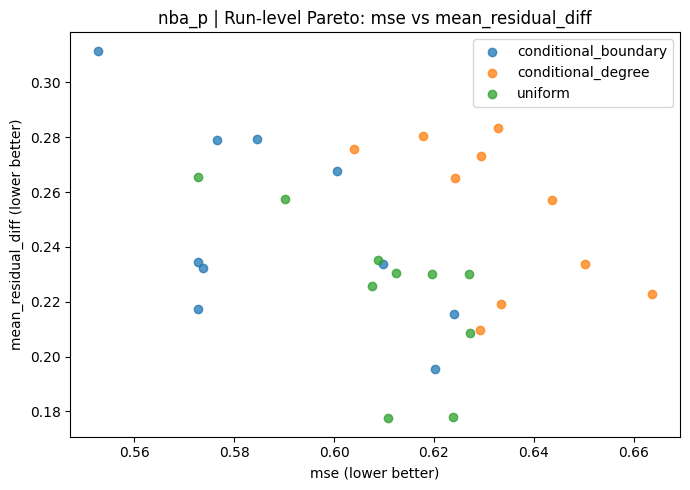

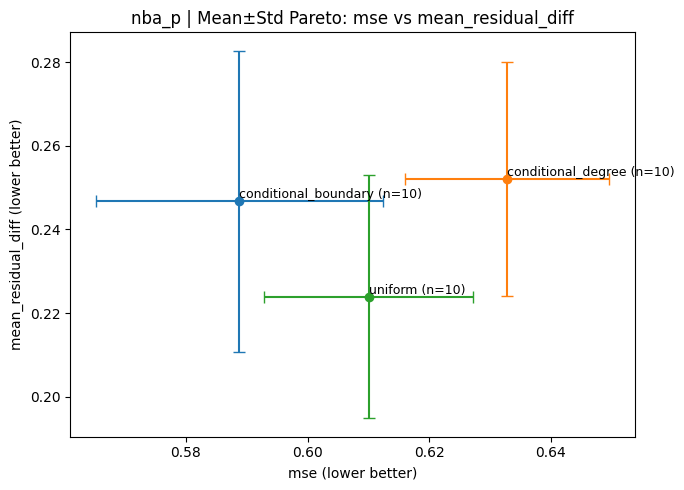

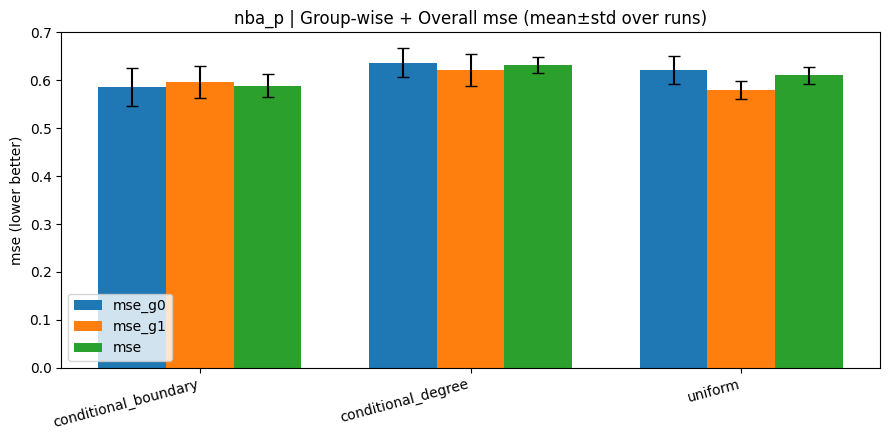

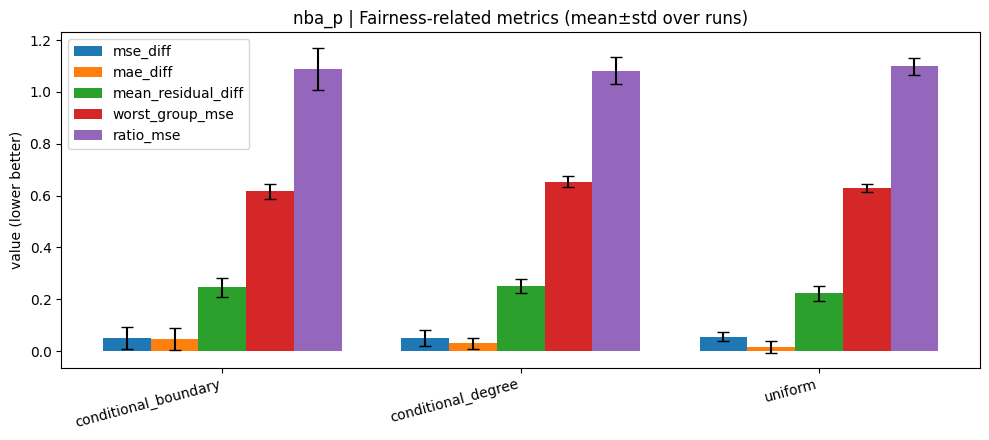

In [63]:
def _to_df(uniform_results, degree_results, boundary_results):
    df_u = pd.DataFrame(uniform_results).copy()
    df_u["variant"] = "uniform"

    df_d = pd.DataFrame(degree_results).copy()
    df_d["variant"] = "conditional_degree"

    df_b = pd.DataFrame(boundary_results).copy()
    df_b["variant"] = "conditional_boundary"

    df = pd.concat([df_u, df_d, df_b], ignore_index=True)
    return df

def _coerce_numeric(df, cols):
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df

# -------------------------------------------------------
# 1) Run-level Pareto scatter: (overall performance) vs (fairness)
# -------------------------------------------------------
def plot_pareto_runs(uniform_results, degree_results, boundary_results,
                     ds="nba_p",
                     perf="mse",
                     fair="mean_residual_diff",
                     annotate=False):
    df = _to_df(uniform_results, degree_results, boundary_results)
    df = df[df["ds"] == ds].copy()
    df = _coerce_numeric(df, [perf, fair, "run"])

    plt.figure(figsize=(7, 5))
    for v, sub in df.groupby("variant"):
        plt.scatter(sub[perf], sub[fair], alpha=0.75, label=v)

        if annotate and "run" in sub.columns:
            for _, r in sub.iterrows():
                plt.text(float(r[perf]), float(r[fair]), str(int(r["run"])),
                         fontsize=8, ha="left", va="bottom")

    plt.xlabel(f"{perf} (lower better)")
    plt.ylabel(f"{fair} (lower better)")
    plt.title(f"{ds} | Run-level Pareto: {perf} vs {fair}")
    plt.legend()
    plt.tight_layout()
    plt.show()


# -------------------------------------------------------
# 2) Mean±Std Pareto: variant별 평균 점 + errorbar
# -------------------------------------------------------
def plot_pareto_meanstd(uniform_results, degree_results, boundary_results,
                        ds="nba_p",
                        perf="mse",
                        fair="mean_residual_diff"):
    df = _to_df(uniform_results, degree_results, boundary_results)
    df = df[df["ds"] == ds].copy()
    df = _coerce_numeric(df, [perf, fair])

    g = df.groupby("variant").agg(
        perf_mean=(perf, "mean"),
        perf_std=(perf, "std"),
        fair_mean=(fair, "mean"),
        fair_std=(fair, "std"),
        n=("variant", "size")
    ).reset_index()

    plt.figure(figsize=(7, 5))
    for _, r in g.iterrows():
        plt.errorbar(
            float(r["perf_mean"]), float(r["fair_mean"]),
            xerr=float(r["perf_std"]) if np.isfinite(r["perf_std"]) else None,
            yerr=float(r["fair_std"]) if np.isfinite(r["fair_std"]) else None,
            fmt="o", capsize=4
        )
        plt.text(float(r["perf_mean"]), float(r["fair_mean"]),
                 f'{r["variant"]} (n={int(r["n"])})',
                 fontsize=9, ha="left", va="bottom")

    plt.xlabel(f"{perf} (lower better)")
    plt.ylabel(f"{fair} (lower better)")
    plt.title(f"{ds} | Mean±Std Pareto: {perf} vs {fair}")
    plt.tight_layout()
    plt.show()


# -------------------------------------------------------
# 3) Group-wise performance bars (g0 vs g1) + overall
#    -> gap만 보지 말고 "누굴 희생했는지"까지 보여줌
# -------------------------------------------------------
def plot_groupwise_error_bars(uniform_results, degree_results, boundary_results,
                              ds="nba_p",
                              metric_prefix="mse"):
    """
    metric_prefix="mse"이면 mse_g0, mse_g1, mse 사용
    metric_prefix="mae"이면 mae_g0, mae_g1, mae 사용
    """
    df = _to_df(uniform_results, degree_results, boundary_results)
    df = df[df["ds"] == ds].copy()

    overall = metric_prefix  # "mse" or "mae"
    g0 = f"{metric_prefix}_g0"
    g1 = f"{metric_prefix}_g1"

    need = [overall, g0, g1]
    for c in need:
        if c not in df.columns:
            raise KeyError(f"Column '{c}' not found. Need {need} to plot group-wise bars.")

    df = _coerce_numeric(df, need)

    agg = df.groupby("variant").agg(
        overall_mean=(overall, "mean"),
        overall_std=(overall, "std"),
        g0_mean=(g0, "mean"),
        g0_std=(g0, "std"),
        g1_mean=(g1, "mean"),
        g1_std=(g1, "std"),
    ).reset_index()

    x = np.arange(len(agg))
    width = 0.25

    plt.figure(figsize=(9, 4.5))
    plt.bar(x - width, agg["g0_mean"], width,
            yerr=agg["g0_std"], capsize=4, label=f"{g0}")
    plt.bar(x, agg["g1_mean"], width,
            yerr=agg["g1_std"], capsize=4, label=f"{g1}")
    plt.bar(x + width, agg["overall_mean"], width,
            yerr=agg["overall_std"], capsize=4, label=f"{overall}")

    plt.xticks(x, agg["variant"], rotation=15, ha="right")
    plt.ylabel(f"{metric_prefix} (lower better)")
    plt.title(f"{ds} | Group-wise + Overall {metric_prefix} (mean±std over runs)")
    plt.legend()
    plt.tight_layout()
    plt.show()


# -------------------------------------------------------
# 4) Fairness gap bars (abs gap) for multiple fairness metrics
# -------------------------------------------------------
def plot_fairness_gaps(uniform_results, degree_results, boundary_results,
                       ds="nba_p",
                       fairness_metrics=("mse_diff", "mean_residual_diff", "worst_group_mse")):
    df = _to_df(uniform_results, degree_results, boundary_results)
    df = df[df["ds"] == ds].copy()

    # 존재하는 지표만 사용
    fm = [m for m in fairness_metrics if m in df.columns]
    if not fm:
        raise KeyError(f"None of fairness_metrics exist in df. Tried: {fairness_metrics}")

    df = _coerce_numeric(df, fm)

    agg = df.groupby("variant")[fm].agg(["mean", "std"])
    agg.columns = [f"{a}_{b}" for a, b in agg.columns]
    agg = agg.reset_index()

    x = np.arange(len(agg))
    width = 0.8 / len(fm)

    plt.figure(figsize=(10, 4.5))
    for i, m in enumerate(fm):
        mean_col = f"{m}_mean"
        std_col = f"{m}_std"
        plt.bar(x + i*width, agg[mean_col], width,
                yerr=agg[std_col], capsize=4, label=m)

    plt.xticks(x + width*(len(fm)-1)/2, agg["variant"], rotation=15, ha="right")
    plt.ylabel("value (lower better)")
    plt.title(f"{ds} | Fairness-related metrics (mean±std over runs)")
    plt.legend()
    plt.tight_layout()
    plt.show()


# -------------------------------------------------------
# 5) 한 방에 실행하는 래퍼
# -------------------------------------------------------
def plot_all_tradeoff(uniform_results, degree_results, boundary_results, ds="nba_p"):
    # 1) Run-level Pareto (추천 fairness 축: mean_residual_diff)
    fair_axis = "mean_residual_diff" if "mean_residual_diff" in pd.DataFrame(uniform_results).columns else "mse_diff"
    plot_pareto_runs(uniform_results, degree_results, boundary_results, ds=ds, perf="mse", fair=fair_axis)

    # 2) Mean±Std Pareto
    plot_pareto_meanstd(uniform_results, degree_results, boundary_results, ds=ds, perf="mse", fair=fair_axis)

    # 3) Group-wise mse bars (가능할 때만)
    df_all = _to_df(uniform_results, degree_results, boundary_results)
    df_all = df_all[df_all["ds"] == ds].copy()
    if all(c in df_all.columns for c in ["mse_g0", "mse_g1", "mse"]):
        plot_groupwise_error_bars(uniform_results, degree_results, boundary_results, ds=ds, metric_prefix="mse")

    # 4) Fairness gaps bars
    plot_fairness_gaps(uniform_results, degree_results, boundary_results, ds=ds,
                       fairness_metrics=("mse_diff", "mae_diff", "mean_residual_diff", "worst_group_mse", "ratio_mse"))


# -------------------------
# 사용 예시
# -------------------------
plot_all_tradeoff(uniform_results, degree_results, boundary_results, ds="nba_p")

# 또는 개별로:
# plot_pareto_runs(uniform_results, degree_results, boundary_results, ds="nba_p", perf="mse", fair="mse_diff")
# plot_pareto_runs(uniform_results, degree_results, boundary_results, ds="nba_p", perf="mse", fair="mean_residual_diff")
# plot_groupwise_error_bars(uniform_results, degree_results, boundary_results, ds="nba_p", metric_prefix="mse")
# plot_fairness_gaps(uniform_results, degree_results, boundary_results, ds="nba_p")


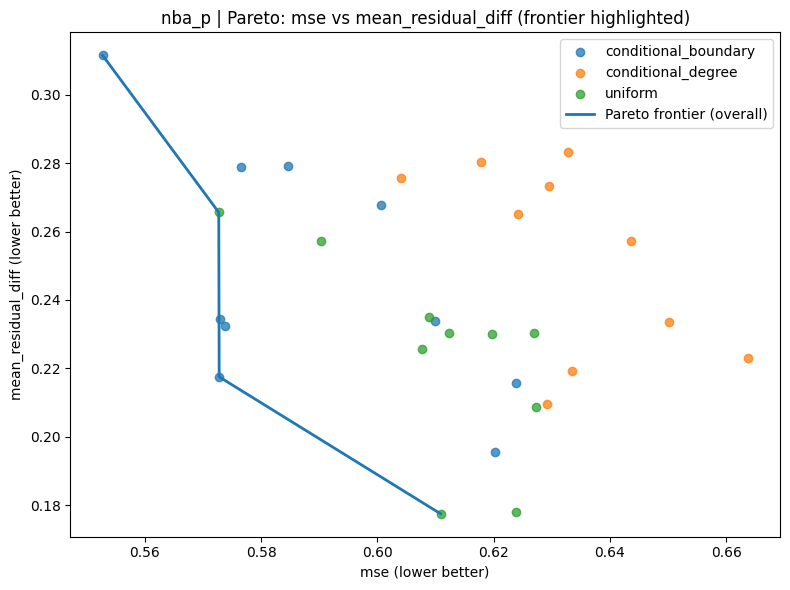

In [64]:
def _to_df(uniform_results, degree_results, boundary_results):
    df_u = pd.DataFrame(uniform_results).copy()
    df_u["variant"] = "uniform"

    df_d = pd.DataFrame(degree_results).copy()
    df_d["variant"] = "conditional_degree"

    df_b = pd.DataFrame(boundary_results).copy()
    df_b["variant"] = "conditional_boundary"

    return pd.concat([df_u, df_d, df_b], ignore_index=True)

def _coerce_numeric(df, cols):
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df

def pareto_mask_minimize(points_xy: np.ndarray) -> np.ndarray:
    """
    points_xy: shape (N,2) where both objectives are to be minimized.
    returns: boolean mask of pareto-optimal points (non-dominated)
    """
    x = points_xy[:, 0]
    y = points_xy[:, 1]
    n = len(x)
    mask = np.ones(n, dtype=bool)

    # O(N^2)지만 N이 run*조건 수준이면 충분히 작음
    for i in range(n):
        if not mask[i]:
            continue
        # i를 지배하는 점이 있으면 i는 frontier 아님:
        # (xj <= xi and yj <= yi) and at least one strict
        dominated = (x <= x[i]) & (y <= y[i]) & ((x < x[i]) | (y < y[i]))
        dominated[i] = False
        if dominated.any():
            mask[i] = False

    return mask

def plot_pareto_with_frontier(
    uniform_results, degree_results, boundary_results,
    ds="nba_p",
    perf="mse",
    fair="mean_residual_diff",
    show_overall_frontier=True,
    show_variant_frontier=False,
    annotate_frontier=False,
):
    """
    perf, fair: 둘 다 낮을수록 좋은 지표여야 함.
    - show_overall_frontier: 전체 점들에서 frontier
    - show_variant_frontier: variant별 frontier도 따로 표시
    """

    df = _to_df(uniform_results, degree_results, boundary_results)
    df = df[df["ds"] == ds].copy()
    df = _coerce_numeric(df, [perf, fair, "run"])
    df = df.dropna(subset=[perf, fair])

    plt.figure(figsize=(8, 6))

    # 1) scatter by variant
    for v, sub in df.groupby("variant"):
        plt.scatter(sub[perf], sub[fair], alpha=0.75, label=v)

    # 2) overall pareto frontier
    if show_overall_frontier and len(df) > 0:
        pts = df[[perf, fair]].to_numpy(dtype=float)
        mask = pareto_mask_minimize(pts)

        frontier = df.loc[mask].copy()
        # frontier는 perf 기준으로 정렬해서 선으로 연결 (보통 보기 좋음)
        frontier = frontier.sort_values(by=perf)

        plt.plot(frontier[perf], frontier[fair], linewidth=2, label="Pareto frontier (overall)")

        if annotate_frontier and "run" in df.columns:
            for _, r in frontier.iterrows():
                txt = f'{r["variant"]}:{int(r["run"])}' if pd.notnull(r.get("run", np.nan)) else str(r["variant"])
                plt.text(float(r[perf]), float(r[fair]), txt, fontsize=8, ha="left", va="bottom")

    # 3) variant별 frontier (원하면)
    if show_variant_frontier:
        for v, sub in df.groupby("variant"):
            pts_v = sub[[perf, fair]].to_numpy(dtype=float)
            if len(pts_v) == 0:
                continue
            mask_v = pareto_mask_minimize(pts_v)
            fr_v = sub.loc[mask_v].copy().sort_values(by=perf)
            plt.plot(fr_v[perf], fr_v[fair], linestyle="--", linewidth=1.5, label=f"frontier ({v})")

    plt.xlabel(f"{perf} (lower better)")
    plt.ylabel(f"{fair} (lower better)")
    plt.title(f"{ds} | Pareto: {perf} vs {fair} (frontier highlighted)")
    plt.legend()
    plt.tight_layout()
    plt.show()

# (1) 추천: overall frontier만
plot_pareto_with_frontier(uniform_results, degree_results, boundary_results,
                          ds="nba_p", perf="mse", fair="mean_residual_diff",
                          show_overall_frontier=True, show_variant_frontier=False)

# (2) variant별 frontier도 함께 (그림이 조금 복잡해짐)
# plot_pareto_with_frontier(uniform_results, degree_results, boundary_results,
#                           ds="nba_p", perf="mse", fair="mse_diff",
#                           show_overall_frontier=True, show_variant_frontier=True)

# (3) frontier 점에 run 라벨까지
# plot_pareto_with_frontier(uniform_results, degree_results, boundary_results,
#                           ds="nba_p", perf="mse", fair="mean_residual_diff",
#                           annotate_frontier=True)


### 실험 2

In [117]:
# ds 선택
ds = 'nba_p'
data = dt_dict[ds]['data']
cfg = dt_dict[ds]['cfg']
dn = cfg['dn']

# 디바이스
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print("device:", device)

# dtype 정리 (특히 sensitive_attr!)
data = data.to(device)
data.x = data.x.float()
data.y = data.y.float()
data.sensitive_attr = data.sensitive_attr.long()

# 하이퍼파라미터
runs = 10
epochs = 500
lr = 1e-3
weight_decay = 1e-5

modes = ["uniform", "low_degree", "boundary", "norm_boundary"]
# alphas = [0.0, 0.1, 0.3, 0.5, 1.0, 2.0]   # alpha sweep
alphas = [0.0] + [10**x for x in [-3, -2.5, -2, -1.5, -1, -0.5, 0, 0.5]] # log-scale sweep


# 저장 폴더
save_dir = "./FnRGNN"
os.makedirs(save_dir, exist_ok=True)

# 전체 결과 저장 (mode/alpha/run 전부 포함)
results_all = []

for mode in modes:
    for alpha in alphas:
        print(f"\n===== START | ds={ds} | mode={mode} | alpha={alpha} =====")

        for run in range(runs):
            seed = 1127 + run
            np.random.seed(seed)
            torch.manual_seed(seed)
            if torch.cuda.is_available():
                torch.cuda.manual_seed_all(seed)

            # run마다 모델 새로 생성
            model = FnRGNN(
                nfeat=data.x.size(1), hidden_dim=64, dropout=0.5,
                lm=3, ld=1, mmd_sample=500, lr=lr, weight_decay=weight_decay,
                fairness_mode=mode
            ).to(device)

            best_score = float('inf')
            best_path = os.path.join(save_dir, f"{dn}_ds{ds}_mode{mode}_a{alpha}_run{run}.pth")

            for epoch in range(epochs):
                loss = model.optimize(data)

                # validation
                model.eval()
                with torch.no_grad():
                    pred, _ = model(data)
                    y_true = data.y
                    idx_val = data.idx_val
                    sens_val = data.sensitive_attr

                    mse_val = mean_squared_error(
                        y_true[idx_val].detach().cpu().numpy(),
                        pred[idx_val].detach().cpu().numpy()
                    )
                    mae_val = mean_absolute_error(
                        y_true[idx_val].detach().cpu().numpy(),
                        pred[idx_val].detach().cpu().numpy()
                    )

                    m_val = fair_metric_regression_v2(
                        pred[idx_val], y_true[idx_val], sens_val[idx_val],
                        group_values=(0, 1)
                    )

                    # 안전한 fairness penalty 추출
                    mean_resid_gap = safe_fairness_penalty(
                        m_val, fair_key="mean_residual_gap", missing="zero"
                    )

                    # robust (NaN 방지)
                    worst_group_mse = m_val["fairness_aggregates"]["worst_group_mse"]
                    if not np.isfinite(worst_group_mse):
                        worst_group_mse = mse_val

                    # val score: mse + alpha * fairness
                    # (원하면 beta도 추가 가능)
                    val_score = mse_val + alpha * mean_resid_gap

                    if val_score < best_score:
                        best_score = val_score
                        torch.save(model.state_dict(), best_path)

                if epoch % 50 == 0:
                    g0n = m_val["group"]["0"]["n"]
                    g1n = m_val["group"]["1"]["n"]
                    print(
                        f"[{ds} | {mode} | a={alpha} | run {run} | ep {epoch}] "
                        f"loss {loss:.4f} | val mse {mse_val:.4f} mae {mae_val:.4f} | "
                        f"mean_resid_gap {mean_resid_gap:.4f} | worst_g_mse {worst_group_mse:.4f} | "
                        f"n(g0,g1)=({g0n},{g1n})"
                    )

            # test (best 로드)
            model.load_state_dict(torch.load(best_path, map_location=device))
            model.eval()
            with torch.no_grad():
                pred, _ = model(data)
                y_true = data.y
                idx_test = data.idx_test
                sens_test = data.sensitive_attr

                mse_test = mean_squared_error(
                    y_true[idx_test].detach().cpu().numpy(),
                    pred[idx_test].detach().cpu().numpy()
                )
                mae_test = mean_absolute_error(
                    y_true[idx_test].detach().cpu().numpy(),
                    pred[idx_test].detach().cpu().numpy()
                )

                m_test = fair_metric_regression_v2(
                    pred[idx_test], y_true[idx_test], sens_test[idx_test],
                    group_values=(0, 1)
                )

            g0 = m_test["group"]["0"]
            g1 = m_test["group"]["1"]
            disp = m_test["disparity"]
            agg = m_test["fairness_aggregates"]

            results_all.append({
                "ds": ds,
                "mode": mode,
                "alpha": float(alpha),
                "run": run,

                # overall perf
                "mse": mse_test,
                "mae": mae_test,

                # group-wise
                "n_g0": g0["n"],
                "n_g1": g1["n"],
                "mse_g0": g0["mse"],
                "mse_g1": g1["mse"],
                "mae_g0": g0["mae"],
                "mae_g1": g1["mae"],
                "mean_residual_g0": g0["mean_residual"],
                "mean_residual_g1": g1["mean_residual"],

                # gaps (abs)
                "mse_diff": disp["mse"]["abs_diff"],
                "mae_diff": disp["mae"]["abs_diff"],
                "mean_residual_diff": disp["mean_residual"]["abs_diff"],

                # signed (g1 - g0)
                "mse_signed_g1_minus_g0": disp["mse"]["signed_diff_g1_minus_g0"],
                "mae_signed_g1_minus_g0": disp["mae"]["signed_diff_g1_minus_g0"],
                "mean_residual_signed_g1_minus_g0": disp["mean_residual"]["signed_diff_g1_minus_g0"],

                # robust
                "worst_group_mse": agg["worst_group_mse"],
                "worst_group_mae": agg["worst_group_mae"],
                "ratio_mse": agg["ratio_mse"],
                "ratio_mae": agg["ratio_mae"],

                # bookkeeping
                "best_val_score": float(best_score),
                "best_ckpt": best_path,
            })

        # (선택) 조합별로 중간 저장 (실험 길면 강추)
        df_tmp = pd.DataFrame([r for r in results_all if r["mode"] == mode and r["alpha"] == float(alpha)])
        out_csv = os.path.join(save_dir, f"results_{dn}_ds{ds}_mode{mode}_a{alpha}.csv")
        df_tmp.to_csv(out_csv, index=False)
        print(f"Saved: {out_csv}  (rows={len(df_tmp)})")

# 전체 저장
df_all = pd.DataFrame(results_all)
out_all = os.path.join(save_dir, f"results_{dn}_ds{ds}_ALL.csv")
df_all.to_csv(out_all, index=False)
print(f"\nALL DONE. Saved: {out_all} (rows={len(df_all)})")

device: cuda:0

===== START | ds=nba_p | mode=uniform | alpha=0.0 =====
[nba_p | uniform | a=0.0 | run 0 | ep 0] loss 1.0289 | val mse 0.9325 mae 0.7362 | mean_resid_gap 0.0966 | worst_g_mse 0.9494 | n(g0,g1)=(73,26)
[nba_p | uniform | a=0.0 | run 0 | ep 50] loss 0.9281 | val mse 0.8092 mae 0.6988 | mean_resid_gap 0.0615 | worst_g_mse 0.8353 | n(g0,g1)=(73,26)
[nba_p | uniform | a=0.0 | run 0 | ep 100] loss 0.8351 | val mse 0.7657 mae 0.6792 | mean_resid_gap 0.0256 | worst_g_mse 0.7829 | n(g0,g1)=(73,26)
[nba_p | uniform | a=0.0 | run 0 | ep 150] loss 0.7527 | val mse 0.7368 mae 0.6627 | mean_resid_gap 0.0278 | worst_g_mse 0.7805 | n(g0,g1)=(73,26)
[nba_p | uniform | a=0.0 | run 0 | ep 200] loss 0.7786 | val mse 0.7646 mae 0.6533 | mean_resid_gap 0.0863 | worst_g_mse 1.0225 | n(g0,g1)=(73,26)
[nba_p | uniform | a=0.0 | run 0 | ep 250] loss 0.6724 | val mse 0.8013 mae 0.6573 | mean_resid_gap 0.1716 | worst_g_mse 1.1926 | n(g0,g1)=(73,26)
[nba_p | uniform | a=0.0 | run 0 | ep 300] loss 0

/tmp/ipykernel_288109/1060167816.py:110: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_path, map_location=device))


[nba_p | uniform | a=0.0 | run 1 | ep 0] loss 0.9831 | val mse 0.8821 mae 0.7286 | mean_resid_gap 0.0801 | worst_g_mse 0.9092 | n(g0,g1)=(73,26)
[nba_p | uniform | a=0.0 | run 1 | ep 50] loss 0.9158 | val mse 0.8214 mae 0.7044 | mean_resid_gap 0.0696 | worst_g_mse 0.8479 | n(g0,g1)=(73,26)
[nba_p | uniform | a=0.0 | run 1 | ep 100] loss 0.8674 | val mse 0.7745 mae 0.6799 | mean_resid_gap 0.0646 | worst_g_mse 0.7991 | n(g0,g1)=(73,26)
[nba_p | uniform | a=0.0 | run 1 | ep 150] loss 0.8491 | val mse 0.7261 mae 0.6561 | mean_resid_gap 0.0374 | worst_g_mse 0.7440 | n(g0,g1)=(73,26)
[nba_p | uniform | a=0.0 | run 1 | ep 200] loss 0.7294 | val mse 0.7031 mae 0.6467 | mean_resid_gap 0.0076 | worst_g_mse 0.7037 | n(g0,g1)=(73,26)
[nba_p | uniform | a=0.0 | run 1 | ep 250] loss 0.7161 | val mse 0.7174 mae 0.6425 | mean_resid_gap 0.0640 | worst_g_mse 0.8859 | n(g0,g1)=(73,26)
[nba_p | uniform | a=0.0 | run 1 | ep 300] loss 0.6684 | val mse 0.7591 mae 0.6540 | mean_resid_gap 0.1638 | worst_g_mse 

/tmp/ipykernel_288109/1060167816.py:110: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_path, map_location=device))


[nba_p | uniform | a=0.0 | run 2 | ep 0] loss 1.0174 | val mse 0.9119 mae 0.7421 | mean_resid_gap 0.0865 | worst_g_mse 0.9357 | n(g0,g1)=(73,26)
[nba_p | uniform | a=0.0 | run 2 | ep 50] loss 0.8972 | val mse 0.8208 mae 0.7038 | mean_resid_gap 0.0737 | worst_g_mse 0.8473 | n(g0,g1)=(73,26)
[nba_p | uniform | a=0.0 | run 2 | ep 100] loss 0.8612 | val mse 0.7662 mae 0.6768 | mean_resid_gap 0.0501 | worst_g_mse 0.7898 | n(g0,g1)=(73,26)
[nba_p | uniform | a=0.0 | run 2 | ep 150] loss 0.7650 | val mse 0.7186 mae 0.6558 | mean_resid_gap 0.0056 | worst_g_mse 0.7326 | n(g0,g1)=(73,26)
[nba_p | uniform | a=0.0 | run 2 | ep 200] loss 0.7579 | val mse 0.7027 mae 0.6414 | mean_resid_gap 0.0107 | worst_g_mse 0.7432 | n(g0,g1)=(73,26)
[nba_p | uniform | a=0.0 | run 2 | ep 250] loss 0.6944 | val mse 0.7073 mae 0.6447 | mean_resid_gap 0.0904 | worst_g_mse 0.8034 | n(g0,g1)=(73,26)
[nba_p | uniform | a=0.0 | run 2 | ep 300] loss 0.7137 | val mse 0.7824 mae 0.6499 | mean_resid_gap 0.0843 | worst_g_mse 

...

/tmp/ipykernel_288109/1060167816.py:110: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_path, map_location=device))


[nba_p | norm_boundary | a=3.1622776601683795 | run 8 | ep 0] loss 1.2704 | val mse 0.8735 mae 0.7285 | mean_resid_gap 0.0774 | worst_g_mse 0.9030 | n(g0,g1)=(73,26)
[nba_p | norm_boundary | a=3.1622776601683795 | run 8 | ep 50] loss 0.9411 | val mse 0.8704 mae 0.7268 | mean_resid_gap 0.0801 | worst_g_mse 0.8994 | n(g0,g1)=(73,26)
[nba_p | norm_boundary | a=3.1622776601683795 | run 8 | ep 100] loss 0.9344 | val mse 0.8709 mae 0.7292 | mean_resid_gap 0.0785 | worst_g_mse 0.9000 | n(g0,g1)=(73,26)
[nba_p | norm_boundary | a=3.1622776601683795 | run 8 | ep 150] loss 0.9173 | val mse 0.8642 mae 0.7266 | mean_resid_gap 0.0798 | worst_g_mse 0.8910 | n(g0,g1)=(73,26)
[nba_p | norm_boundary | a=3.1622776601683795 | run 8 | ep 200] loss 0.9256 | val mse 0.8603 mae 0.7253 | mean_resid_gap 0.0814 | worst_g_mse 0.8860 | n(g0,g1)=(73,26)
[nba_p | norm_boundary | a=3.1622776601683795 | run 8 | ep 250] loss 0.9011 | val mse 0.8533 mae 0.7225 | mean_resid_gap 0.0791 | worst_g_mse 0.8782 | n(g0,g1)=(73

/tmp/ipykernel_288109/1060167816.py:110: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_path, map_location=device))


[nba_p | norm_boundary | a=3.1622776601683795 | run 9 | ep 0] loss 1.7497 | val mse 0.8803 mae 0.7344 | mean_resid_gap 0.0830 | worst_g_mse 0.9118 | n(g0,g1)=(73,26)
[nba_p | norm_boundary | a=3.1622776601683795 | run 9 | ep 50] loss 0.9976 | val mse 0.8742 mae 0.7279 | mean_resid_gap 0.0755 | worst_g_mse 0.9033 | n(g0,g1)=(73,26)
[nba_p | norm_boundary | a=3.1622776601683795 | run 9 | ep 100] loss 0.9307 | val mse 0.8748 mae 0.7292 | mean_resid_gap 0.0716 | worst_g_mse 0.9052 | n(g0,g1)=(73,26)
[nba_p | norm_boundary | a=3.1622776601683795 | run 9 | ep 150] loss 0.9291 | val mse 0.8727 mae 0.7279 | mean_resid_gap 0.0687 | worst_g_mse 0.9032 | n(g0,g1)=(73,26)
[nba_p | norm_boundary | a=3.1622776601683795 | run 9 | ep 200] loss 0.9232 | val mse 0.8678 mae 0.7255 | mean_resid_gap 0.0669 | worst_g_mse 0.8977 | n(g0,g1)=(73,26)
[nba_p | norm_boundary | a=3.1622776601683795 | run 9 | ep 250] loss 0.9192 | val mse 0.8609 mae 0.7220 | mean_resid_gap 0.0635 | worst_g_mse 0.8905 | n(g0,g1)=(73

/tmp/ipykernel_288109/1060167816.py:110: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_path, map_location=device))


In [118]:
# df = pd.DataFrame(results_all)
df = pd.read_csv("./FnRGNN/results_NBA(PIE)_Country_dsnba_p_ALL.csv")

In [119]:
df.head()

,ds,mode,alpha,run,mse,mae,n_g0,n_g1,mse_g0,mse_g1,...,mean_residual_diff,mse_signed_g1_minus_g0,mae_signed_g1_minus_g0,mean_residual_signed_g1_minus_g0,worst_group_mse,worst_group_mae,ratio_mse,ratio_mae,best_val_score,best_ckpt
0,nba_p,uniform,0.0,0,0.610647,0.580375,73,27,0.625937,0.569308,...,0.237839,-0.056629,0.004245,0.237839,0.625937,0.583474,1.099470,1.007328,0.734550,./FnRGNN/NBA(PIE)_Country_dsnba_p_modeuniform_...
1,nba_p,uniform,0.0,1,0.584932,0.568009,73,27,0.594611,0.558763,...,0.288003,-0.035848,0.006348,0.288003,0.594611,0.572643,1.064156,1.011210,0.694428,./FnRGNN/NBA(PIE)_Country_dsnba_p_modeuniform_...
2,nba_p,uniform,0.0,2,0.594928,0.580505,73,27,0.590905,0.605805,...,0.278375,0.014901,0.039132,0.278375,0.605805,0.609072,1.025217,1.068660,0.694369,./FnRGNN/NBA(PIE)_Country_dsnba_p_modeuniform_...
3,nba_p,uniform,0.0,3,0.616669,0.578458,73,27,0.633116,0.572201,...,0.242228,-0.060915,-0.003139,0.242228,0.633116,0.579306,1.106458,1.005449,0.734001,./FnRGNN/NBA(PIE)_Country_dsnba_p_modeuniform_...
4,nba_p,uniform,0.0,4,0.616139,0.580431,73,27,0.622037,0.600195,...,0.265613,-0.021841,0.029285,0.265613,0.622037,0.601809,1.036390,1.051151,0.722191,./FnRGNN/NBA(PIE)_Country_dsnba_p_modeuniform_...


In [120]:
# (mode, alpha)별 평균 ± 표준편차 요약표 (가장 기본)
METRICS = [
    "mse", "mae", 
    "worst_group_mse", "worst_group_mae",
    "mse_diff", "mae_diff",
    "mean_residual_diff",
    "ratio_mse", "ratio_mae",
]

summary = (
    df.groupby(["mode", "alpha"])[METRICS]
      .agg(["mean", "std"])
      .reset_index()
)

# 컬럼 정리
summary.columns = [
    f"{c[0]}_{c[1]}" if c[1] else c[0]
    for c in summary.columns
]

# 보기 좋게 정렬
summary = summary.sort_values(["mode", "alpha"])

# 소수점 정리
for c in summary.columns:
    if c not in ["mode", "alpha"]:
        summary[c] = summary[c].astype(float).round(4)

summary


,mode,alpha,mse_mean,mse_std,mae_mean,mae_std,worst_group_mse_mean,worst_group_mse_std,worst_group_mae_mean,worst_group_mae_std,mse_diff_mean,mse_diff_std,mae_diff_mean,mae_diff_std,mean_residual_diff_mean,mean_residual_diff_std,ratio_mse_mean,ratio_mse_std,ratio_mae_mean,ratio_mae_std
0,boundary,0.000000,0.5762,0.0141,0.5735,0.0046,0.6286,0.0321,0.6396,0.0286,0.0720,0.0553,0.0904,0.0407,0.3176,0.0359,1.1337,0.1065,1.1663,0.0781
1,boundary,0.001000,0.5767,0.0143,0.5739,0.0047,0.6305,0.0329,0.6412,0.0289,0.0740,0.0561,0.0921,0.0412,0.3183,0.0364,1.1372,0.1078,1.1695,0.0791
2,boundary,0.003162,0.5754,0.0141,0.5730,0.0039,0.6275,0.0304,0.6385,0.0266,0.0717,0.0549,0.0898,0.0396,0.3127,0.0248,1.1334,0.1062,1.1652,0.0763
3,boundary,0.010000,0.5762,0.0142,0.5735,0.0046,0.6288,0.0324,0.6400,0.0289,0.0724,0.0558,0.0911,0.0412,0.3174,0.0360,1.1345,0.1075,1.1676,0.0792
4,boundary,0.031623,0.5787,0.0176,0.5735,0.0045,0.6292,0.0348,0.6347,0.0350,0.0731,0.0584,0.0839,0.0502,0.3032,0.0427,1.1360,0.1121,1.1547,0.0954
5,boundary,0.100000,0.5783,0.0176,0.5726,0.0041,0.6228,0.0324,0.6286,0.0311,0.0650,0.0554,0.0766,0.0464,0.2941,0.0379,1.1208,0.1070,1.1410,0.0886
6,boundary,0.316228,0.5849,0.0231,0.5740,0.0079,0.6194,0.0332,0.6161,0.0326,0.0563,0.0525,0.0576,0.0501,0.2610,0.0329,1.1037,0.1023,1.1059,0.0951
7,boundary,1.000000,0.5962,0.0308,0.5769,0.0108,0.6246,0.0334,0.6067,0.0285,0.0571,0.0412,0.0424,0.0430,0.2464,0.0344,1.1024,0.0780,1.0771,0.0808
8,boundary,3.162278,0.6075,0.0321,0.5787,0.0117,0.6322,0.0307,0.5960,0.0267,0.0628,0.0338,0.0255,0.0409,0.2417,0.0307,1.1116,0.0650,1.0467,0.0768
9,low_degree,0.000000,0.6303,0.0154,0.5904,0.0078,0.6574,0.0343,0.6146,0.0274,0.0497,0.0432,0.0350,0.0325,0.2948,0.0416,1.0832,0.0737,1.0610,0.0570


In [121]:
summary = (
    df.groupby(["mode"])[METRICS]
      .agg(["mean"])
      .reset_index()
)

# 컬럼 정리
summary.columns = [
    f"{c[0]}_{c[1]}" if c[1] else c[0]
    for c in summary.columns
]

# 보기 좋게 정렬
summary = summary.sort_values(["mode"])

# 소수점 정리
for c in summary.columns:
    if c not in ["mode"]:
        summary[c] = summary[c].astype(float).round(4)

summary

,mode,mse_mean,mae_mean,worst_group_mse_mean,worst_group_mae_mean,mse_diff_mean,mae_diff_mean,mean_residual_diff_mean,ratio_mse_mean,ratio_mae_mean
0,boundary,0.5833,0.5744,0.6271,0.6268,0.0672,0.0722,0.2903,1.1237,1.1327
1,low_degree,0.6331,0.5913,0.6588,0.6124,0.0537,0.0333,0.2773,1.0899,1.0579
2,norm_boundary,0.6620,0.6093,0.6775,0.6305,0.0360,0.0302,0.2800,1.0569,1.0508
3,uniform,0.6065,0.5792,0.6353,0.6010,0.0641,0.0314,0.2524,1.1143,1.0568


In [122]:
# Accuracy–Bias trade-off만 강조한 핵심 표 (논문용)
tradeoff_table = (
    df.groupby(["mode", "alpha"])
      .agg(
          mse_mean=("mse", "mean"),
          mse_std=("mse", "std"),
          bias_mean=("mean_residual_diff", "mean"),
          bias_std=("mean_residual_diff", "std"),
      )
      .reset_index()
      .sort_values(["mode", "alpha"])
)

tradeoff_table = tradeoff_table.round(4)
tradeoff_table


,mode,alpha,mse_mean,mse_std,bias_mean,bias_std
0,boundary,0.0000,0.5762,0.0141,0.3176,0.0359
1,boundary,0.0010,0.5767,0.0143,0.3183,0.0364
2,boundary,0.0032,0.5754,0.0141,0.3127,0.0248
3,boundary,0.0100,0.5762,0.0142,0.3174,0.0360
4,boundary,0.0316,0.5787,0.0176,0.3032,0.0427
5,boundary,0.1000,0.5783,0.0176,0.2941,0.0379
6,boundary,0.3162,0.5849,0.0231,0.2610,0.0329
7,boundary,1.0000,0.5962,0.0308,0.2464,0.0344
8,boundary,3.1623,0.6075,0.0321,0.2417,0.0307
9,low_degree,0.0000,0.6303,0.0154,0.2948,0.0416


In [123]:
# Worst-group 성능 방어용 표
# “공정성 개선이 희생인가?”를 숫자로 확인

worst_group_table = (
    df.groupby(["mode", "alpha"])
      .agg(
          worst_mse_mean=("worst_group_mse", "mean"),
          worst_mse_std=("worst_group_mse", "std"),
          overall_mse_mean=("mse", "mean"),
      )
      .reset_index()
      .sort_values(["mode", "alpha"])
)

worst_group_table = worst_group_table.round(4)
worst_group_table


,mode,alpha,worst_mse_mean,worst_mse_std,overall_mse_mean
0,boundary,0.0000,0.6286,0.0321,0.5762
1,boundary,0.0010,0.6305,0.0329,0.5767
2,boundary,0.0032,0.6275,0.0304,0.5754
3,boundary,0.0100,0.6288,0.0324,0.5762
4,boundary,0.0316,0.6292,0.0348,0.5787
5,boundary,0.1000,0.6228,0.0324,0.5783
6,boundary,0.3162,0.6194,0.0332,0.5849
7,boundary,1.0000,0.6246,0.0334,0.5962
8,boundary,3.1623,0.6322,0.0307,0.6075
9,low_degree,0.0000,0.6574,0.0343,0.6303


In [124]:
# Pareto 후보만 뽑은 표
# “accuracy–bias trade-off”에서 지배(dominated)되지 않는 (mode, alpha) 조합만 남긴다.

def pareto_mask_minimize(points_xy: np.ndarray) -> np.ndarray:
    """
    points_xy: (N,2), both objectives minimized
    """
    n = len(points_xy)
    mask = np.ones(n, dtype=bool)
    for i in range(n):
        if not mask[i]:
            continue
        x_i, y_i = points_xy[i]
        dominated = (
            (points_xy[:, 0] <= x_i) &
            (points_xy[:, 1] <= y_i) &
            ((points_xy[:, 0] < x_i) | (points_xy[:, 1] < y_i))
        )
        dominated[i] = False
        if dominated.any():
            mask[i] = False
    return mask

pareto_df = (
    df.groupby(["mode", "alpha"])
      .agg(
          mse=("mse", "mean"),
          bias=("mean_residual_diff", "mean"),
          worst_group_mse=("worst_group_mse", "mean"),
      )
      .reset_index()
)

pts = pareto_df[["mse", "bias"]].to_numpy()
mask = pareto_mask_minimize(pts)

pareto_table = pareto_df[mask].sort_values("mse").round(4)
pareto_table


,mode,alpha,mse,bias,worst_group_mse
2,boundary,0.0032,0.5754,0.3127,0.6275
5,boundary,0.1000,0.5783,0.2941,0.6228
6,boundary,0.3162,0.5849,0.2610,0.6194
7,boundary,1.0000,0.5962,0.2464,0.6246
8,boundary,3.1623,0.6075,0.2417,0.6322
33,uniform,0.3162,0.6102,0.2245,0.6287
34,uniform,1.0000,0.6110,0.2210,0.6302


In [ ]:
# 본 실험 결과는 회귀 문제에서 정확도와 공정성(편향 감소) 사이에 명확한 trade-off가 존재함을 보여준다. 
# 공정성 가중치 α가 증가함에 따라 집단 간 평균 잔차 차이는 감소하는 반면, 전체 예측 오차는 점진적으로 증가하는 경향이 나타났으며, 이는 공정성을 강화할수록 일정 수준의 성능 손실이 불가피함을 의미한다.

# 이러한 trade-off 하에서 boundary 기반 공정성 적용 방식이 가장 합리적인 접근으로 나타났다.
# boundary 방식은 민감 집단이 혼합되는 구조적 경계 지점에만 선택적으로 공정성 제약을 적용함으로써, 낮은 α 구간에서도 편향을 효과적으로 줄이면서 전체 정확도와 최악 집단 성능을 안정적으로 유지하였다. 
# 이는 공정성 문제가 실제로 발생할 가능성이 높은 위치에만 개입함으로써, 불필요한 성능 손실을 최소화했기 때문으로 해석할 수 있다.

# 반면, 공정성을 모든 샘플에 동일하게 적용하는 uniform 방식은 비효율적인 trade-off를 초래하였다. 
# uniform 방식은 편향을 더 크게 감소시킬 수 있었으나, 그 대가로 전체 정확도와 최악 집단 성능 모두에서 boundary 방식보다 열등한 결과를 보였다. 
# 이는 공정성과 직접적인 관련이 없는 노드까지 동일한 강도로 규제함으로써 모델의 표현력을 과도하게 제한한 결과이다.

# 또한 low-degree 방식은 가장 부적절한 접근으로 확인되었다. 
# low-degree 방식은 이웃 수가 적은 노드를 불확실한 노드로 간주하여 공정성 제약을 적용하였으나, 이러한 불확실성은 주로 데이터 희소성에서 기인하며 공정성 문제의 핵심 원인인 집단 간 상호작용이나 편향 전파와는 직접적인 관련이 없다. 
# 그 결과, low-degree 방식은 정확도와 편향 모두에서 경쟁력 있는 성능을 보이지 못했으며, Pareto-optimal 설정에도 포함되지 않았다.

# 종합하면, 본 실험은 공정성 제약을 무차별적으로 적용하거나 단순한 불확실성 기준에 의존하는 것은 비효율적이며, 공정성 문제가 구조적으로 발생하는 지점을 식별하여 선별적으로 제약을 적용하는 것이 가장 효과적임을 시사한다. 
# 특히 boundary 기반 접근은 정확도–공정성 trade-off 상에서 가장 우수한 Pareto 영역을 형성하며, 공정성 개선이 특정 집단의 성능 희생에 의해 발생하지 않았음을 정량적으로 입증한다.

In [125]:
# mode별로 “최선의 α” 하나씩 뽑기
# bias ≤ 특정 threshold 안에서 mse가 최소인 설정

BIAS_MAX = 0.23  # 예시 threshold

best_under_constraint = (
    df.groupby(["mode", "alpha"])
      .agg(
          mse=("mse", "mean"),
          bias=("mean_residual_diff", "mean"),
      )
      .reset_index()
)

best_under_constraint = best_under_constraint[
    best_under_constraint["bias"] <= BIAS_MAX
]

best_per_mode = (
    best_under_constraint
    .sort_values("mse")
    .groupby("mode")
    .head(1)
    .round(4)
)

best_per_mode


,mode,alpha,mse,bias
33,uniform,0.3162,0.6102,0.2245


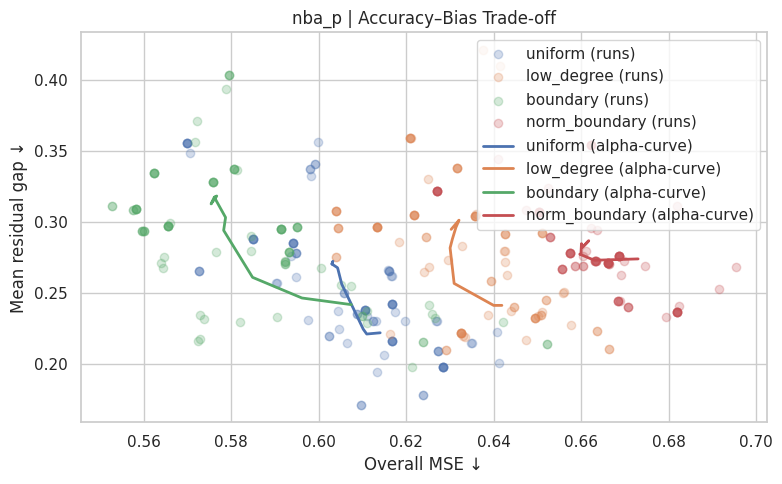

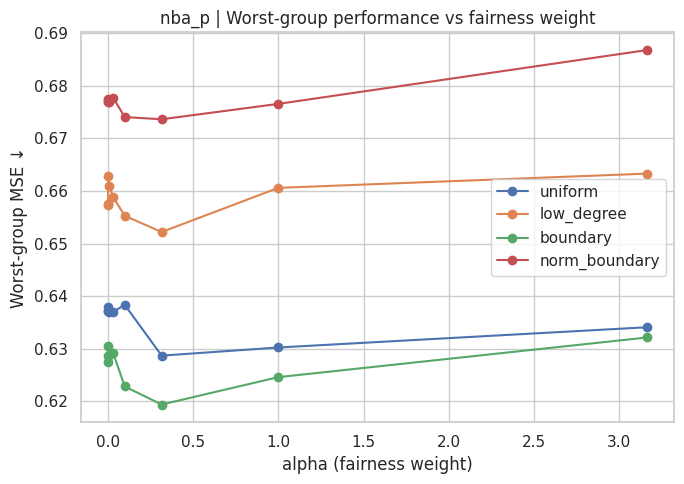

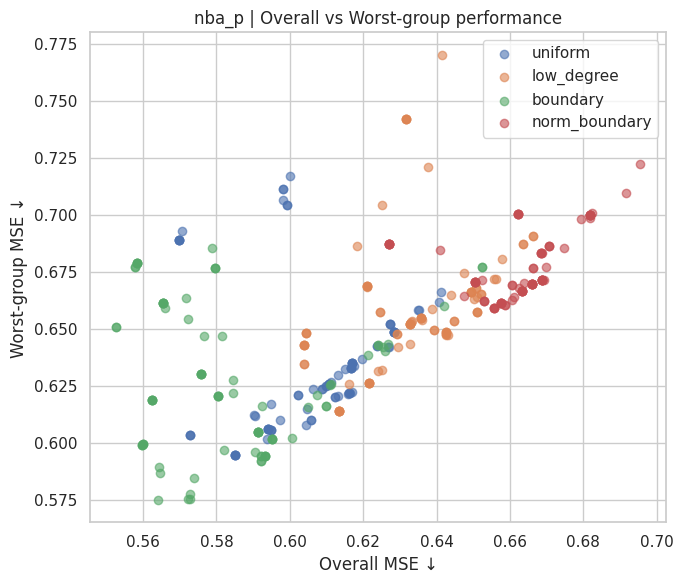

In [131]:
# 그림 1에서: “정확도–편향 trade-off가 관찰된다”
# 그림 2에서: “편향을 줄이는 과정이 특정 그룹을 희생한 결과는 아니다”
# So. 공정성 개선이 ‘의미 있는’ 개선임을 증명
# 그림 3: overall MSE vs worst_group_mse → 평균 vs 최악 비교

def plot_accuracy_bias_tradeoff(
    df,
    ds="nba_p",
    perf="mse",
    bias="mean_residual_diff",
    modes=("uniform", "low_degree", "boundary", "norm_boundary"),
):
    d = df[df["ds"] == ds].copy()
    d[perf] = pd.to_numeric(d[perf], errors="coerce")
    d[bias] = pd.to_numeric(d[bias], errors="coerce")

    plt.figure(figsize=(8, 5))

    # (1) run-level scatter (흐리게)
    for mode in modes:
        sub = d[d["mode"] == mode]
        plt.scatter(
            sub[perf], sub[bias],
            alpha=0.25,
            label=f"{mode} (runs)"
        )

    # (2) alpha 평균점 연결 (trade-off curve)
    for mode in modes:
        pts = []
        for a in sorted(d["alpha"].unique()):
            sub = d[(d["mode"] == mode) & (d["alpha"] == a)]
            if len(sub) == 0:
                continue
            pts.append((a, sub[perf].mean(), sub[bias].mean()))

        if len(pts) == 0:
            continue

        pts = sorted(pts, key=lambda x: x[0])
        xs = [p[1] for p in pts]
        ys = [p[2] for p in pts]

        plt.plot(xs, ys, linewidth=2, label=f"{mode} (alpha-curve)")
        # for a, x, y in pts:
        #     plt.text(x, y, f"α={a}", fontsize=9)

    plt.xlabel("Overall MSE ↓")
    plt.ylabel("Mean residual gap ↓")
    plt.title(f"{ds} | Accuracy–Bias Trade-off")
    plt.legend(loc='best')
    plt.tight_layout()
    plt.show()

def plot_worst_group_vs_alpha(
    df,
    ds="nba_p",
    modes=("uniform", "low_degree", "boundary", "norm_boundary"),
):
    d = df[df["ds"] == ds].copy()
    d["worst_group_mse"] = pd.to_numeric(d["worst_group_mse"], errors="coerce")

    plt.figure(figsize=(7, 5))

    for mode in modes:
        sub = d[d["mode"] == mode]
        g = sub.groupby("alpha")["worst_group_mse"].mean().reset_index()
        plt.plot(
            g["alpha"], g["worst_group_mse"],
            marker="o",
            label=mode
        )

    plt.xlabel("alpha (fairness weight)")
    plt.ylabel("Worst-group MSE ↓")
    plt.title(f"{ds} | Worst-group performance vs fairness weight")
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_overall_vs_worst_group(
    df,
    ds="nba_p",
    modes=("uniform", "low_degree", "boundary", "norm_boundary"),
):
    d = df[df["ds"] == ds].copy()
    d["mse"] = pd.to_numeric(d["mse"], errors="coerce")
    d["worst_group_mse"] = pd.to_numeric(d["worst_group_mse"], errors="coerce")

    plt.figure(figsize=(7, 6))

    for mode in modes:
        sub = d[d["mode"] == mode]
        plt.scatter(
            sub["mse"], sub["worst_group_mse"],
            alpha=0.6,
            label=mode
        )

    plt.xlabel("Overall MSE ↓")
    plt.ylabel("Worst-group MSE ↓")
    plt.title(f"{ds} | Overall vs Worst-group performance")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_accuracy_bias_tradeoff(df, ds="nba_p")
plot_worst_group_vs_alpha(df, ds="nba_p")
plot_overall_vs_worst_group(df, ds="nba_p")

In [30]:
def plot_tradeoff_curves(df, ds="nba_p",
                         perf="mse",
                         fair="mean_residual_diff",
                         modes=("uniform","low_degree","boundary"),
                         alphas=(0.0,0.1,0.3,0.5,1.0,2.0),
                         show_runs=True):
    d = df[df["ds"] == ds].copy()
    d[perf] = pd.to_numeric(d[perf], errors="coerce")
    d[fair] = pd.to_numeric(d[fair], errors="coerce")

    plt.figure(figsize=(8, 6))

    # (A) run 점들 (흐리게)
    if show_runs:
        for mode in modes:
            sub = d[d["mode"] == mode]
            plt.scatter(sub[perf], sub[fair], alpha=0.25, label=f"{mode} (runs)")

    # (B) α별 평균점 연결 곡선
    for mode in modes:
        pts = []
        for a in alphas:
            sub = d[(d["mode"] == mode) & (d["alpha"].astype(float) == float(a))]
            if len(sub) == 0:
                continue
            x = float(sub[perf].mean())
            y = float(sub[fair].mean())
            sx = float(sub[perf].std(ddof=1)) if len(sub) > 1 else 0.0
            sy = float(sub[fair].std(ddof=1)) if len(sub) > 1 else 0.0
            pts.append((a, x, y, sx, sy))

        if len(pts) == 0:
            continue

        # alpha 순서대로 정렬해서 선으로 연결
        pts = sorted(pts, key=lambda t: t[0])
        xs = [p[1] for p in pts]
        ys = [p[2] for p in pts]

        plt.plot(xs, ys, linewidth=2, label=f"{mode} (alpha-curve)")

        # 평균점에 에러바 + alpha 라벨
        for (a, x, y, sx, sy) in pts:
            plt.errorbar(x, y, xerr=sx, yerr=sy, fmt="o", capsize=3)
            plt.text(x, y, f" α={a}", fontsize=8, ha="left", va="bottom")

    plt.xlabel(f"{perf} (lower better)")
    plt.ylabel(f"{fair} (lower better)")
    plt.title(f"{ds} | Trade-off curves (mean over runs) : {perf} vs {fair}")
    plt.legend()
    plt.tight_layout()
    plt.show()

# plot_tradeoff_curves(df, ds="nba_p", perf="mse", fair="mean_residual_diff")
# plot_tradeoff_curves(df, ds="nba_p", perf="mse", fair="mse_diff")
# plot_tradeoff_curves(df, ds="nba_p", perf="mse", fair="worst_group_mse")


In [31]:
def pareto_mask_minimize(points_xy: np.ndarray) -> np.ndarray:
    x = points_xy[:, 0]
    y = points_xy[:, 1]
    n = len(x)
    mask = np.ones(n, dtype=bool)

    for i in range(n):
        if not mask[i]:
            continue
        dominated = (x <= x[i]) & (y <= y[i]) & ((x < x[i]) | (y < y[i]))
        dominated[i] = False
        if dominated.any():
            mask[i] = False
    return mask

def plot_overall_pareto_frontier(df, ds="nba_p",
                                 perf="mse",
                                 fair="mean_residual_diff",
                                 modes=("uniform","low_degree","boundary")):
    d = df[df["ds"] == ds].copy()
    d[perf] = pd.to_numeric(d[perf], errors="coerce")
    d[fair] = pd.to_numeric(d[fair], errors="coerce")
    d = d.dropna(subset=[perf, fair])

    plt.figure(figsize=(8, 6))

    # mode별 run scatter
    for mode in modes:
        sub = d[d["mode"] == mode]
        plt.scatter(sub[perf], sub[fair], alpha=0.6, label=mode)

    # 전체 Pareto frontier
    pts = d[[perf, fair]].to_numpy(dtype=float)
    mask = pareto_mask_minimize(pts)
    fr = d.loc[mask].copy().sort_values(perf)

    plt.plot(fr[perf], fr[fair], linewidth=2, label="Pareto frontier (overall)")

    # frontier 점들에 (mode, alpha) 표시
    for _, r in fr.iterrows():
        txt = f'{r["mode"]}, α={r["alpha"]}'
        plt.text(float(r[perf]), float(r[fair]), txt, fontsize=8, ha="left", va="bottom")

    plt.xlabel(f"{perf} (lower better)")
    plt.ylabel(f"{fair} (lower better)")
    plt.title(f"{ds} | Overall Pareto frontier: {perf} vs {fair}")
    plt.legend()
    plt.tight_layout()
    plt.show()

# plot_overall_pareto_frontier(df, ds="nba_p", perf="mse", fair="mean_residual_diff")


In [32]:
# “공정성 좋아졌다”가 한 그룹 망쳐서인지 확인하는 그림
# 여기서 공정성(gap)이 좋아졌는데 mse_g0나 mse_g1 중 하나가 확 튀면, “희생으로 만든 공정성”일 가능성이 커서 주장할 때 조심해야 한다.

def plot_groupwise_bars(df, ds="nba_p",
                        metric="mse",
                        modes=("uniform","low_degree","boundary"),
                        alphas=(0.0,0.1,0.3,0.5,1.0,2.0)):
    d = df[df["ds"] == ds].copy()

    overall = metric
    g0 = f"{metric}_g0"
    g1 = f"{metric}_g1"

    for c in [overall, g0, g1]:
        if c not in d.columns:
            raise KeyError(f"Need column '{c}' for groupwise bars.")

    d = d.copy()
    for c in [overall, g0, g1]:
        d[c] = pd.to_numeric(d[c], errors="coerce")

    # alpha별로 facet처럼 여러 그림을 그릴 수도 있는데,
    # 여기선 "각 mode에서 alpha별 평균"을 한 그림에 보여주는 방식
    plt.figure(figsize=(10, 5))

    # x축: mode-alpha 조합
    labels = []
    overall_means, g0_means, g1_means = [], [], []
    overall_stds, g0_stds, g1_stds = [], [], []

    for mode in modes:
        for a in alphas:
            sub = d[(d["mode"] == mode) & (d["alpha"].astype(float) == float(a))]
            if len(sub) == 0:
                continue

            labels.append(f"{mode}\nα={a}")
            overall_means.append(float(sub[overall].mean()))
            g0_means.append(float(sub[g0].mean()))
            g1_means.append(float(sub[g1].mean()))

            overall_stds.append(float(sub[overall].std(ddof=1)) if len(sub) > 1 else 0.0)
            g0_stds.append(float(sub[g0].std(ddof=1)) if len(sub) > 1 else 0.0)
            g1_stds.append(float(sub[g1].std(ddof=1)) if len(sub) > 1 else 0.0)

    x = np.arange(len(labels))
    width = 0.28

    plt.bar(x - width, g0_means, width, yerr=g0_stds, capsize=3, label=f"{g0}")
    plt.bar(x,         g1_means, width, yerr=g1_stds, capsize=3, label=f"{g1}")
    plt.bar(x + width, overall_means, width, yerr=overall_stds, capsize=3, label=f"{overall}")

    plt.xticks(x, labels, rotation=45, ha="right")
    plt.ylabel(f"{metric} (lower better)")
    plt.title(f"{ds} | Group-wise + overall {metric} (mean±std over runs)")
    plt.legend()
    plt.tight_layout()
    plt.show()

# plot_groupwise_bars(df, ds="nba_p", metric="mse")


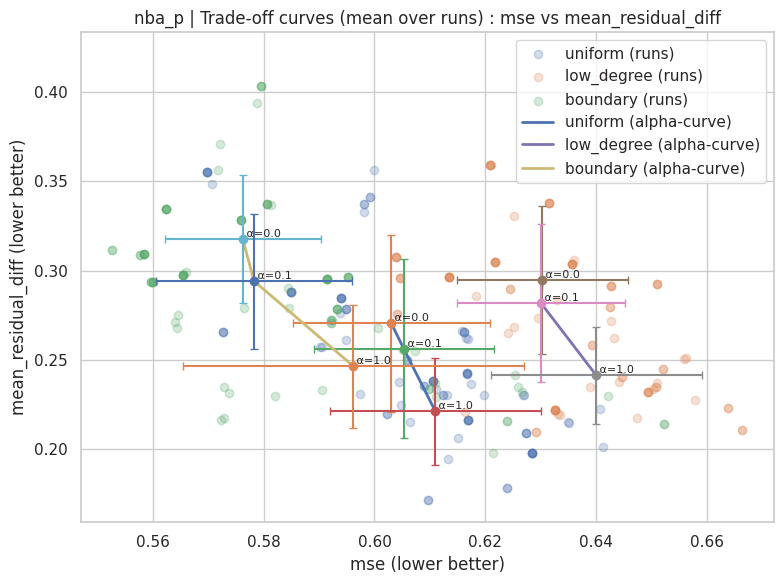

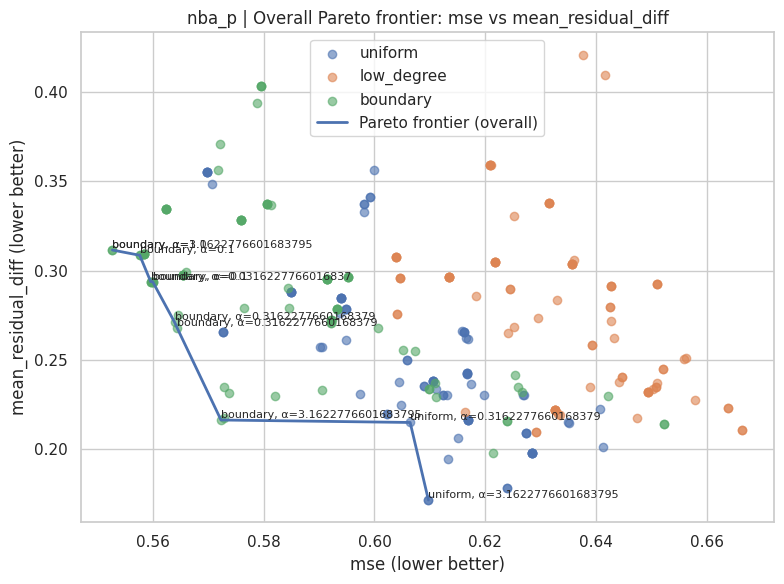

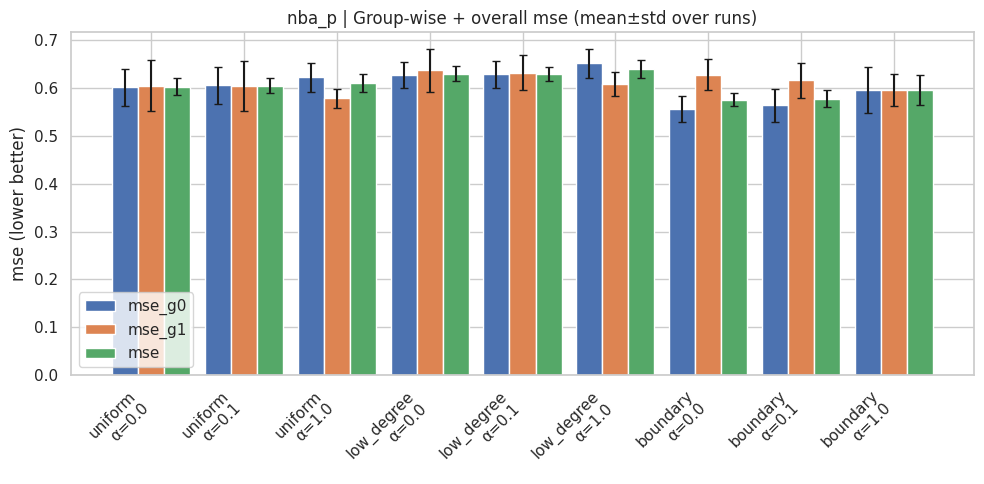

In [132]:
plot_tradeoff_curves(df, ds="nba_p", perf="mse", fair="mean_residual_diff")
plot_overall_pareto_frontier(df, ds="nba_p", perf="mse", fair="mean_residual_diff")
plot_groupwise_bars(df, ds="nba_p", metric="mse")


### 실험 3

#### QpiGNN 학습

In [58]:
def set_seed(seed=1127):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

def evaluate_model_performance(preds_low, preds_upper, targets, target=0.9):
    # PICP (Prediction Interval Coverage Probability): 커버리지 계산
    picp = np.mean((targets >= preds_low) & (targets <= preds_upper))
    
    # NMPIW (Normalized Mean Prediction Interval Width): 정규화된 구간 너비
    interval_width = np.mean(preds_upper - preds_low)
    data_range = np.max(targets) - np.min(targets)
    nmpiw = interval_width / data_range if data_range > 0 else interval_width  # 범위가 0일 경우 대비
    
    # MPE (Mean Prediction Error): 중앙값과 실제 값의 평균 오차
    median_pred = (preds_low + preds_upper) / 2    # 신뢰구간 중앙값
    mpe = np.mean(np.abs(median_pred - targets)) # 예측 구간 중심이 실제값과 얼마나 가까운지
    
    # Sharpness: 예측 구간의 날카로움 (제곱을 사용해 큰 폭에 패널티)
    sharpness = np.mean(np.square(preds_upper - preds_low)) # 예측 구간의 날카로움: 제곱을 사용해 큰 폭일수록 더 강한 패널티
    
    # 5. Winkler Score: 구간 너비 + 커버리지 실패 시 패널티
    alpha = 0.5  # 패널티 가중치
    penalties = np.where(targets < preds_low, preds_low - targets, 
                         np.where(targets > preds_upper, targets - preds_upper, 0))
    winkler = np.mean(interval_width + 2 * alpha * penalties)
    
    # Winkler Score (아래로 수정해야함,,)
    # penalties = np.where(targets < preds_low, preds_low - targets,
    #                     np.where(targets > preds_upper, targets - preds_upper, 0))
    # winkler = np.mean(interval_width + (2 / alpha) * penalties)
    
    # MCT (Modified Coverage Tradeoff): 구간 너비와 커버리지 차이의 곱
    mct = interval_width * abs(picp - target)
    
    # CWC (Coverage Width-based Criterion): NMPIW와 커버리지 패널티 결합
    mu = target  # 목표 커버리지를 target으로 설정
    # gamma (float): CWC의 패널티 강도 하이퍼파라미터 (기본값: 1.0)
    # eta (float): CWC의 지수 함수 감쇠 속도 하이퍼파라미터 (기본값: 10.0)
    gamma = 1
    eta = 10
    penalty = 1 + gamma * np.exp(-eta * (picp - mu))
    cwc = nmpiw * penalty
    
    print(f"종합 - CWC ⬇: {cwc:.4f}, MCT ⬇: {mct:.4f}")
    print(f"예측 관련 - PICP ⬆: {picp:.4f}, MPE ⬇: {mpe:.4f}")
    print(f"구간 관련 - NMPIW ⬇: {nmpiw:.4f}, Sharpness ⬇: {sharpness:.4f}, WS ⬇: {winkler:.4f}")

    
    return {
        "PICP": picp,
        'MPIW': interval_width, 
        "NMPIW": nmpiw,
        "MCT": mct,
        "CWC": cwc,
        "MPE": mpe,
        "Sharpness": sharpness,
        "WS": winkler
    }

def coverage_width(y_true, y_low, y_upper):
    coverage = ((y_true >= y_low) & (y_true <= y_upper)).float().mean()
    width = (y_upper - y_low).float().abs().mean()
    
    return coverage, width

In [59]:
import os, time
import numpy as np
import torch
import torch.optim as optim

from torch_geometric.transforms import RandomNodeSplit
from torch_geometric.utils import degree

# -----------------------------
# (A) idx split이 없을 때 자동 생성 (FnRGNN 스타일)
# -----------------------------
def ensure_splits(data, val_ratio=0.1, test_ratio=0.2):
    """
    data.idx_train/idx_val/idx_test 없으면 RandomNodeSplit로 생성.
    이미 있으면 그대로 둠.
    """
    if hasattr(data, "idx_train") and hasattr(data, "idx_val") and hasattr(data, "idx_test"):
        return data

    transform = RandomNodeSplit(num_val=val_ratio, num_test=test_ratio)
    data = transform(data)

    # RandomNodeSplit은 mask를 만들기도 해서 통일해줌
    if hasattr(data, "train_mask"):
        data.idx_train = data.train_mask.nonzero(as_tuple=False).view(-1)
        data.idx_val   = data.val_mask.nonzero(as_tuple=False).view(-1)
        data.idx_test  = data.test_mask.nonzero(as_tuple=False).view(-1)

    return data


# -----------------------------
# (B) train 기준 min-max normalize (FnRGNN data에서도 안전)
# -----------------------------
def minmax_normalize_train_based(data, eps=1e-12):
    idx_train = data.idx_train
    x = data.x
    y = data.y

    x_min = x[idx_train].min()
    x_max = x[idx_train].max()
    y_min = y[idx_train].min()
    y_max = y[idx_train].max()

    data.x = (x - x_min) / (x_max - x_min + eps)
    data.y = (y - y_min) / (y_max - y_min + eps)

    # 저장해두면 나중에 inverse transform에도 쓸 수 있음
    data._norm = {
        "x_min": x_min.detach().cpu(),
        "x_max": x_max.detach().cpu(),
        "y_min": y_min.detach().cpu(),
        "y_max": y_max.detach().cpu(),
    }
    return data


# -----------------------------
# (C) QpiGNN 단일 run 학습 + best 저장 (val 기준)
# -----------------------------
@torch.no_grad()
def eval_gqnn_split(model, data, idx, target_coverage=0.9):
    """
    너의 evaluate_model_performance 형식과 맞추는 평가.
    """
    model.eval()
    low, up = model(data.x, data.edge_index)
    low = low[idx].detach().cpu().numpy()
    up  = up[idx].detach().cpu().numpy()
    yt  = data.y[idx].detach().cpu().numpy()
    m = evaluate_model_performance(low, up, yt, target=target_coverage)
    return m


def train_gqnn_on_fnr_data(
    data,
    dn: str,
    device,
    runs=10,
    epochs=500,
    hidden_dim=64,
    lr=1e-3,
    weight_decay=1e-5,
    target_coverage=0.9,
    lambda_factor=0.1,
    ckpt_dir="./GQNN_ckpt_fnr",
    log_every=50,
    normalize_train=True,
    val_score_key="coverage_width_tradeoff",
):
    """
    FnRGNN 데이터(data)에 QpiGNN(GQNN) 학습 적용.
    - split은 data.idx_train/val/test 사용(없으면 생성)
    - normalize는 train 기준 min-max (옵션)
    - best는 val 기준으로 저장
    - 각 run의 train/val/test metrics를 dict로 반환
    """
    os.makedirs(ckpt_dir, exist_ok=True)

    # dtype 정리
    data = data.to(device)
    data.x = data.x.float()
    data.y = data.y.float()
    data.sensitive_attr = data.sensitive_attr.long()

    # split 없으면 생성
    data = ensure_splits(data, val_ratio=0.1, test_ratio=0.2)

    # normalize (train 기준)
    if normalize_train:
        data = minmax_normalize_train_based(data)

    idx_train = data.idx_train
    idx_val = data.idx_val
    idx_test = data.idx_test

    in_dim = data.x.size(1)

    results = []

    for run in range(runs):
        seed = 1127 + run
        set_seed(seed)

        model = GQNN(in_dim=in_dim, hidden_dim=hidden_dim).to(device)
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
        criterion = GQNNLoss(target_coverage=target_coverage, lambda_factor=lambda_factor)

        best_score = float("inf")
        best_path = os.path.join(ckpt_dir, f"{dn}_run{run}.pth")

        start = time.time()

        for epoch in range(epochs):
            model.train()
            optimizer.zero_grad()

            low, up = model(data.x, data.edge_index)

            # train subset만 loss
            loss = criterion(low[idx_train], up[idx_train], data.y[idx_train])
            loss.backward()
            optimizer.step()

            # val 평가
            with torch.no_grad():
                low_v, up_v = model(data.x, data.edge_index)
                # coverage_width는 네 util 함수 사용
                cvg_val, wdt_val = coverage_width(data.y[idx_val], low_v[idx_val], up_v[idx_val])

                # val score: "커버리지 목표 미달 + 폭" 중심 (낮을수록 좋음)
                # (eval 함수의 반환 형태를 몰라서, 여기선 직접 구성)
                cov_miss = max(0.0, target_coverage - float(cvg_val))
                val_score = (cov_miss ** 2) + float(wdt_val)  # 가장 단순하고 안정적

            if val_score < best_score:
                best_score = val_score
                torch.save(model.state_dict(), best_path)

            if epoch % log_every == 0:
                print(
                    f"[{dn} | GQNN | run {run} | ep {epoch}] "
                    f"loss {loss.item():.4f} | val cov {float(cvg_val):.3f} | val width {float(wdt_val):.4f} | "
                    f"val_score {val_score:.4f}"
                )

        train_time = time.time() - start

        # best 로드 후 최종 평가
        model.load_state_dict(torch.load(best_path, map_location=device, weights_only=True))
        model.eval()

        train_metrics = eval_gqnn_split(model, data, idx_train, target_coverage)
        val_metrics   = eval_gqnn_split(model, data, idx_val, target_coverage)
        test_metrics  = eval_gqnn_split(model, data, idx_test, target_coverage)

        results.append({
            "ds": dn,
            "run": run,
            "seed": seed,
            "best_path": best_path,
            "train_time_sec": round(train_time, 2),
            "best_val_score": float(best_score),
            "train_metrics": train_metrics,
            "val_metrics": val_metrics,
            "test_metrics": test_metrics,
        })

        print(
            f"[{dn} | GQNN | run {run}] DONE | time {train_time:.1f}s | "
            f"best_val_score {best_score:.4f}"
        )

    return results, data


In [61]:
ds = 'nba_p'
data = dt_dict[ds]['data']
cfg = dt_dict[ds]['cfg']
dn = cfg['dn']

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

results, data_norm = train_gqnn_on_fnr_data(
    data=data,
    dn=dn,
    device=device,
    runs=10,
    epochs=500,
    hidden_dim=64,
    lr=1e-3,
    weight_decay=1e-5,
    target_coverage=0.9,
    lambda_factor=0.5,
    ckpt_dir="./GQNN_ckpt_fnr",
    log_every=50,
    normalize_train=True,
)


[NBA(PIE)_Country | GQNN | run 0 | ep 0] loss 0.6733 | val cov 0.859 | val width 1.0696 | val_score 1.0713
[NBA(PIE)_Country | GQNN | run 0 | ep 50] loss 0.5257 | val cov 1.000 | val width 1.0243 | val_score 1.0243
[NBA(PIE)_Country | GQNN | run 0 | ep 100] loss 0.5199 | val cov 1.000 | val width 1.0087 | val_score 1.0087
[NBA(PIE)_Country | GQNN | run 0 | ep 150] loss 0.5166 | val cov 1.000 | val width 1.0118 | val_score 1.0118
[NBA(PIE)_Country | GQNN | run 0 | ep 200] loss 0.5199 | val cov 1.000 | val width 1.0140 | val_score 1.0140
[NBA(PIE)_Country | GQNN | run 0 | ep 250] loss 0.5154 | val cov 1.000 | val width 1.0037 | val_score 1.0037
[NBA(PIE)_Country | GQNN | run 0 | ep 300] loss 0.5133 | val cov 1.000 | val width 1.0045 | val_score 1.0045
[NBA(PIE)_Country | GQNN | run 0 | ep 350] loss 0.5178 | val cov 1.000 | val width 1.0136 | val_score 1.0136
[NBA(PIE)_Country | GQNN | run 0 | ep 400] loss 0.5136 | val cov 1.000 | val width 1.0076 | val_score 1.0076
[NBA(PIE)_Country | GQ

#### EDA

In [134]:
import os
import numpy as np
import pandas as pd
import torch
from torch_geometric.utils import degree

ds = 'nba_p'
data = dt_dict[ds]['data']
cfg = dt_dict[ds]['cfg']
dn = cfg['dn']

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

# dtype 정리
data = data.to(device)
data.x = data.x.float()
data.y = data.y.float()
data.sensitive_attr = data.sensitive_attr.long()

print("dn:", dn, "| N:", data.num_nodes, "| E:", data.edge_index.size(1), "| device:", device)


dn: NBA(PIE)_Country | N: 403 | E: 21645 | device: cuda:0


In [135]:
ckpt_dir = "./GQNN_ckpt_fnr"     # 네가 학습할 때 저장한 폴더
run = 9                         # 보고 싶은 run 번호
hidden_dim = 64                 # 학습 때와 동일

ckpt_path = os.path.join(ckpt_dir, f"{dn}_run{run}.pth")
print("ckpt_path:", ckpt_path)

model = GQNN(in_dim=data.x.size(1), hidden_dim=hidden_dim).to(device)
state = torch.load(ckpt_path, map_location=device, weights_only=True)
model.load_state_dict(state)
model.eval()
print("Loaded OK")

ckpt_path: ./GQNN_ckpt_fnr/NBA(PIE)_Country_run9.pth
Loaded OK


In [136]:
@torch.no_grad()
def qpignn_node_metrics(model, data, eps=1e-12):
    low, up = model(data.x, data.edge_index)
    low = low.squeeze(-1)
    up  = up.squeeze(-1)
    y   = data.y.squeeze(-1)

    width = up - low
    violation = torch.relu(low - y) + torch.relu(y - up)
    covered = ((low <= y) & (y <= up)).float()
    hardness = violation / (width.abs() + eps)

    return low, up, width, violation, hardness, covered

low, up, width, violation, hardness, covered = qpignn_node_metrics(model, data)

print("coverage:", covered.mean().item())
print("width mean/std:", width.mean().item(), width.std().item())
print("violation rate:", (violation > 0).float().mean().item())

coverage: 0.3622828722000122
width mean/std: 1.0025839805603027 0.015717269852757454
violation rate: 0.6377171277999878


In [137]:
@torch.no_grad()
def graph_node_metrics(data):
    edge_index = data.edge_index
    src, dst = edge_index[0], edge_index[1]
    N = data.num_nodes

    # degree (src 기준: out-degree)
    deg = degree(src, num_nodes=N)

    # boundary_score: 다른 민감집단 이웃 "개수"
    sens = data.sensitive_attr
    nei_diff = (sens[src] != sens[dst]).float()

    boundary_score = torch.zeros(N, device=data.x.device)
    boundary_score.index_add_(0, src, nei_diff)

    # 해석용 정규화 boundary (학습 규칙은 count를 썼더라도 EDA에서는 꼭 같이 봄)
    boundary_rate = boundary_score / torch.clamp(deg, min=1)

    return deg, boundary_score, boundary_rate

deg, boundary_score, boundary_rate = graph_node_metrics(data)

print("deg mean/std:", deg.mean().item(), deg.std().item())
print("boundary_score mean/std:", boundary_score.mean().item(), boundary_score.std().item())
print("boundary_rate mean/std:", boundary_rate.mean().item(), boundary_rate.std().item())

deg mean/std: 53.709678649902344 35.143310546875
boundary_score mean/std: 14.565756797790527 15.781074523925781
boundary_rate mean/std: 0.274370014667511 0.19021698832511902


In [138]:
df = pd.DataFrame({
    "node_id": np.arange(data.num_nodes),
    "y": data.y.squeeze(-1).detach().cpu().numpy(),
    "group": data.sensitive_attr.detach().cpu().numpy(),

    "pred_low": low.detach().cpu().numpy(),
    "pred_up": up.detach().cpu().numpy(),

    "width": width.detach().cpu().numpy(),
    "violation": violation.detach().cpu().numpy(),
    "hardness": hardness.detach().cpu().numpy(),
    "covered": covered.detach().cpu().numpy(),

    "deg": deg.detach().cpu().numpy(),
    "boundary_score": boundary_score.detach().cpu().numpy(),
    "boundary_rate": boundary_rate.detach().cpu().numpy(),
})

df.head()

,node_id,y,group,pred_low,pred_up,width,violation,hardness,covered,deg,boundary_score,boundary_rate
0,0,0.135191,0,-0.117164,0.890105,1.007269,0.000000,0.000000,1.0,38.0,6.0,0.157895
1,1,-0.682039,0,-0.071205,0.917800,0.989005,0.610834,0.617625,0.0,59.0,7.0,0.118644
2,2,-1.226858,1,-0.185164,0.798375,0.983539,1.041694,1.059128,0.0,33.0,14.0,0.424242
3,3,0.135191,1,0.025495,1.032869,1.007374,0.000000,0.000000,1.0,24.0,8.0,0.333333
4,4,2.859290,1,-0.113430,0.876803,0.990233,1.982487,2.002040,0.0,33.0,16.0,0.484848


In [139]:
df[["width", "violation", "hardness", "covered", "deg", "boundary_score", "boundary_rate"]].describe()

,width,violation,hardness,covered,deg,boundary_score,boundary_rate
count,403.000000,403.000000,403.000000,403.000000,403.000000,403.000000,403.000000
mean,1.002584,0.422381,0.422836,0.362283,53.709679,14.565757,0.274370
std,0.015717,0.585795,0.588847,0.481257,35.143311,15.781074,0.190217
min,0.937374,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,0.992838,0.000000,0.000000,0.000000,29.000000,6.000000,0.149627
50%,1.003571,0.232620,0.232845,0.000000,48.000000,10.000000,0.200000
75%,1.011851,0.632583,0.633233,1.000000,70.000000,17.000000,0.351471
max,1.047394,3.856177,3.916879,1.000000,221.000000,126.000000,0.833333


In [140]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

def plot_hist_kde(df, col, bins=50, logy=False):
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], bins=bins, kde=True)
    plt.title(f"{col} distribution")
    if logy:
        plt.yscale("log")
    plt.show()

def plot_ecdf(df, col, hue=None, logx=False):
    plt.figure(figsize=(6,4))
    sns.ecdfplot(data=df, x=col, hue=hue)
    if logx:
        plt.xscale("log")
    plt.title(f"ECDF of {col}")
    plt.show()


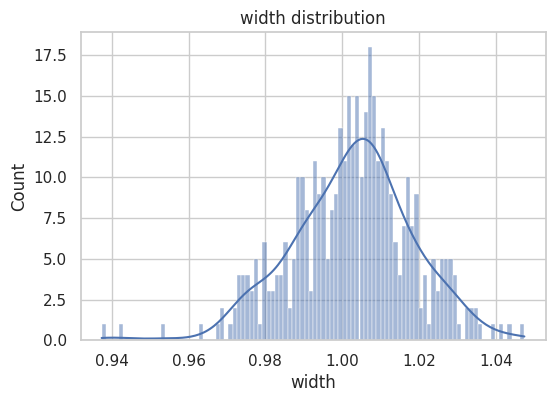

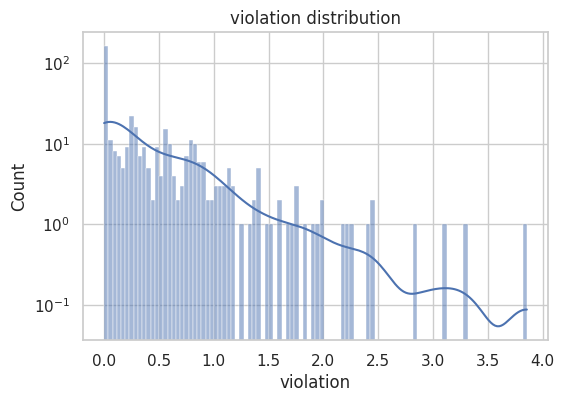

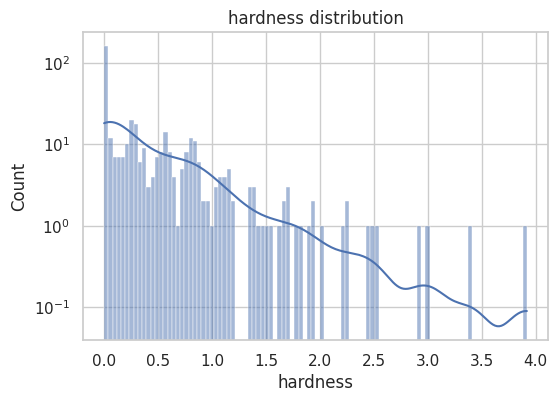

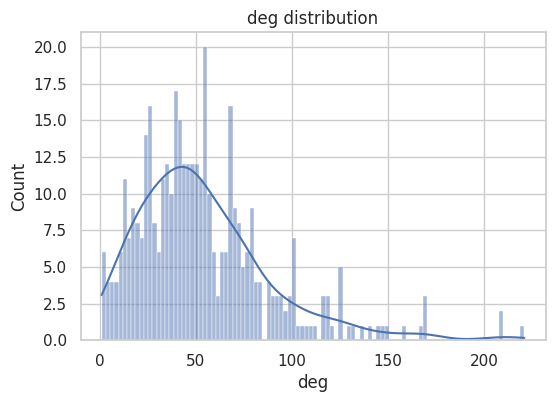

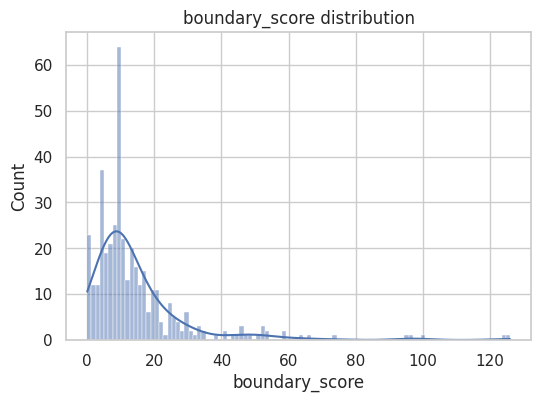

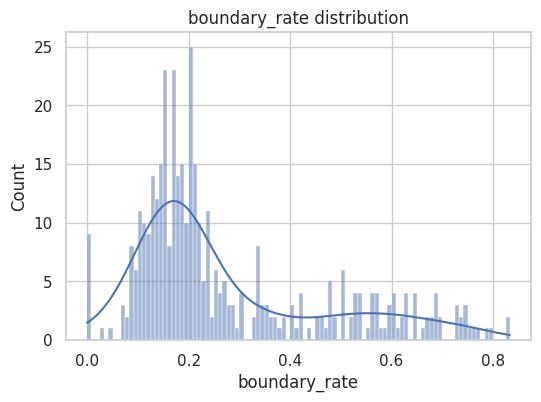

In [145]:
plot_hist_kde(df, "width", bins=100, logy=False)
plot_hist_kde(df, "violation", bins=100, logy=True)  # violation은 보통 heavy-tail
plot_hist_kde(df, "hardness", bins=100, logy=True)
plot_hist_kde(df, "deg", bins=100, logy=False)
plot_hist_kde(df, "boundary_score", bins=100, logy=False)
plot_hist_kde(df, "boundary_rate", bins=100, logy=False)

# plot_ecdf(df, "width")
# plot_ecdf(df, "violation", logx=True)
# plot_ecdf(df, "hardness", logx=True)

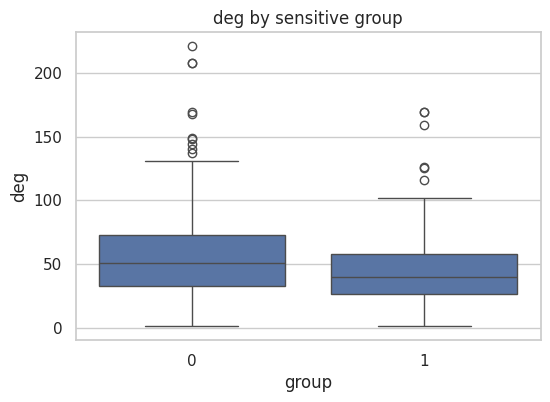

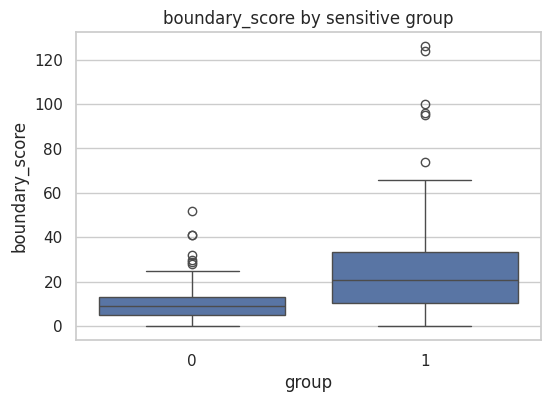

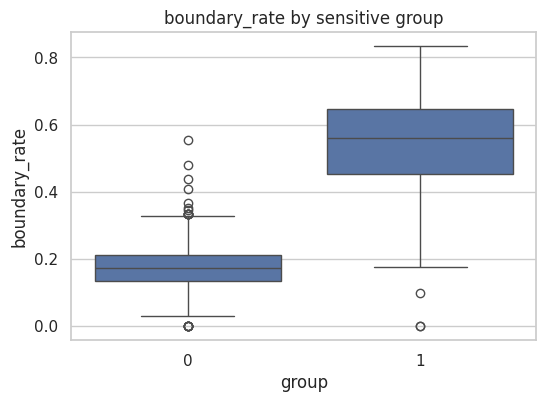

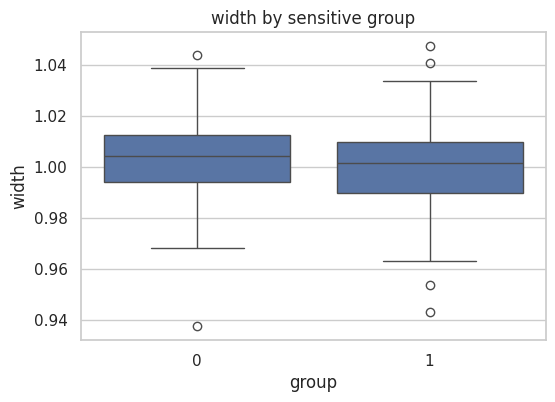

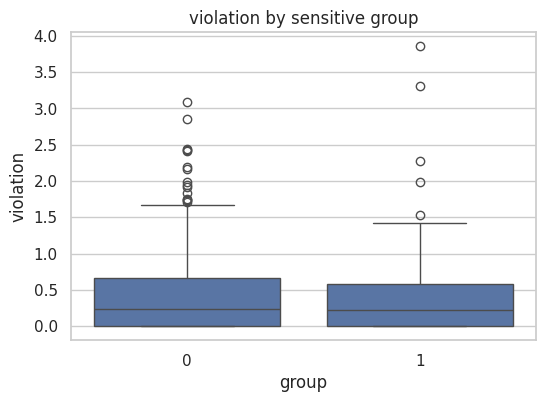

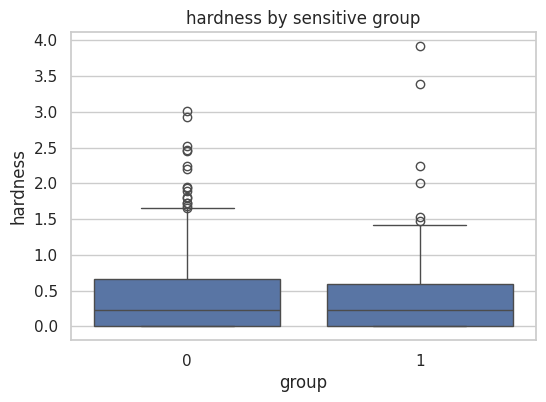

In [147]:
def plot_by_group(df, col, kind="box"):
    plt.figure(figsize=(6,4))
    if kind == "box":
        sns.boxplot(data=df, x="group", y=col)
    else:
        sns.violinplot(data=df, x="group", y=col, cut=0)
    plt.title(f"{col} by sensitive group")
    plt.show()


plots = ["deg", "boundary_score", "boundary_rate", "width", "violation", "hardness"]

for i in plots:
    plot_by_group(df, i, kind="box")


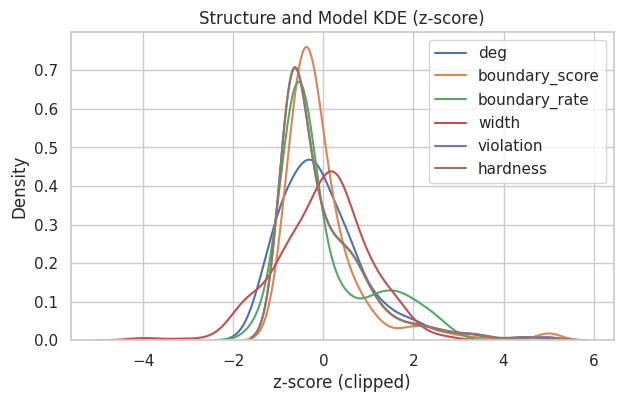

In [149]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_kde_overlay_zscore(df, cols, clip=5.0, title="KDE (z-scored)"):
    """
    cols: 겹쳐서 볼 컬럼 리스트
    clip: extreme outlier 잘라서 KDE 안정화 (±clip)
    """
    tmp = df[cols].copy()

    # z-score
    for c in cols:
        x = tmp[c].astype(float)
        z = (x - x.mean()) / (x.std() + 1e-12)
        tmp[c] = z.clip(-clip, clip)

    plt.figure(figsize=(7,4))
    for c in cols:
        sns.kdeplot(tmp[c], label=c, fill=False, common_norm=False)
    plt.title(title)
    plt.xlabel("z-score (clipped)")
    plt.legend()
    plt.show()

# cols = ["deg", "boundary_score", "violation", "width"]  # 또는 width/hardness로 교체
plot_kde_overlay_zscore(df, plots, clip=5.0, title="Structure and Model KDE (z-score)")


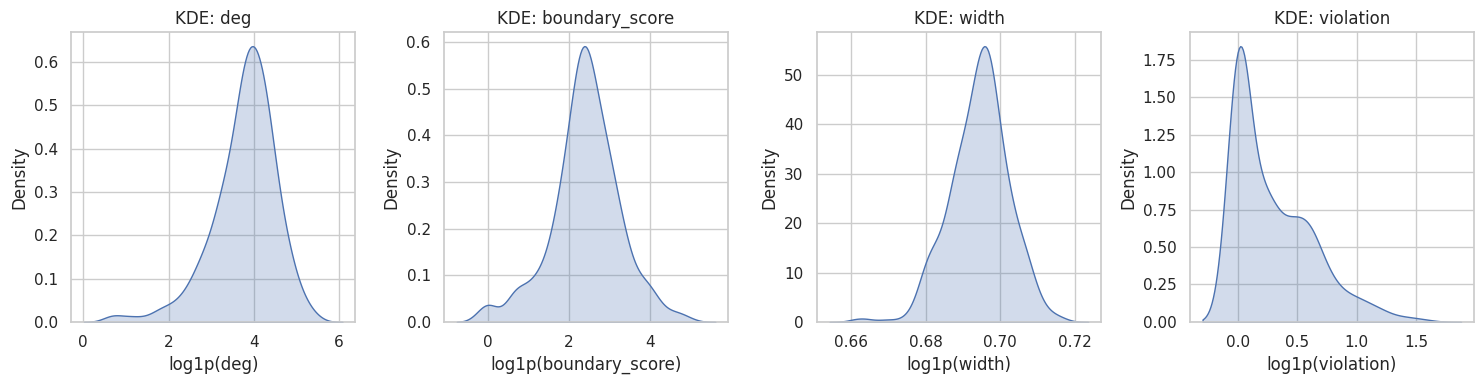

In [150]:
def plot_kde_three(df, a="deg", b="boundary_score", c="violation", d= "width", log1p=True):
    cols = [a,b,c,d]
    fig, axs = plt.subplots(1, 4, figsize=(15,4))

    for ax, col in zip(axs, cols):
        x = df[col].astype(float)
        if log1p:
            x = np.log1p(x)
            xlabel = f"log1p({col})"
        else:
            xlabel = col
        sns.kdeplot(x=x, ax=ax, fill=True)
        ax.set_title(f"KDE: {col}")
        ax.set_xlabel(xlabel)

    plt.tight_layout()
    plt.show()

plot_kde_three(df, "deg", "boundary_score", "width", "violation", log1p=True)


In [78]:
df[["width","violation","hardness"]].quantile([0, .1, .25, .5, .75, .9, .95, .99, 1.0])

,width,violation,hardness
0.00,0.937374,0.000000,0.000000
0.10,0.981803,0.000000,0.000000
0.25,0.992838,0.000000,0.000000
0.50,1.003571,0.232620,0.232845
0.75,1.011851,0.632583,0.633233
0.90,1.021948,1.120231,1.123954
0.95,1.027778,1.614482,1.651737
0.99,1.035819,2.444180,2.515648
1.00,1.047394,3.856177,3.916879


In [152]:
cols = ["width","violation","hardness","deg","boundary_score","boundary_rate"]
corr = df[cols].corr(method="spearman")
corr


,width,violation,hardness,deg,boundary_score,boundary_rate
width,1.000000,-0.138690,-0.147856,0.233591,0.168963,-0.034321
violation,-0.138690,1.000000,0.999863,-0.028391,-0.040186,-0.036289
hardness,-0.147856,0.999863,1.000000,-0.031667,-0.042175,-0.035937
deg,0.233591,-0.028391,-0.031667,1.000000,0.668537,-0.092210
boundary_score,0.168963,-0.040186,-0.042175,0.668537,1.000000,0.598383
boundary_rate,-0.034321,-0.036289,-0.035937,-0.092210,0.598383,1.000000


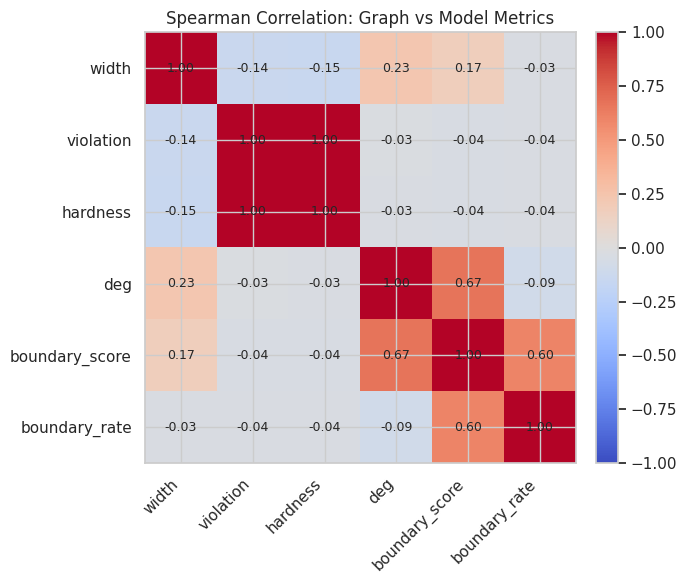

In [156]:
import matplotlib.pyplot as plt
import numpy as np

cols = ["width","violation","hardness",
        "deg","boundary_score","boundary_rate"]

corr = df[cols].corr(method="spearman")

plt.figure(figsize=(7, 6))
im = plt.imshow(corr.values, vmin=-1, vmax=1, cmap="coolwarm")


plt.colorbar(im, fraction=0.046, pad=0.04)

plt.xticks(range(len(cols)), cols, rotation=45, ha="right")
plt.yticks(range(len(cols)), cols)

# 값 표시 (선택)
for i in range(len(cols)):
    for j in range(len(cols)):
        plt.text(
            j, i,
            f"{corr.values[i, j]:.2f}",
            ha="center", va="center",
            fontsize=9
        )

plt.title("Spearman Correlation: Graph vs Model Metrics")
plt.tight_layout()
plt.show()


In [80]:
corr["width"].sort_values(ascending=False)

width             1.000000
deg               0.233591
boundary_score    0.168963
boundary_rate    -0.034321
violation        -0.138690
hardness         -0.147856
Name: width, dtype: float64

In [84]:
# gating 관점 overlap (top 30% 기준)
def top30_mask(s):
    thr = s.quantile(0.7)
    return s >= thr

D = top30_mask(df["deg"])
B = top30_mask(df["boundary_score"])
W = top30_mask(df["width"])
V = top30_mask(df["violation"])
H = top30_mask(df["hardness"])

def jaccard(a, b):
    return (a & b).sum() / (a | b).sum()

print("Jaccard(degree, width)   :", jaccard(D, W))
print("Jaccard(boundary, width)   :", jaccard(B, W))
print("Jaccard(boundary, degree)   :", jaccard(B, D))
print("Jaccard(boundary, violation):", jaccard(B, V))
print("Jaccard(boundary, hardness) :", jaccard(B, H))


Jaccard(degree, width)   : 0.19607843137254902
Jaccard(boundary, width)   : 0.24752475247524752
Jaccard(boundary, degree)   : 0.41899441340782123
Jaccard(boundary, violation): 0.1943127962085308
Jaccard(boundary, hardness) : 0.18867924528301888


In [85]:
df["top30_width"] = W.astype(int)
df["top30_violation"] = V.astype(int)
df["top30_hardness"] = H.astype(int)
df["top30_boundary"] = B.astype(int)

df.groupby("group")[["top30_width","top30_violation","top30_hardness","top30_boundary"]].mean()


,top30_width,top30_violation,top30_hardness,top30_boundary
group,,,,
0,0.317568,0.304054,0.304054,0.202703
1,0.252336,0.289720,0.289720,0.663551


In [86]:
df.groupby("group")[["width","violation","hardness","deg","boundary_rate","covered"]].mean()

,width,violation,hardness,deg,boundary_rate,covered
group,,,,,,
0,1.003392,0.421571,0.421671,56.320946,0.179260,0.344595
1,1.000349,0.424620,0.426061,46.485981,0.537479,0.411215


### 실험 4

In [ ]:
# base 모델(제약 없음)과 fair 모델(제약 있음)을 학습
# 노드별로 Δerr_i = err_i(fair) - err_i(base) 계산
# Δerr_i와 width/violation/hardness의 상관/단조관계 보여주기

In [184]:
import os
import time
import numpy as np
import pandas as pd
import torch

from sklearn.metrics import mean_squared_error, mean_absolute_error

# -----------------------------
# 유틸: 안전한 fairness penalty
# (너가 이미 가지고 있으면 이거 빼고 기존 함수 쓰면 됨)
# -----------------------------
def safe_fairness_penalty(m, fair_key="mean_residual_gap", missing="zero"):
    """
    m: fair_metric_regression_v2 output dict
    fair_key: "mean_residual_gap" or "mse_gap" ... (네 코드에 맞춤)
    """
    try:
        if fair_key == "mean_residual_gap":
            v = m["disparity"]["mean_residual"]["abs_diff"]
        elif fair_key == "mse_gap":
            v = m["disparity"]["mse"]["abs_diff"]
        elif fair_key == "mae_gap":
            v = m["disparity"]["mae"]["abs_diff"]
        else:
            v = 0.0
        if v is None or (isinstance(v, float) and (not np.isfinite(v))):
            return 0.0 if missing == "zero" else np.nan
        return float(v)
    except Exception:
        return 0.0 if missing == "zero" else np.nan

# -----------------------------
# 핵심: best 모델 pred 저장 함수
# -----------------------------
@torch.no_grad()
def save_node_predictions_npz(model, data, out_path):
    """
    전체 노드 pred, y, sens, split idx를 저장.
    """
    model.eval()
    pred, _ = model(data)          # pred shape (N,1)
    pred = pred.view(-1).detach().cpu().numpy()

    y = data.y.view(-1).detach().cpu().numpy()
    sens = data.sensitive_attr.view(-1).detach().cpu().numpy()

    np.savez_compressed(
        out_path,
        pred=pred,
        y=y,
        sens=sens,
        idx_train=data.idx_train.detach().cpu().numpy(),
        idx_val=data.idx_val.detach().cpu().numpy(),
        idx_test=data.idx_test.detach().cpu().numpy(),
    )

# -----------------------------
# 메인: FnRGNN 실험 루프 (base/fair 모두 가능)
# -----------------------------
def run_fnrgnn_with_pred_saving(
    data,
    dn: str,
    ds: str,
    device,
    runs=10,
    epochs=500,
    lr=1e-3,
    weight_decay=1e-5,
    hidden_dim=64,
    dropout=0.5,
    mmd_sample=500,
    modes=("uniform", "low_degree", "boundary"),
    # fairness strength grid: (lm, ld)
    fairness_grid=((0.0, 0.0), (3.0, 1.0)),
    # val score: mse + alpha * fairness_gap  (alpha는 "선택 기준"용)
    alphas=(0.0, 0.1, 0.3, 0.5, 1.0, 2.0),
    save_dir="./FnRGNN",
    log_every=50,
):
    os.makedirs(save_dir, exist_ok=True)
    ckpt_dir = os.path.join(save_dir, "ckpt")
    pred_dir = os.path.join(save_dir, "preds")
    os.makedirs(ckpt_dir, exist_ok=True)
    os.makedirs(pred_dir, exist_ok=True)

    # dtype/device
    data = data.to(device)
    data.x = data.x.float()
    data.y = data.y.float()
    data.sensitive_attr = data.sensitive_attr.long()

    results_all = []

    for mode in modes:
        for (lm, ld) in fairness_grid:
            for alpha in alphas:
                print(f"\n===== START | ds={ds} | mode={mode} | (lm,ld)=({lm},{ld}) | alpha={alpha} =====")

                for run in range(runs):
                    seed = 1127 + run
                    np.random.seed(seed)
                    torch.manual_seed(seed)
                    if torch.cuda.is_available():
                        torch.cuda.manual_seed_all(seed)

                    model = FnRGNN(
                        nfeat=data.x.size(1),
                        hidden_dim=hidden_dim,
                        dropout=dropout,
                        lm=lm,                 # ✅ fairness strength
                        ld=ld,                 # ✅ fairness strength
                        mmd_sample=mmd_sample,
                        lr=lr,
                        weight_decay=weight_decay,
                        fairness_mode=mode     # ✅ which nodes get fairness loss
                    ).to(device)

                    best_score = float("inf")

                    best_path = os.path.join(
                        ckpt_dir, f"{dn}_ds{ds}_mode{mode}_lm{lm}_ld{ld}_a{alpha}_run{run}.pth"
                    )
                    best_pred_path = os.path.join(
                        pred_dir, f"{dn}_ds{ds}_mode{mode}_lm{lm}_ld{ld}_a{alpha}_run{run}.npz"
                    )

                    for epoch in range(epochs):
                        loss = model.optimize(data)

                        # validation
                        model.eval()
                        with torch.no_grad():
                            pred, _ = model(data)
                            pred = pred.view(-1)
                            y_true = data.y.view(-1)

                            idx_val = data.idx_val
                            sens_val = data.sensitive_attr

                            mse_val = mean_squared_error(
                                y_true[idx_val].detach().cpu().numpy(),
                                pred[idx_val].detach().cpu().numpy()
                            )
                            mae_val = mean_absolute_error(
                                y_true[idx_val].detach().cpu().numpy(),
                                pred[idx_val].detach().cpu().numpy()
                            )

                            m_val = fair_metric_regression_v2(
                                pred[idx_val], y_true[idx_val], sens_val[idx_val],
                                group_values=(0, 1)
                            )

                            mean_resid_gap = safe_fairness_penalty(
                                m_val, fair_key="mean_residual_gap", missing="zero"
                            )

                            # robust
                            worst_group_mse = m_val["fairness_aggregates"]["worst_group_mse"]
                            if not np.isfinite(worst_group_mse):
                                worst_group_mse = mse_val

                            # ✅ best 선택: mse + alpha * fairness
                            val_score = mse_val + alpha * mean_resid_gap

                            if val_score < best_score:
                                best_score = val_score
                                torch.save(model.state_dict(), best_path)

                        if epoch % log_every == 0:
                            g0n = m_val["group"]["0"]["n"]
                            g1n = m_val["group"]["1"]["n"]
                            print(
                                f"[{ds} | {mode} | (lm,ld)=({lm},{ld}) | a={alpha} | run {run} | ep {epoch}] "
                                f"loss {loss:.4f} | val mse {mse_val:.4f} mae {mae_val:.4f} | "
                                f"mean_resid_gap {mean_resid_gap:.4f} | worst_g_mse {worst_group_mse:.4f} | "
                                f"n(g0,g1)=({g0n},{g1n})"
                            )

                    # -------------------------
                    # test (best 로드)
                    # -------------------------
                    model.load_state_dict(torch.load(best_path, map_location=device))
                    model.eval()

                    with torch.no_grad():
                        pred, _ = model(data)
                        pred = pred.view(-1)
                        y_true = data.y.view(-1)
                        idx_test = data.idx_test
                        sens_test = data.sensitive_attr

                        mse_test = mean_squared_error(
                            y_true[idx_test].detach().cpu().numpy(),
                            pred[idx_test].detach().cpu().numpy()
                        )
                        mae_test = mean_absolute_error(
                            y_true[idx_test].detach().cpu().numpy(),
                            pred[idx_test].detach().cpu().numpy()
                        )

                        m_test = fair_metric_regression_v2(
                            pred[idx_test], y_true[idx_test], sens_test[idx_test],
                            group_values=(0, 1)
                        )

                    # ✅ best 모델 pred 저장 (전체 노드)
                    save_node_predictions_npz(model, data, best_pred_path)

                    g0 = m_test["group"]["0"]
                    g1 = m_test["group"]["1"]
                    disp = m_test["disparity"]
                    agg = m_test["fairness_aggregates"]

                    results_all.append({
                        "ds": ds,
                        "mode": mode,
                        "lm": float(lm),
                        "ld": float(ld),
                        "alpha": float(alpha),
                        "run": run,

                        # overall
                        "mse": mse_test,
                        "mae": mae_test,

                        # group-wise
                        "n_g0": g0["n"],
                        "n_g1": g1["n"],
                        "mse_g0": g0["mse"],
                        "mse_g1": g1["mse"],
                        "mae_g0": g0["mae"],
                        "mae_g1": g1["mae"],
                        "mean_residual_g0": g0["mean_residual"],
                        "mean_residual_g1": g1["mean_residual"],

                        # gaps (abs)
                        "mse_diff": disp["mse"]["abs_diff"],
                        "mae_diff": disp["mae"]["abs_diff"],
                        "mean_residual_diff": disp["mean_residual"]["abs_diff"],

                        # signed (g1 - g0)
                        "mse_signed_g1_minus_g0": disp["mse"]["signed_diff_g1_minus_g0"],
                        "mae_signed_g1_minus_g0": disp["mae"]["signed_diff_g1_minus_g0"],
                        "mean_residual_signed_g1_minus_g0": disp["mean_residual"]["signed_diff_g1_minus_g0"],

                        # robust
                        "worst_group_mse": agg["worst_group_mse"],
                        "worst_group_mae": agg["worst_group_mae"],
                        "ratio_mse": agg["ratio_mse"],
                        "ratio_mae": agg["ratio_mae"],

                        # bookkeeping
                        "best_val_score": float(best_score),
                        "best_ckpt": best_path,
                        "pred_npz": best_pred_path,
                    })

                    print(f"Finished run {run}! saved pred -> {best_pred_path}")

                # 조합별 저장
                df_tmp = pd.DataFrame([
                    r for r in results_all
                    if r["mode"] == mode and r["lm"] == float(lm) and r["ld"] == float(ld) and r["alpha"] == float(alpha)
                ])
                out_csv = os.path.join(save_dir, f"results_{dn}_ds{ds}_mode{mode}_lm{lm}_ld{ld}_a{alpha}.csv")
                df_tmp.to_csv(out_csv, index=False)
                print(f"Saved: {out_csv}  (rows={len(df_tmp)})")

    # 전체 저장
    df_all = pd.DataFrame(results_all)
    out_all = os.path.join(save_dir, f"results_{dn}_ds{ds}_ALL.csv")
    df_all.to_csv(out_all, index=False)
    print(f"\nALL DONE. Saved: {out_all} (rows={len(df_all)})")

    return df_all, ckpt_dir, pred_dir


In [185]:
ds = 'nba_p'
data = dt_dict[ds]['data']
cfg = dt_dict[ds]['cfg']
dn = cfg['dn']

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print("device:", device)

df_all, ckpt_dir, pred_dir = run_fnrgnn_with_pred_saving(
    data=data,
    dn=dn,
    ds=ds,
    device=device,
    runs=10,
    epochs=500,
    lr=1e-3,
    weight_decay=1e-5,
    modes=("uniform", "low_degree", "boundary", "norm_boundary"),
    # ✅ base vs fair를 만들기 위한 grid
    fairness_grid=((0.0, 0.0), (3.0, 1.0)),   # (0,0)=base / (3,1)=fair(기존)
    alphas=(0.0, 0.1, 0.3, 0.5, 1.0, 2.0),
    save_dir="./FnRGNN",
    log_every=50,
)

device: cuda:0

===== START | ds=nba_p | mode=uniform | (lm,ld)=(0.0,0.0) | alpha=0.0 =====
[nba_p | uniform | (lm,ld)=(0.0,0.0) | a=0.0 | run 0 | ep 0] loss 0.9648 | val mse 0.9267 mae 0.7348 | mean_resid_gap 0.0998 | worst_g_mse 0.9436 | n(g0,g1)=(73,26)
[nba_p | uniform | (lm,ld)=(0.0,0.0) | a=0.0 | run 0 | ep 50] loss 0.8080 | val mse 0.7226 mae 0.6545 | mean_resid_gap 0.0954 | worst_g_mse 0.7321 | n(g0,g1)=(73,26)
[nba_p | uniform | (lm,ld)=(0.0,0.0) | a=0.0 | run 0 | ep 100] loss 0.6386 | val mse 0.6630 mae 0.6174 | mean_resid_gap 0.1321 | worst_g_mse 0.7735 | n(g0,g1)=(73,26)
[nba_p | uniform | (lm,ld)=(0.0,0.0) | a=0.0 | run 0 | ep 150] loss 0.5119 | val mse 0.9270 mae 0.6572 | mean_resid_gap 0.3123 | worst_g_mse 1.7287 | n(g0,g1)=(73,26)
[nba_p | uniform | (lm,ld)=(0.0,0.0) | a=0.0 | run 0 | ep 200] loss 0.4677 | val mse 1.5321 mae 0.7207 | mean_resid_gap 0.5241 | worst_g_mse 3.6674 | n(g0,g1)=(73,26)
[nba_p | uniform | (lm,ld)=(0.0,0.0) | a=0.0 | run 0 | ep 250] loss 0.4352 |

/tmp/ipykernel_288109/3131204030.py:184: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_path, map_location=device))


Finished run 0! saved pred -> ./FnRGNN/preds/NBA(PIE)_Country_dsnba_p_modeuniform_lm0.0_ld0.0_a0.0_run0.npz
[nba_p | uniform | (lm,ld)=(0.0,0.0) | a=0.0 | run 1 | ep 0] loss 0.9366 | val mse 0.8786 mae 0.7275 | mean_resid_gap 0.0834 | worst_g_mse 0.9052 | n(g0,g1)=(73,26)
[nba_p | uniform | (lm,ld)=(0.0,0.0) | a=0.0 | run 1 | ep 50] loss 0.7939 | val mse 0.7265 mae 0.6628 | mean_resid_gap 0.0862 | worst_g_mse 0.7448 | n(g0,g1)=(73,26)
[nba_p | uniform | (lm,ld)=(0.0,0.0) | a=0.0 | run 1 | ep 100] loss 0.6172 | val mse 0.6729 mae 0.6272 | mean_resid_gap 0.0981 | worst_g_mse 0.7400 | n(g0,g1)=(73,26)
[nba_p | uniform | (lm,ld)=(0.0,0.0) | a=0.0 | run 1 | ep 150] loss 0.5326 | val mse 0.8476 mae 0.6499 | mean_resid_gap 0.2771 | worst_g_mse 1.3981 | n(g0,g1)=(73,26)
[nba_p | uniform | (lm,ld)=(0.0,0.0) | a=0.0 | run 1 | ep 200] loss 0.4451 | val mse 1.2708 mae 0.6955 | mean_resid_gap 0.4225 | worst_g_mse 2.6201 | n(g0,g1)=(73,26)
[nba_p | uniform | (lm,ld)=(0.0,0.0) | a=0.0 | run 1 | ep 25

/tmp/ipykernel_288109/3131204030.py:184: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_path, map_location=device))


Finished run 1! saved pred -> ./FnRGNN/preds/NBA(PIE)_Country_dsnba_p_modeuniform_lm0.0_ld0.0_a0.0_run1.npz
[nba_p | uniform | (lm,ld)=(0.0,0.0) | a=0.0 | run 2 | ep 0] loss 0.9478 | val mse 0.9065 mae 0.7406 | mean_resid_gap 0.0894 | worst_g_mse 0.9304 | n(g0,g1)=(73,26)
[nba_p | uniform | (lm,ld)=(0.0,0.0) | a=0.0 | run 2 | ep 50] loss 0.7651 | val mse 0.7098 mae 0.6488 | mean_resid_gap 0.0811 | worst_g_mse 0.7264 | n(g0,g1)=(73,26)
[nba_p | uniform | (lm,ld)=(0.0,0.0) | a=0.0 | run 2 | ep 100] loss 0.6195 | val mse 0.6588 mae 0.6197 | mean_resid_gap 0.0552 | worst_g_mse 0.7616 | n(g0,g1)=(73,26)
[nba_p | uniform | (lm,ld)=(0.0,0.0) | a=0.0 | run 2 | ep 150] loss 0.4955 | val mse 0.7772 mae 0.6368 | mean_resid_gap 0.2487 | worst_g_mse 1.2665 | n(g0,g1)=(73,26)
[nba_p | uniform | (lm,ld)=(0.0,0.0) | a=0.0 | run 2 | ep 200] loss 0.5073 | val mse 1.0619 mae 0.6743 | mean_resid_gap 0.3878 | worst_g_mse 2.2461 | n(g0,g1)=(73,26)
[nba_p | uniform | (lm,ld)=(0.0,0.0) | a=0.0 | run 2 | ep 25

...

/tmp/ipykernel_288109/3131204030.py:184: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_path, map_location=device))


Finished run 7! saved pred -> ./FnRGNN/preds/NBA(PIE)_Country_dsnba_p_modenorm_boundary_lm3.0_ld1.0_a2.0_run7.npz
[nba_p | norm_boundary | (lm,ld)=(3.0,1.0) | a=2.0 | run 8 | ep 0] loss 1.2704 | val mse 0.8735 mae 0.7285 | mean_resid_gap 0.0774 | worst_g_mse 0.9030 | n(g0,g1)=(73,26)
[nba_p | norm_boundary | (lm,ld)=(3.0,1.0) | a=2.0 | run 8 | ep 50] loss 0.9411 | val mse 0.8704 mae 0.7268 | mean_resid_gap 0.0801 | worst_g_mse 0.8994 | n(g0,g1)=(73,26)
[nba_p | norm_boundary | (lm,ld)=(3.0,1.0) | a=2.0 | run 8 | ep 100] loss 0.9344 | val mse 0.8709 mae 0.7292 | mean_resid_gap 0.0785 | worst_g_mse 0.9000 | n(g0,g1)=(73,26)
[nba_p | norm_boundary | (lm,ld)=(3.0,1.0) | a=2.0 | run 8 | ep 150] loss 0.9173 | val mse 0.8642 mae 0.7266 | mean_resid_gap 0.0798 | worst_g_mse 0.8910 | n(g0,g1)=(73,26)
[nba_p | norm_boundary | (lm,ld)=(3.0,1.0) | a=2.0 | run 8 | ep 200] loss 0.9256 | val mse 0.8603 mae 0.7253 | mean_resid_gap 0.0814 | worst_g_mse 0.8860 | n(g0,g1)=(73,26)
[nba_p | norm_boundary |

/tmp/ipykernel_288109/3131204030.py:184: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_path, map_location=device))


Finished run 8! saved pred -> ./FnRGNN/preds/NBA(PIE)_Country_dsnba_p_modenorm_boundary_lm3.0_ld1.0_a2.0_run8.npz
[nba_p | norm_boundary | (lm,ld)=(3.0,1.0) | a=2.0 | run 9 | ep 0] loss 1.7497 | val mse 0.8803 mae 0.7344 | mean_resid_gap 0.0830 | worst_g_mse 0.9118 | n(g0,g1)=(73,26)
[nba_p | norm_boundary | (lm,ld)=(3.0,1.0) | a=2.0 | run 9 | ep 50] loss 0.9976 | val mse 0.8742 mae 0.7279 | mean_resid_gap 0.0755 | worst_g_mse 0.9033 | n(g0,g1)=(73,26)
[nba_p | norm_boundary | (lm,ld)=(3.0,1.0) | a=2.0 | run 9 | ep 100] loss 0.9307 | val mse 0.8748 mae 0.7292 | mean_resid_gap 0.0716 | worst_g_mse 0.9052 | n(g0,g1)=(73,26)
[nba_p | norm_boundary | (lm,ld)=(3.0,1.0) | a=2.0 | run 9 | ep 150] loss 0.9291 | val mse 0.8727 mae 0.7279 | mean_resid_gap 0.0687 | worst_g_mse 0.9032 | n(g0,g1)=(73,26)
[nba_p | norm_boundary | (lm,ld)=(3.0,1.0) | a=2.0 | run 9 | ep 200] loss 0.9233 | val mse 0.8678 mae 0.7255 | mean_resid_gap 0.0669 | worst_g_mse 0.8977 | n(g0,g1)=(73,26)
[nba_p | norm_boundary |

/tmp/ipykernel_288109/3131204030.py:184: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_path, map_location=device))


In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import seaborn as sns

def load_pred_npz(path):
    z = np.load(path, allow_pickle=False)
    return {
        "pred": z["pred"],
        "y": z["y"],
        "idx_train": z["idx_train"],
        "idx_val": z["idx_val"],
        "idx_test": z["idx_test"],
        "sens": z["sens"],
    }

def make_delta_err_table(df_eda, base_npz_path, fair_npz_path, split="test"):
    base = load_pred_npz(base_npz_path)
    fair = load_pred_npz(fair_npz_path)

    # sanity: y가 같아야 정상
    assert np.allclose(base["y"], fair["y"]), "base/fair y mismatch"
    y = base["y"]

    # err 정의: absolute error
    err_base = np.abs(base["pred"] - y)
    err_fair = np.abs(fair["pred"] - y)
    delta_err = err_fair - err_base  # (+)면 fair가 더 나빠짐

    if split == "test":
        idx = base["idx_test"]
    elif split == "val":
        idx = base["idx_val"]
    elif split == "train":
        idx = base["idx_train"]
    else:
        idx = np.arange(len(y))

    df_delta = pd.DataFrame({
        "node_id": idx.astype(int),
        "y": y[idx],
        "pred_base": base["pred"][idx],
        "pred_fair": fair["pred"][idx],
        "err_base": err_base[idx],
        "err_fair": err_fair[idx],
        "delta_err": delta_err[idx],
        "group": base["sens"][idx].astype(int),
    })

    # uncertainty join
    df_join = df_delta.merge(
        df_eda[["node_id", 
                "deg", "boundary_score", "boundary_rate",
                "width", "violation", "hardness"]],
        on="node_id",
        how="left"
    )
    return df_join

def summarize_correlations(df_join):
    targets = ["deg", "boundary_score", "boundary_rate", "width", "violation", "hardness"]
    out = []
    for c in targets:
        x = df_join[c].values
        y = df_join["delta_err"].values
        mask = np.isfinite(x) & np.isfinite(y)
        r, p = spearmanr(x[mask], y[mask])
        out.append({"feature": c, "spearman_r": r, "pvalue": p, "n": int(mask.sum())})
    return pd.DataFrame(out).sort_values("spearman_r", ascending=False)

def plot_binned_monotonic(df_join, x_col, bins=10):
    tmp = df_join[[x_col, "delta_err"]].dropna().copy()
    tmp["bin"] = pd.qcut(tmp[x_col], bins, duplicates="drop")
    g = tmp.groupby("bin")["delta_err"].agg(["mean", "count"]).reset_index()

    plt.figure(figsize=(7,4))
    plt.plot(range(len(g)), g["mean"].values, marker="o")
    plt.axhline(0, linestyle="--")
    plt.title(f"Monotonic check: mean(delta_err) across {x_col} quantile bins")
    plt.xlabel(f"{x_col} quantile bins (low -> high)")
    plt.ylabel("mean(delta_err)  (fair - base)")
    plt.show()


: 

In [ ]:
run = 0
base_npz = os.path.join(pred_dir, f"{dn}_ds{ds}_modeuniform_lm0.0_ld0.0_a0.0_run{run}.npz")
fair_npz = os.path.join(pred_dir, f"{dn}_ds{ds}_modeuniform_lm3.0_ld1.0_a0.0_run{run}.npz")

# df_eda: node_id, width, violation, hardness ... 가 있는 DataFrame
df_eda, _, _ = build_qpignn_node_eda_table(
    data=data,          # 동일한 그래프의 동일 노드 인덱스여야 함
    dn=dn, ckpt_dir="./GQNN_ckpt_fnr", run=run, hidden_dim=64, device=device)

df_join = make_delta_err_table(df_eda, base_npz, fair_npz, split="test")

print(summarize_correlations(df_join))

          feature  spearman_r    pvalue    n
1       violation    0.401979  0.000034  100
2        hardness    0.401174  0.000035  100
3             deg    0.092373  0.360680  100
0           width    0.083540  0.408608  100
4  boundary_score    0.040563  0.688642  100
5   boundary_rate   -0.054691  0.588892  100


/tmp/ipykernel_288109/3854476280.py:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(ckpt_path, map_location=device)


In [183]:
df_join.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   node_id         100 non-null    int64  
 1   y               100 non-null    float32
 2   pred_base       100 non-null    float32
 3   pred_fair       100 non-null    float32
 4   err_base        100 non-null    float32
 5   err_fair        100 non-null    float32
 6   delta_err       100 non-null    float32
 7   group           100 non-null    int64  
 8   width           100 non-null    float32
 9   violation       100 non-null    float32
 10  hardness        100 non-null    float32
 11  deg             100 non-null    float32
 12  boundary_score  100 non-null    float32
 13  boundary_rate   100 non-null    float32
dtypes: float32(12), int64(2)
memory usage: 6.4 KB


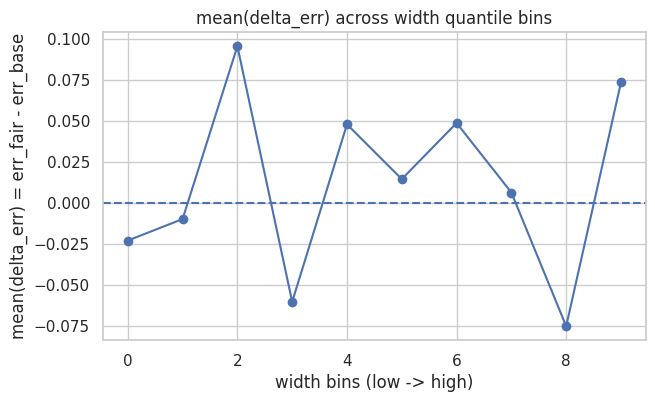

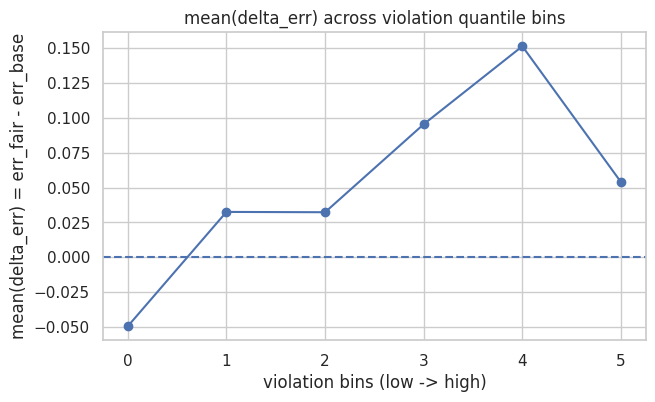

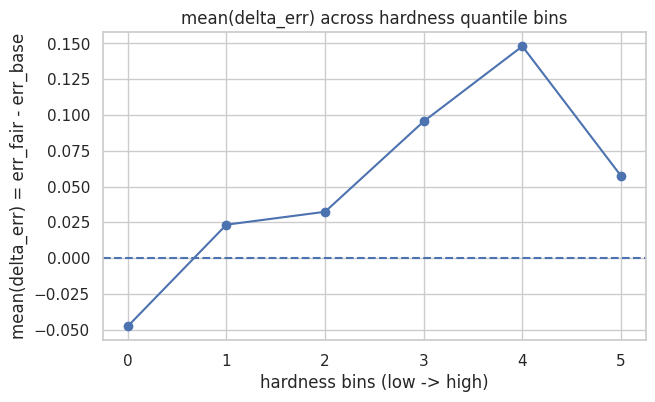

In [167]:
def monotonic_bins(df_join, x_col, bins=10):
    tmp = df_join[[x_col, "delta_err"]].dropna().copy()
    tmp["bin"] = pd.qcut(tmp[x_col], bins, duplicates="drop")
    g = tmp.groupby("bin")["delta_err"].agg(["mean","median","count"]).reset_index()
    return g

def plot_monotonic(df_join, x_col, bins=10):
    g = monotonic_bins(df_join, x_col, bins=bins)
    plt.figure(figsize=(7,4))
    plt.plot(range(len(g)), g["mean"].values, marker="o")
    plt.axhline(0, linestyle="--")
    plt.title(f"mean(delta_err) across {x_col} quantile bins")
    plt.xlabel(f"{x_col} bins (low -> high)")
    plt.ylabel("mean(delta_err) = err_fair - err_base")
    plt.show()
    return g

g_w = plot_monotonic(df_join, "width", bins=10)
g_v = plot_monotonic(df_join, "violation", bins=10)
g_h = plot_monotonic(df_join, "hardness", bins=10)

# 이 그림에서 고분위수로 갈수록 mean(Δerr)가 상승하면,
# “불확실성이 큰 노드에서 공정성 제약이 더 위험하다”를 정면으로 주장할 수 있습니다.

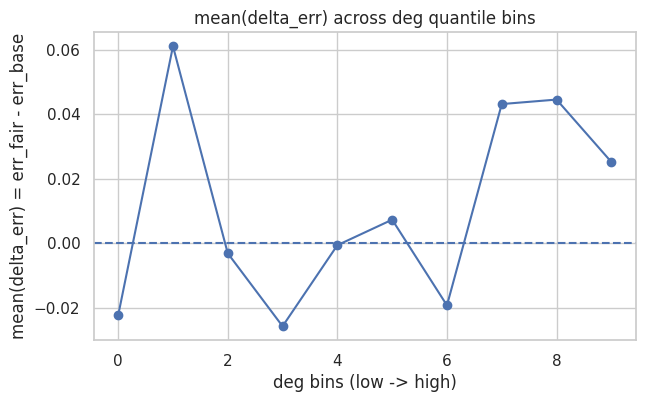

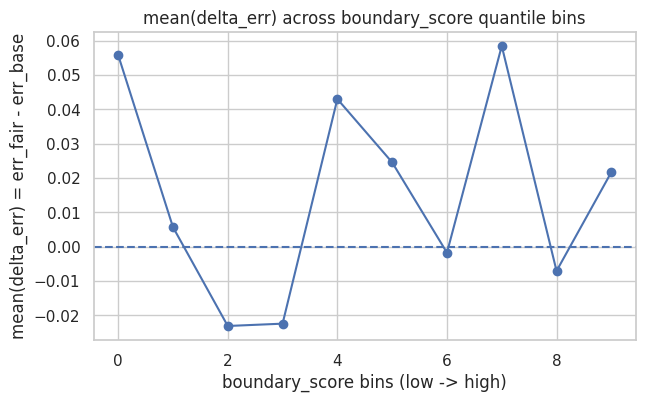

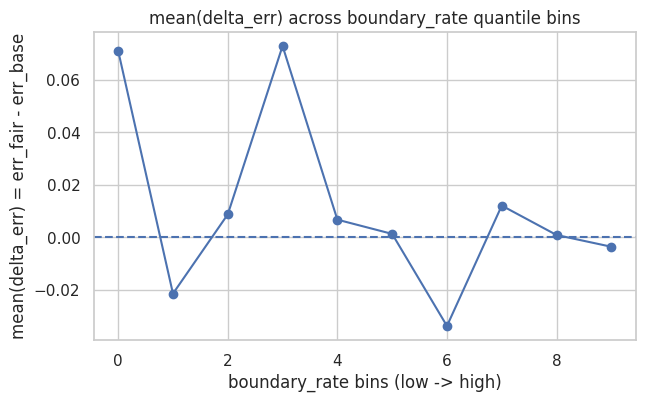

In [166]:
g_d = plot_monotonic(df_join, "deg", bins=10)
g_bs = plot_monotonic(df_join, "boundary_score", bins=10)
g_br = plot_monotonic(df_join, "boundary_rate", bins=10)

In [115]:
# “불확실성 ≠ boundary”를 보여야 함
# Δerr를 예측하는 feature importance에서 uncertainty > boundary
# 혹은 deg/boundary 통제한 뒤에도 uncertainty와 Δerr 관계가 남는다 (partial correlation / 회귀)

import statsmodels.api as sm

def controlled_regression(df_join):
    tmp = df_join[["delta_err","violation","hardness","deg","boundary_score"]].dropna().copy()
    X = tmp[["violation","hardness","deg","boundary_score"]]
    X = sm.add_constant(X)
    y = tmp["delta_err"]
    model = sm.OLS(y, X).fit()
    return model

reg = controlled_regression(df_join)
print(reg.summary())


                            OLS Regression Results                            
Dep. Variable:              delta_err   R-squared:                       0.122
Model:                            OLS   Adj. R-squared:                  0.085
Method:                 Least Squares   F-statistic:                     3.285
Date:                Thu, 05 Feb 2026   Prob (F-statistic):             0.0144
Time:                        09:27:27   Log-Likelihood:                 60.239
No. Observations:                 100   AIC:                            -110.5
Df Residuals:                      95   BIC:                            -97.45
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -0.0281      0.025     -1.

In [181]:
df_join

,node_id,y,pred_base,pred_fair,err_base,err_fair,delta_err,group,width,violation,hardness,deg,boundary_score,boundary_rate
0,200,-0.954448,0.081517,0.079829,1.035965,1.034277,-0.001688,1,0.976204,0.747312,0.765529,37.0,18.0,0.486486
1,259,-0.682039,-0.374398,-0.220353,0.307641,0.461685,0.154044,0,0.984677,0.358125,0.363698,15.0,5.0,0.333333
2,287,1.769650,0.780744,0.594998,0.988906,1.174652,0.185746,0,0.992144,0.971438,0.979129,169.0,16.0,0.094675
3,24,0.952421,0.671758,0.423812,0.280663,0.528608,0.247945,0,0.994985,0.160805,0.161615,102.0,15.0,0.147059
4,266,-1.771678,0.138440,0.111424,1.910118,1.883103,-0.027016,0,1.008523,1.520163,1.507316,102.0,12.0,0.117647
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,390,0.407601,0.314937,0.223977,0.092664,0.183623,0.090959,0,0.992489,0.000000,0.000000,89.0,15.0,0.168539
96,53,-0.137219,-0.230558,-0.130188,0.093339,0.007031,-0.086308,0,0.962100,0.049494,0.051444,55.0,8.0,0.145455
97,158,1.497240,0.405690,0.258266,1.091551,1.238974,0.147424,1,1.000130,0.692031,0.691941,55.0,31.0,0.563636
98,188,-0.682039,-0.293455,-0.165757,0.388584,0.516281,0.127697,0,1.038821,0.413948,0.398478,16.0,7.0,0.437500
